---
# Little Sis Network Project: Processing the Data Sets
## Jason LaRuez and Brendan Rooney

Previous use of this data: ``Power in the U.S. political economy: A network analysis``

---

The data set used was obtained from `LittleSis`, a watchdog organization that maintains a free database of relationships of influential U.S.-based organizations and persons. The data set is split into 2 subsets: (i) `Entities` and (ii) `Relationships`. Below the two data sets are read in and saved as `entities` and `relationships` (respectively) which are lists where each entry is a dictionary corresponding to a specific entity or relationship between entities.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Importing packages which will be used in this notebook
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
!pip install hypernetx
import hypernetx as hnx
import nltk
import random
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations
import pickle
import gc
from itertools import combinations
import time
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

import json
import gzip
from collections import Counter
import os

!pip install powerlaw

!pip install dionysus==2.0.10
import dionysus as d

# Files are gzipped json files
# Open and read entities.json.gz
with gzip.open('/content/drive/My Drive/Colab Notebooks/LittleSIS/entities.json.gz', 'rt', encoding='utf-8') as f:
    entities = json.load(f)

print("Entities loaded successfully")
print(f"Type: {type(entities)}")
print(f"Number of items: {len(entities) if isinstance(entities, (list, dict)) else 'N/A'}")

# Open and read relationships.json.gz
with gzip.open('/content/drive/My Drive/Colab Notebooks/LittleSIS/relationships.json.gz', 'rt', encoding='utf-8') as f:
    relationships = json.load(f)

print("\nRelationships loaded successfully")
print(f"Type: {type(relationships)}")
print(f"Number of items: {len(relationships) if isinstance(relationships, (list, dict)) else 'N/A'}")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 31.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dionysus: filename=dionysus-2.0.10-cp312-cp312-linux_x86_64.whl size=437482 sha256=134eda1fcc04c421c467ad35475e688bee62812acccf4092aa45065fc52ae3d2
  Stored in directory: /root/.cache/pip/wheels/11/9f/ca/ae26580795e766a8b6dce75ae4f29163b83b52d7a72efd5d48
Successfully built dionysus
Entities loaded successfully
Type: <class 'list'>
Number of items: 435442

Relationships loaded successfully
Type: <class 'list'>
Number of items: 1842042


---
## Dataset 1: Entities
---

The `entities` dataset contains 2 classes of entities: (i) `Organizations` and (ii) `Individuals`. Each entity entry contains 4 primary variables:
- `type`: Denotes whether the entry is an entity (`entities`) or a relationship (`relationships`).
- `id`: Denotes the unique integer identification number of the entity. Entities and relationships can have the same id value.
- `attributes`: Contains another dictionary containing all of the relevant attributes of the entity. This is where most of the relevant information about the entity is contained.
- `links`: Contains the url for the entity's corresponding entry in the LittleSis database at littlesis.org.

The `attributes` dictionary contains 13 attributes pertaining to the entity:
- `id`: Contains the same id as above.
- `name`: Denotes the name of the entity.
-  `blurb`: A few words describing the entity.
- `summary`: A few sentence description of the entity.
- `website`: Contains the url of a website representing or belonging to the entity
- `parent_id`: For organizations only this contains the `id` of the parent organization of the ORG.
- `primary_ext`: Denotes whether the entity is a person, `Person`, or an organization, `Org`.
- `updated_at`: Contains the data and time at which the entity data was last updated
- `start_date`:
- `end_date`:
- `aliases`: Contains other names which refer to the same entity
- `types`: Contains the categories of organization or person that the entity falls under
- `extensions`: This is another subdictionary containing entries of information for each corresponding `type` in the `types` attributes

The `extensions` dictionary contains various entries for each value of `type`:
- a
- a
- a
- a
- a
- a
- a
- a

---
## Preprocessing & Exploratory Analysis
---
Since all entries in the entities data set are trivially entities, the `type` attribute is redundant. Since the ID values is also embedded in the `attributes` attribute, the exterior `id` is redundant. Since we have no need for the littlesis url, the `links` attribute is also redundant. Finally, since `attributes` is the only non-redundant attribute in the exterior dictionaries, we replace the exterior dictionaries with the interior `attributes` dictionary.

In [ ]:
entities[1]

{'type': 'entities',
 'id': 2,
 'attributes': {'id': 2,
  'name': 'ExxonMobil',
  'blurb': 'Oil and gas exploration, production, and marketing',
  'summary': None,
  'website': 'http://www.exxonmobil.com',
  'parent_id': None,
  'primary_ext': 'Org',
  'updated_at': '2025-07-25T15:25:15Z',
  'start_date': '1882-00-00',
  'end_date': None,
  'aliases': ['Esso',
   'Exxon Corporation',
   'Exxon Mobil',
   'Exxon Mobil Corp',
   'Exxon Mobil Corporation',
   'ExxonMobil',
   'IRS EIN 13-5409005',
   'Standard Oil of New Jersey'],
  'types': ['Organization', 'Business', 'Public Company'],
  'extensions': {'Org': {'name': 'Exxon Mobil',
    'name_nick': 'EXXONMOBIL',
    'employees': None,
    'revenue': 372824000000,
    'fedspending_id': '112538',
    'lda_registrant_id': '14017'},
   'Business': {'annual_profit': None,
    'assets': None,
    'marketcap': None,
    'net_income': None,
    'aum': None},
   'PublicCompany': {'ticker': 'XOM', 'sec_cik': 34088}},
  'tags': ['fracking',
   '

In [ ]:
for i in range(len(entities)):
    entities[i] = entities[i]['attributes']

entities = {entity['id']: entity for entity in entities}


Missing value audit: Entities (n=435,442)
  attribute  n_present  n_missing pct_missing pct_present
  parent_id      3,694    431,748      99.15%       0.85%
   end_date     10,216    425,226      97.65%       2.35%
    website     21,661    413,781      95.03%       4.97%
 start_date     43,927    391,515      89.91%      10.09%
       tags     72,147    363,295      83.43%      16.57%
    summary     73,049    362,393      83.22%      16.78%
      blurb    224,174    211,268      48.52%      51.48%
    aliases    435,440          2       0.00%     100.00%
 extensions    435,441          1       0.00%     100.00%
      types    435,441          1       0.00%     100.00%
 updated_at    435,442          0       0.00%     100.00%
       name    435,442          0       0.00%     100.00%
primary_ext    435,442          0       0.00%     100.00%
         id    435,442          0       0.00%     100.00%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


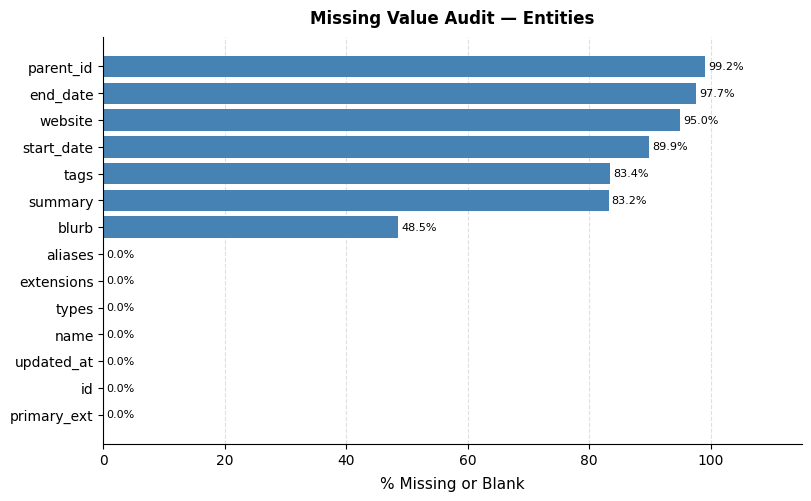

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def missing_value_audit(data_dict, dict_name, attr_key='attributes'):
    """
    For each attribute in a dictionary of entities or relationships,
    compute the proportion of entries where that attribute is missing
    (None, empty string, empty list, or empty dict).

    Parameters
    ----------
    data_dict : dict, keyed by id
    dict_name : str, name for display
    attr_key  : str, the key within each entry that holds the attributes dict.
                Pass None if the entries are already flat attribute dicts
                (e.g. after preprocessing).

    Returns
    -------
    results : pd.DataFrame, sorted by missing proportion descending
    """
    from collections import defaultdict

    counts_missing = defaultdict(int)
    counts_total   = defaultdict(int)
    all_keys       = set()

    for entry_id, entry in data_dict.items():
        # Get the attributes dict
        if attr_key is not None:
            attrs = entry.get(attr_key, {}) if isinstance(entry, dict) else {}
        else:
            attrs = entry if isinstance(entry, dict) else {}

        all_keys.update(attrs.keys())

    # Second pass: count missing per key
    for entry_id, entry in data_dict.items():
        if attr_key is not None:
            attrs = entry.get(attr_key, {}) if isinstance(entry, dict) else {}
        else:
            attrs = entry if isinstance(entry, dict) else {}

        for key in all_keys:
            counts_total[key] += 1
            val = attrs.get(key, None)
            if val is None:
                counts_missing[key] += 1
            elif isinstance(val, str) and val.strip() == '':
                counts_missing[key] += 1
            elif isinstance(val, (list, dict)) and len(val) == 0:
                counts_missing[key] += 1

    rows = []
    for key in all_keys:
        total   = counts_total[key]
        missing = counts_missing[key]
        rows.append({
            'attribute':        key,
            'total':            total,
            'n_missing':        missing,
            'n_present':        total - missing,
            'pct_missing':      100 * missing / total if total > 0 else np.nan,
            'pct_present':      100 * (total - missing) / total if total > 0 else np.nan,
        })

    df = pd.DataFrame(rows).sort_values('pct_missing', ascending=False)
    df = df.reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"Missing value audit: {dict_name} (n={len(data_dict):,})")
    print(f"{'='*60}")
    print(df[['attribute', 'n_present', 'n_missing',
              'pct_missing', 'pct_present']].to_string(
        index=False,
        formatters={
            'pct_missing': lambda x: f'{x:6.2f}%',
            'pct_present': lambda x: f'{x:6.2f}%',
            'n_missing':   lambda x: f'{int(x):>10,}',
            'n_present':   lambda x: f'{int(x):>10,}',
        }
    ))
    return df


def plot_missing_audit(df, title, save_path=None):
    """
    Plot missing value proportions as a horizontal bar chart,
    sorted from most to least missing.
    """
    df_plot = df.sort_values('pct_missing', ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, len(df_plot) * 0.35)),
                            constrained_layout=True)

    bars = ax.barh(df_plot['attribute'], df_plot['pct_missing'],
                   color='steelblue', edgecolor='none')

    # Annotate bars with percentage
    for bar, pct in zip(bars, df_plot['pct_missing']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%', va='center', ha='left', fontsize=8)

    ax.set_xlabel('% Missing or Blank', fontsize=11, labelpad=6)
    ax.set_xlim(0, 115)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# Run audits
# =============================================================================

# entities was preprocessed to entities[id] = attributes dict directly
# so attr_key=None since there is no nested 'attributes' key anymore
df_entities = missing_value_audit(
    entities, 'Entities', attr_key=None
)

# =============================================================================
# Plots
# =============================================================================

plot_missing_audit(
    df_entities,
    title='Missing Value Audit — Entities',
    save_path='missing_entities.pdf'
)

In [ ]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

for entity in entities:
    has_start = entities[entity]['start_date'] is not None
    has_end = entities[entity]['end_date'] is not None

    if has_start and (not has_end):
        start_only += 1
    elif (not has_start) and has_end:
        end_only += 1
    elif has_start and has_end:
        both_dates += 1
    else:
        no_dates += 1

print(f"Entities with a start date but no end date: {start_only}")
print(f"Entities with an end date but no start date: {end_only}")
print(f"Entities with both a start date and an end date: {both_dates}")
print(f"Entities with no start date or end date: {no_dates}")

Entities with a start date but no end date: 36086
Entities with an end date but no start date: 2375
Entities with both a start date and an end date: 7841
Entities with no start date or end date: 389140


Now we want to get an idea of how many organizations and how many individuals are in the dataset. Then we will breakup the `entities` dataset into `Organizations` and `Individuals` datasets. We also want to get an idea of the distributions of appropriate initial labels for organizations and individuals.

In [ ]:
# Determine unique classes of orgs and individuals, and split dataset into
# Organizations and Individuals datasets.
organization_count = 0
individual_count = 0
Organizations = {}
Org_types = []
Individuals = {}
Ind_types = []
names_to_id = {}
for entity in entities:
    if entities[entity]['primary_ext'] == 'Org':
        organization_count += 1
        Organizations[entity] = entities[entity]
        for x in entities[entity]['types']:
            if x not in Org_types:
                Org_types.append(x)
    else:
        individual_count += 1
        Individuals[entity] = entities[entity]
        for x in entities[entity]['types']:
            if x not in Ind_types:
                Ind_types.append(x)
    names_to_id[entities[entity]['name']] = entity

print("There are",organization_count,'organizations and',individual_count,'individuals comprising the full dataset of',len(entities),'entities.')

Ind_types.remove('Person')
Org_types.remove('Organization')

# Counts the occurrences of org classes which are not simply 'Organization'
counts_org = np.zeros(len(Org_types))
for entity in Organizations:
    for x in Organizations[entity]['types']:
        if x != 'Organization':
            counts_org[np.where(np.array(Org_types) == x)[0][0]] += 1

There are 134441 organizations and 301001 individuals comprising the full dataset of 435442 entities.


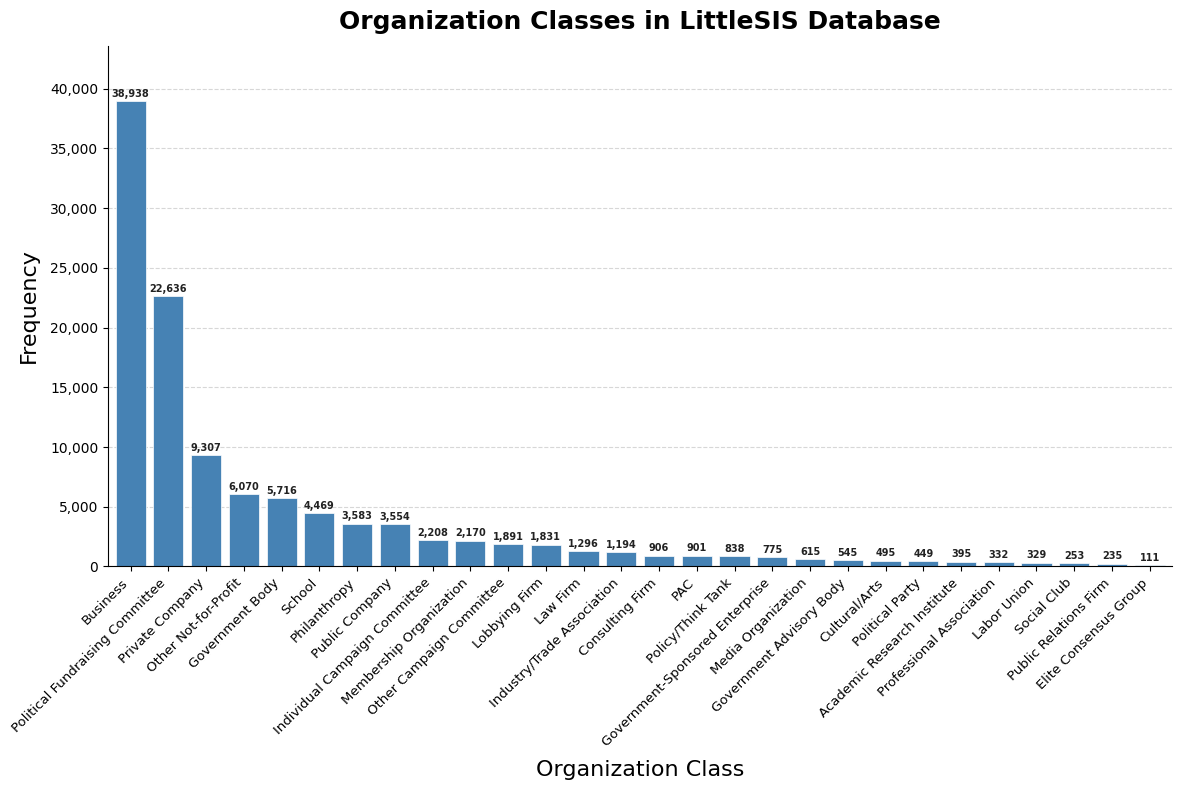

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Sort org types by descending frequency
sort_idx = np.argsort(counts_org)[::-1]
sorted_counts = counts_org[sort_idx][:28]
sorted_labels = [Org_types[i] for i in sort_idx][:28]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(
    range(len(sorted_counts)),
    sorted_counts,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

# Frequency labels above bars
for bar, count in zip(bars, sorted_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sorted_counts.max() * 0.005,
        f'{int(count):,}',
        ha='center', va='bottom',
        fontsize=7, fontweight='bold', color='#222222'
    )

ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9.5)
ax.set_xlabel('Organization Class', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title("Organization Classes in LittleSIS Database", fontsize=18, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=10)

ax.set_xlim(-0.6, len(sorted_counts) - 0.4)
ax.set_ylim(0, sorted_counts.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('org_class_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

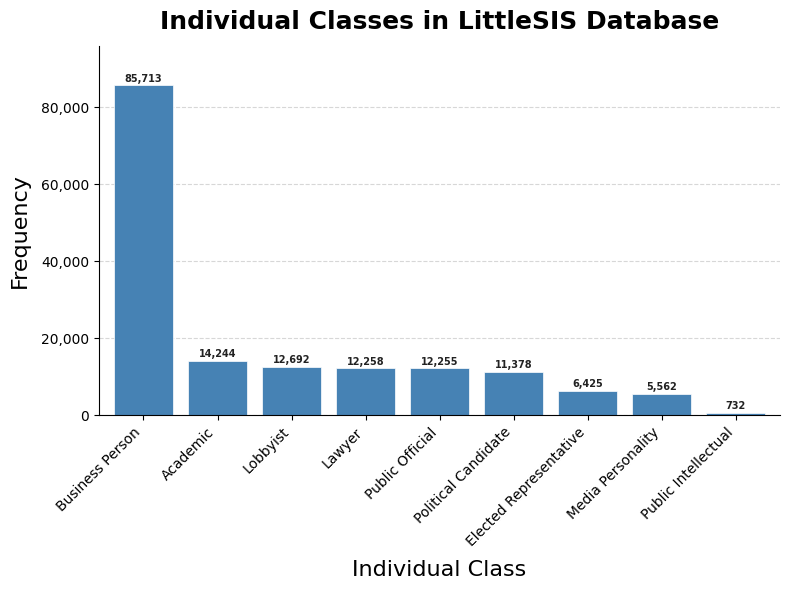

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Counts the occurrences of individuals classes which are not simply 'Person'
counts_ind = np.zeros(len(Ind_types))
for entity in Individuals:
    for x in Individuals[entity]['types']:
        if x != 'Person':
            counts_ind[np.where(np.array(Ind_types) == x)[0][0]] += 1

sort_idx_ind = np.argsort(counts_ind)[::-1]
sorted_counts_ind = counts_ind[sort_idx_ind][:9]
sorted_labels_ind = [Ind_types[i] for i in sort_idx_ind][:9]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    range(len(sorted_counts_ind)),
    sorted_counts_ind,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

for bar, count in zip(bars, sorted_counts_ind):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sorted_counts_ind.max() * 0.005,
        f'{int(count):,}',
        ha='center', va='bottom',
        fontsize=7, fontweight='bold', color='#222222'
    )

ax.set_xticks(range(len(sorted_labels_ind)))
ax.set_xticklabels(sorted_labels_ind, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Individual Class', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title("Individual Classes in LittleSIS Database", fontsize=18, fontweight='bold', pad=12)

ax.set_xlim(-0.6, len(sorted_counts_ind) - 0.4)
ax.set_ylim(0, sorted_counts_ind.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ind_class_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# List of types to filter by
filter_types = ['Political Candidate','Public Intellectual','Public Official','Lawyer','Academic','Business Person','Media Personality','Elected Representative','Lobbyist']

# Filter the Organizations list
filtered_organizations = [
    Organizations[organization] for organization in Organizations
    if any(item in Organizations[organization].get('types', []) for item in filter_types)
]

# Display the number of filtered orgs and the filtered orgs for manual review
print(f"Number of organizations with specified types: {len(filtered_organizations)}")
if filtered_organizations:
    print("Filtered organizations:")
    display(filtered_organizations)
else:
    print("No organizations found with the specified types.")

Number of organizations with specified types: 41
Filtered organizations:


[{'id': 213407,
  'name': 'TMK',
  'blurb': 'TMK is a political group of China',
  'summary': None,
  'website': None,
  'parent_id': None,
  'primary_ext': 'Org',
  'updated_at': '2015-10-23T09:37:21Z',
  'start_date': None,
  'end_date': None,
  'aliases': ['TMK'],
  'types': ['Organization',
   'Political Candidate',
   'Business',
   'Government Body'],
  'extensions': {'Org': {'name': 'TMK',
    'name_nick': None,
    'employees': None,
    'revenue': None,
    'fedspending_id': None,
    'lda_registrant_id': None},
   'PoliticalCandidate': {'is_federal': None,
    'is_state': None,
    'is_local': None,
    'pres_fec_id': None,
    'senate_fec_id': None,
    'house_fec_id': None,
    'crp_id': None},
   'Business': {'annual_profit': None,
    'assets': None,
    'marketcap': None,
    'net_income': None,
    'aum': None},
   'GovernmentBody': {'is_federal': None,
    'state_id': None,
    'city': None,
    'county': None}},
  'tags': []},
 {'id': 222159,
  'name': 'SethRollins',


In [ ]:
# List of types to filter by
filter_types = ['Private Company', 'Business', 'Law Firm', 'Government Body', 'Lobbying Firm', 'Policy/Think Tank', 'School', 'Political Party', 'Other Not-for-Profit', 'Media Organization']

# Filter the Individuals list
filtered_individuals = [
    Individuals[individual] for individual in Individuals
    if any(item in Individuals[individual].get('types', []) for item in filter_types)
]

# Display the number of filtered individuals and the entries
print(f"Number of individuals with specified types: {len(filtered_individuals)}")
if filtered_individuals:
    print("Filtered individuals:")
    display(filtered_individuals)
else:
    print("No individuals found with the specified types.")

Number of individuals with specified types: 49
Filtered individuals:


[{'id': 224095,
  'name': 'Lori Whelan',
  'blurb': 'Co-founder of Silversmith Capital Partners; formerly with Bain & Co.',
  'summary': None,
  'website': None,
  'parent_id': None,
  'primary_ext': 'Person',
  'updated_at': '2016-03-23T17:57:13Z',
  'start_date': None,
  'end_date': None,
  'aliases': ['Lori Whelan'],
  'types': ['Person', 'Private Company', 'Business Person'],
  'extensions': {'Person': {'name_last': 'Whelan',
    'name_first': 'Lori',
    'name_middle': None,
    'name_prefix': None,
    'name_suffix': None,
    'name_nick': None,
    'birthplace': None,
    'gender_id': None,
    'party_id': None,
    'is_independent': None,
    'net_worth': None,
    'name_maiden': None,
    'nationality': []},
   'BusinessPerson': {'sec_cik': None}},
  'tags': []},
 {'id': 225870,
  'name': 'Henry McClure',
  'blurb': None,
  'summary': None,
  'website': None,
  'parent_id': None,
  'primary_ext': 'Person',
  'updated_at': '2016-04-28T01:34:48Z',
  'start_date': None,
  'end_da

In [ ]:
# Move individuals incorrectly labelled as organizations to individuals
Individuals[227043] = Organizations[227043]
del(Organizations[227043])
Individuals[423772] = Organizations[423772]
del(Organizations[423772])
# Move organizations incorrectly labelled as individuals to organizations
Organizations[258205] = Individuals[258205]
del(Individuals[258205])
Organizations[333433] = Individuals[333433]
del(Individuals[333433])

---
## Dataset 2: Relationships
---
The `relationships` dataset contains 12 classes of relationships:
1) `Position` (P+O and P+P): When a person has a place in an organizational hierarchy, usually carrying a title. Positions can be paid or unpaid. Examples - CEO, Director, Trustee, Chief Counsel, Professor, etc. <br>
2) `Education` (P+O): When a person attends a school or educational program as a student. <br>
3) `Membership`: When a person is a member of a membership organization, but doesn’t hold a position, or when an organization is a member of a larger coalition or association. Examples - AFL-CIO, NRA, National Association of Manufacturers, etc. <br>
4) `Family` (P+P): When two people are part of the same family. Examples - children, spouses, cousins, siblings, etc. <br>
5) `Donation/Grant`: A gift transfer of money, goods, or services with nothing due in return. Examples - political funding, contributions to charities, government grants, prizes. <br>
6) `Service/Transaction`: An exchange of money, goods, or services of about equal value. Examples - purchases, consulting, contract work, accounting, trades, etc. <br>
7) `Lobbying`: When an organization directly lobbies a government agency or official. Examples - organization that employs lobbyists in-house, lobbying firm hired by an organization. <br>
8) `Social` (P+P): When two people are socially acquainted. Examples - friends, rivals, lovers, tennis partners, etc. <br>
9) `Professional` (P+P): When two people have a direct working or business relationship. Examples - co-writers, business partners, mentors, etc. <br>
10) `Ownership` (O+O and P+O): When a person or organization has full or partial ownership of an organization. Examples - sole proprietor, limited partners, shareholders, etc. <br>
11) `Hierarchy` (O+O): When an organization is the parent or child of another organization. Examples - foundation, lobbying arm, political arm, etc. <br>
12) `Generic`: A generic type for affiliations that do not fit into any of the regular types of relationships.

Each relationship entry contains 6 attributes:
- `type`: Denotes whether the entry is an entity (`entities`) or a relationship (`relationships`).
- `id`: Denotes the unique integer identification number of the entity. Entities and relationships can have the same id value.
- `attributes`: Contains another dictionary containing all of the relevant attributes of the entity. This is where most of the relevant information about the entity is contained.
- `self`: URL for littlesis webpage about the relationship.
- `entity`: URL for littlesis webpage about entity_1 in the relationship.
- `related`: URL for littlesis webpage about entity_2 in the relationship.

The attributes dictionary contains 17 attributes:
- `id`:
- `entity1_id`:
- `entity2_id`:
- `category_id`:
- `description1`:
- `description2`:
- `amount`:
- `currency`:
- `good`:
- `filings`:
- `updated_at`:
- `start_date`:
- `end_date`:
- `is_current`:
- `is_featured`:
- `description`:
- `category_attributes`:

---
## Preprocessing & Exploratory Analysis
---
Since all entries in the relationships data set are trivially relationships, the `type` attribute is redundant. Since the ID values is also embedded in the `attributes` attribute, the exterior `id` is redundant. Since we have no need for the littlesis url, the `self`, `entity`, and `related` attributes are also redundant. Finally, since `attributes` is the only non-redundant attribute in the exterior dictionaries, we replace the exterior dictionaries with the interior `attributes` dictionary.

In [ ]:
for i in range(len(relationships)):
    relationships[i] = relationships[i]['attributes']

person_to_person = {relation['id']: relation for relation in relationships if ( (relation['entity1_id'] in Individuals) and (relation['entity2_id'] in Individuals) )}
person_to_org = {relation['id']: relation for relation in relationships if ((relation['entity1_id'] in Individuals and relation['entity2_id'] in Organizations) or (relation['entity1_id'] in Organizations and relation['entity2_id'] in Individuals))}
org_to_org = {relation['id']: relation for relation in relationships if (relation['entity1_id'] in Organizations and relation['entity2_id'] in Organizations)}

total_classified = len(person_to_person) + len(person_to_org) + len(org_to_org)
print(f"P-P: {len(person_to_person)}, P-O: {len(person_to_org)}, O-O: {len(org_to_org)}")
print(f"Classified: {total_classified} / {len(relationships)} ({100*total_classified/len(relationships):.2f}%)")

P-P: 870257, P-O: 847119, O-O: 124663
Classified: 1842039 / 1842042 (100.00%)



Missing value audit: Relationships (n=1,842,042)
          attribute  n_present  n_missing pct_missing pct_present
              goods      7,974  1,834,068      99.57%       0.43%
         is_current    659,508  1,182,534      64.20%      35.80%
            filings  1,202,965    639,077      34.69%      65.31%
           currency  1,232,537    609,505      33.09%      66.91%
             amount  1,232,537    609,505      33.09%      66.91%
           end_date  1,315,794    526,248      28.57%      71.43%
       description2  1,327,851    514,191      27.91%      72.09%
         start_date  1,390,680    451,362      24.50%      75.50%
       description1  1,695,598    146,444       7.95%      92.05%
category_attributes  1,783,822     58,220       3.16%      96.84%
        is_featured  1,842,042          0       0.00%     100.00%
        category_id  1,842,042          0       0.00%     100.00%
         updated_at  1,842,042          0       0.00%     100.00%
        description  1,842

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


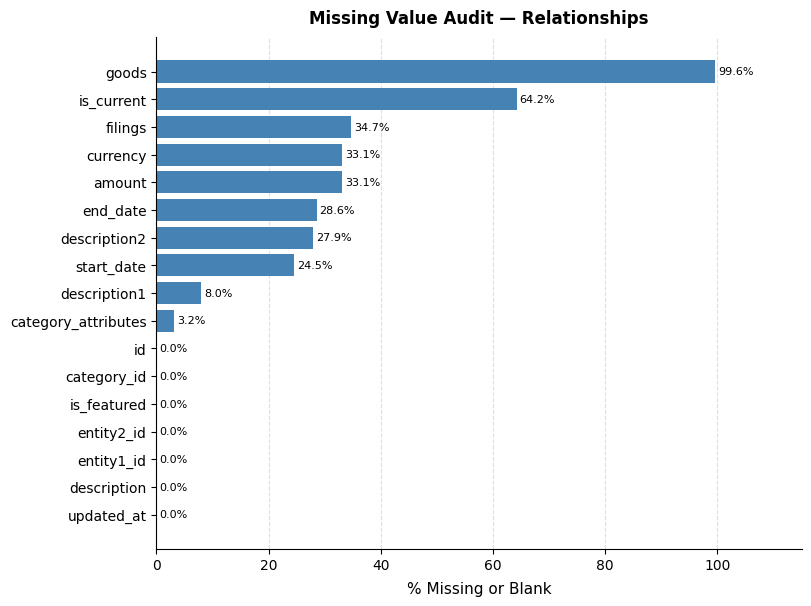

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# relationships was likewise preprocessed to relationships[i] = attributes dict
# but relationships is a list after preprocessing, so convert first
relationships_dict = {i: r for i, r in enumerate(relationships)} \
    if isinstance(relationships, list) \
    else relationships

df_relationships = missing_value_audit(
    relationships_dict, 'Relationships', attr_key=None
)

plot_missing_audit(
    df_relationships,
    title='Missing Value Audit — Relationships',
    save_path='missing_relationships.pdf'
)

Now we will split these three dictionaries (P-P, P-O, O-O) into dictionaries where each relationship has 1. only a start date, 2. a start AND end date, 3. only an end date.

In [ ]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

has_start_p2p = {}; has_start_end_p2p = {}; has_end_p2p = {}
# Iterate over all person-person relationships to count and
# store relations with a start_date, and start_date + end_date
for relation in person_to_person.copy():
    # Check if relation has valid start_date
    has_start = person_to_person[relation]['start_date'] is not None
    if person_to_person[relation]['start_date'] == '':
      has_start = False

    # If relation has valid start_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_start:
      date = person_to_person[relation]['start_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_person[relation]['start_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_person[relation]['start_date'] = date

    # Check if relation has valid end_date
    has_end = person_to_person[relation]['end_date'] is not None
    if person_to_person[relation]['end_date'] == '':
      has_end = False

    # If relation has valid end_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_end:
      date = person_to_person[relation]['end_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_person[relation]['end_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_person[relation]['end_date'] = date

    # Relation ONLY has start_date
    if has_start and not has_end:
        start_year = int(person_to_person[relation]['start_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025:
          if person_to_person[relation]['is_current']:
            has_start_end_p2p[relation] = person_to_person[relation]
            both_dates += 1
          else:
            has_start_p2p[relation] = person_to_person[relation]
            start_only += 1
    # Relation ONLY has end_date
    elif not has_start and has_end:
        end_year = int(person_to_person[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if end_year >= 1950 and end_year <= 2025:
          has_end_p2p[relation] = person_to_person[relation]
          end_only += 1
    # Relation has BOTH start_date and end_date
    elif has_start and has_end:
        start_year = int(person_to_person[relation]['start_date'][:4])
        end_year = int(person_to_person[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025 and end_year <= 2025 and start_year <= end_year:
          if person_to_person[relation]['start_date'] == person_to_person[relation]['end_date']:
            person_to_person[relation]['end_date'] = None
            has_start_p2p[relation] = person_to_person[relation]
            start_only += 1
            continue
          #has_start_p2o[relation] = person_to_org[relation]
          has_start_end_p2p[relation] = person_to_person[relation]
          both_dates += 1
    else:
        no_dates += 1

print(f"P-P relationships with a start date but no end date: {start_only}")
print(f"P-P relationships with an end date but no start date: {end_only}")
print(f"P-P relationships with both a start date and an end date: {both_dates}")
print(f"P-P relationships with no start or end date: {no_dates}")

P-P relationships with a start date but no end date: 558876
P-P relationships with an end date but no start date: 1307
P-P relationships with both a start date and an end date: 265973
P-P relationships with no start or end date: 38977


In [ ]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

has_start_p2o = {}; has_start_end_p2o = {}; has_end_p2o = {}
# Iterate over all person-org relationships to count and
# store relations with a start_date, and start_date + end_date
for relation in person_to_org.copy():
    # Check if relation has valid start_date
    has_start = person_to_org[relation]['start_date'] is not None
    if person_to_org[relation]['start_date'] == '':
      has_start = False

    # If relation has valid start_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_start:
      date = person_to_org[relation]['start_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_org[relation]['start_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_org[relation]['start_date'] = date

    # Check if relation has valid end_date
    has_end = person_to_org[relation]['end_date'] is not None
    if person_to_org[relation]['end_date'] == '':
      has_end = False

    # If relation has valid end_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_end:
      date = person_to_org[relation]['end_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_org[relation]['end_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_org[relation]['end_date'] = date

    # Relation ONLY has start_date
    if has_start and not has_end:
        start_year = int(person_to_org[relation]['start_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025:
          if person_to_org[relation]['is_current']:
            has_start_end_p2o[relation] = person_to_org[relation]
            both_dates += 1
          else:
            has_start_p2o[relation] = person_to_org[relation]
            start_only += 1
    # Relation ONLY has end_date
    elif not has_start and has_end:
        end_year = int(person_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if end_year >= 1950 and end_year <= 2025:
          has_end_p2o[relation] = person_to_org[relation]
          end_only += 1
    # Relation has BOTH start_date and end_date
    elif has_start and has_end:
        start_year = int(person_to_org[relation]['start_date'][:4])
        end_year = int(person_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025 and end_year <= 2025 and start_year <= end_year:
          if person_to_org[relation]['start_date'] == person_to_org[relation]['end_date']:
            person_to_org[relation]['end_date'] = None
            has_start_p2o[relation] = person_to_org[relation]
            start_only += 1
            continue
          #has_start_p2o[relation] = person_to_org[relation]
          has_start_end_p2o[relation] = person_to_org[relation]
          both_dates += 1
    else:
        no_dates += 1

print(f"P-O relationships with a start date but no end date: {start_only}")
print(f"P-O relationships with an end date but no start date: {end_only}")
print(f"P-O relationships with both a start date and an end date: {both_dates}")
print(f"P-O relationships with no start or end date: {no_dates}")

P-O relationships with a start date but no end date: 287410
P-O relationships with an end date but no start date: 38659
P-O relationships with both a start date and an end date: 221825
P-O relationships with no start or end date: 294244


In [ ]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

has_start_o2o = {}; has_start_end_o2o = {}; has_end_o2o = {}
# Iterate over all org-org relationships to count and
# store relations with a start_date, and start_date + end_date
for relation in org_to_org.copy():
    # Check if relation has valid start_date
    has_start = org_to_org[relation]['start_date'] is not None
    if org_to_org[relation]['start_date'] == '':
      has_start = False

    # If relation has valid start_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_start:
      date = org_to_org[relation]['start_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        org_to_org[relation]['start_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        org_to_org[relation]['start_date'] = date

    # Check if relation has valid end_date
    has_end = org_to_org[relation]['end_date'] is not None
    if org_to_org[relation]['end_date'] == '':
      has_end = False

    # If relation has valid end_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_end:
      date = org_to_org[relation]['end_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        org_to_org[relation]['end_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        org_to_org[relation]['end_date'] = date

    # Relation ONLY has start_date
    if has_start and not has_end:
        start_year = int(org_to_org[relation]['start_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025:
          if org_to_org[relation]['is_current']:
            has_start_end_o2o[relation] = org_to_org[relation]
            both_dates += 1
          else:
            has_start_o2o[relation] = org_to_org[relation]
            start_only += 1
    # Relation ONLY has end_date
    elif not has_start and has_end:
        end_year = int(org_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if end_year >= 1950 and end_year <= 2025:
          has_end_o2o[relation] = org_to_org[relation]
          end_only += 1
    # Relation has BOTH start_date and end_date
    elif has_start and has_end:
        start_year = int(org_to_org[relation]['start_date'][:4])
        end_year = int(org_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025 and end_year <= 2025 and start_year <= end_year:
          if org_to_org[relation]['start_date'] == org_to_org[relation]['end_date']:
            org_to_org[relation]['end_date'] = None
            has_start_o2o[relation] = org_to_org[relation]
            start_only += 1
            continue
          has_start_end_o2o[relation] = org_to_org[relation]
          both_dates += 1
    else:
        no_dates += 1

print(f"O-O relationships with a start date but no end date: {start_only}")
print(f"O-O relationships with an end date but no start date: {end_only}")
print(f"O-O relationships with both a start date and an end date: {both_dates}")
print(f"O-O relationships with no start or end date: {no_dates}")

O-O relationships with a start date but no end date: 24361
O-O relationships with an end date but no start date: 1272
O-O relationships with both a start date and an end date: 23004
O-O relationships with no start or end date: 75507


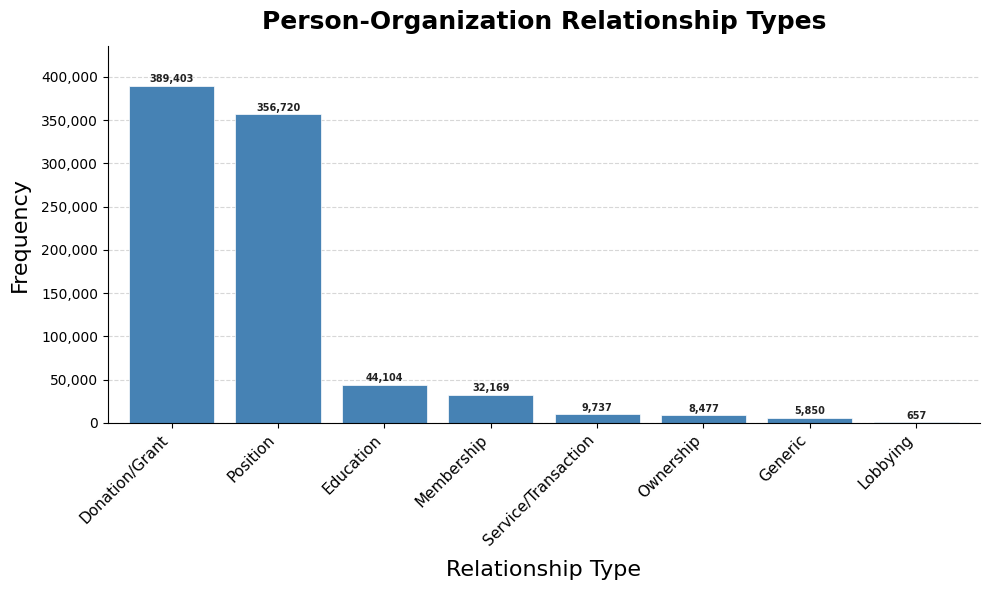

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


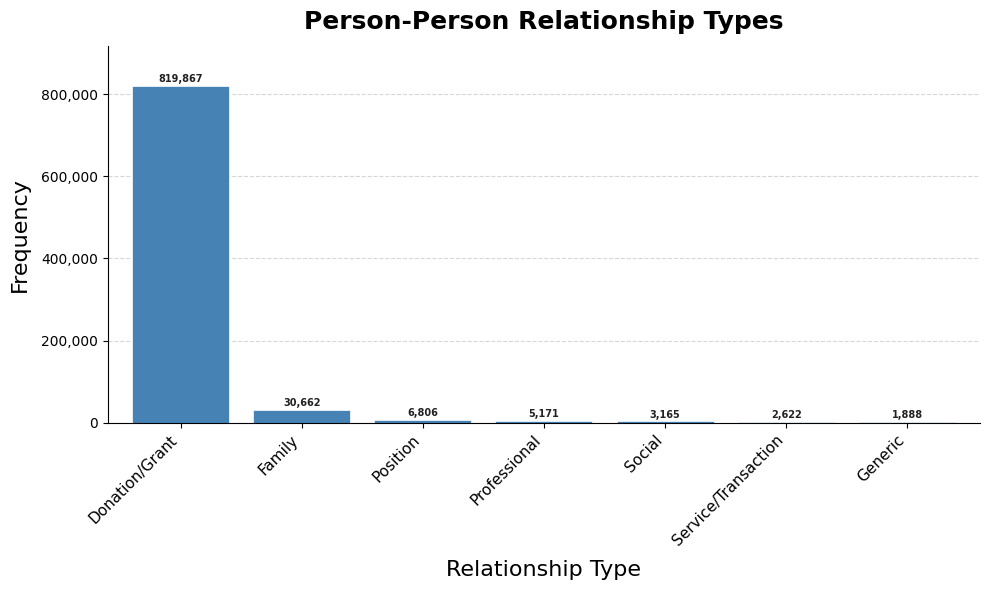

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


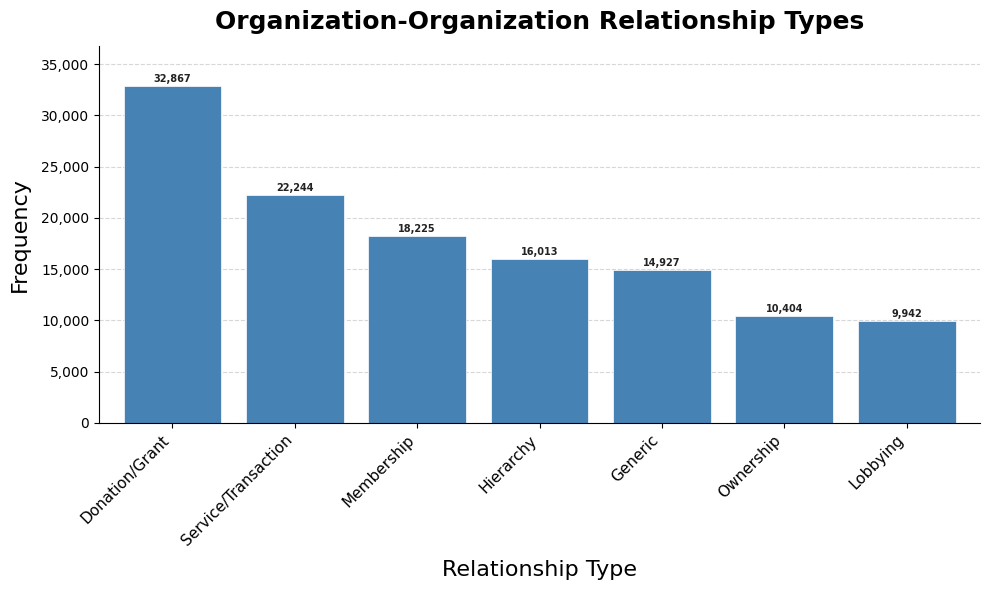

In [ ]:
# --- P-O Relationship Type Frequency ---
Rel_types_all = ['Position','Education','Membership','Family','Donation/Grant',
                 'Service/Transaction','Lobbying','Social','Professional',
                 'Ownership','Hierarchy','Generic']

counts_rel_p2o = np.zeros(12)
for relation in person_to_org:
    counts_rel_p2o[person_to_org[relation]['category_id']-1] += 1

# Exclude Family(3), Social(7), Professional(8), Hierarchy(10) — invalid for P-O
keep_idx_p2o = [i for i in range(12) if i not in [3,7,8,10]]
counts_rel_p2o_filtered = counts_rel_p2o[keep_idx_p2o]
labels_p2o = [Rel_types_all[i] for i in keep_idx_p2o]

sort_idx_p2o = np.argsort(counts_rel_p2o_filtered)[::-1]
sorted_counts_p2o = counts_rel_p2o_filtered[sort_idx_p2o]
sorted_labels_p2o = [labels_p2o[i] for i in sort_idx_p2o]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(sorted_counts_p2o)), sorted_counts_p2o,
              color='steelblue', edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, sorted_counts_p2o):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sorted_counts_p2o.max()*0.005,
            f'{int(count):,}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#222222')
ax.set_xticks(range(len(sorted_labels_p2o)))
ax.set_xticklabels(sorted_labels_p2o, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Relationship Type', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Person-Organization Relationship Types',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.6, len(sorted_counts_p2o) - 0.4)
ax.set_ylim(0, sorted_counts_p2o.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('p2o_rel_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --- P-P Relationship Type Frequency ---
counts_rel_p2p = np.zeros(12)
for relation in person_to_person:
    counts_rel_p2p[person_to_person[relation]['category_id']-1] += 1

sort_idx_p2p = np.argsort(counts_rel_p2p)[::-1]
sorted_counts_p2p = counts_rel_p2p[sort_idx_p2p][:7]
sorted_labels_p2p = [Rel_types_all[i] for i in sort_idx_p2p][:7]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(sorted_counts_p2p)), sorted_counts_p2p,
              color='steelblue', edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, sorted_counts_p2p):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sorted_counts_p2p.max()*0.005,
            f'{int(count):,}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#222222')
ax.set_xticks(range(len(sorted_labels_p2p)))
ax.set_xticklabels(sorted_labels_p2p, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Relationship Type', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Person-Person Relationship Types',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.6, len(sorted_counts_p2p) - 0.4)
ax.set_ylim(0, sorted_counts_p2p.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('p2p_rel_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --- O-O Relationship Type Frequency ---
counts_rel_o2o = np.zeros(12)
for relation in org_to_org:
    counts_rel_o2o[org_to_org[relation]['category_id']-1] += 1

sort_idx_o2o = np.argsort(counts_rel_o2o)[::-1]
sorted_counts_o2o = counts_rel_o2o[sort_idx_o2o][:7]
sorted_labels_o2o = [Rel_types_all[i] for i in sort_idx_o2o][:7]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(sorted_counts_o2o)), sorted_counts_o2o,
              color='steelblue', edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, sorted_counts_o2o):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sorted_counts_o2o.max()*0.005,
            f'{int(count):,}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#222222')
ax.set_xticks(range(len(sorted_labels_o2o)))
ax.set_xticklabels(sorted_labels_o2o, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Relationship Type', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Organization-Organization Relationship Types',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.6, len(sorted_counts_o2o) - 0.4)
ax.set_ylim(0, sorted_counts_o2o.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('o2o_rel_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

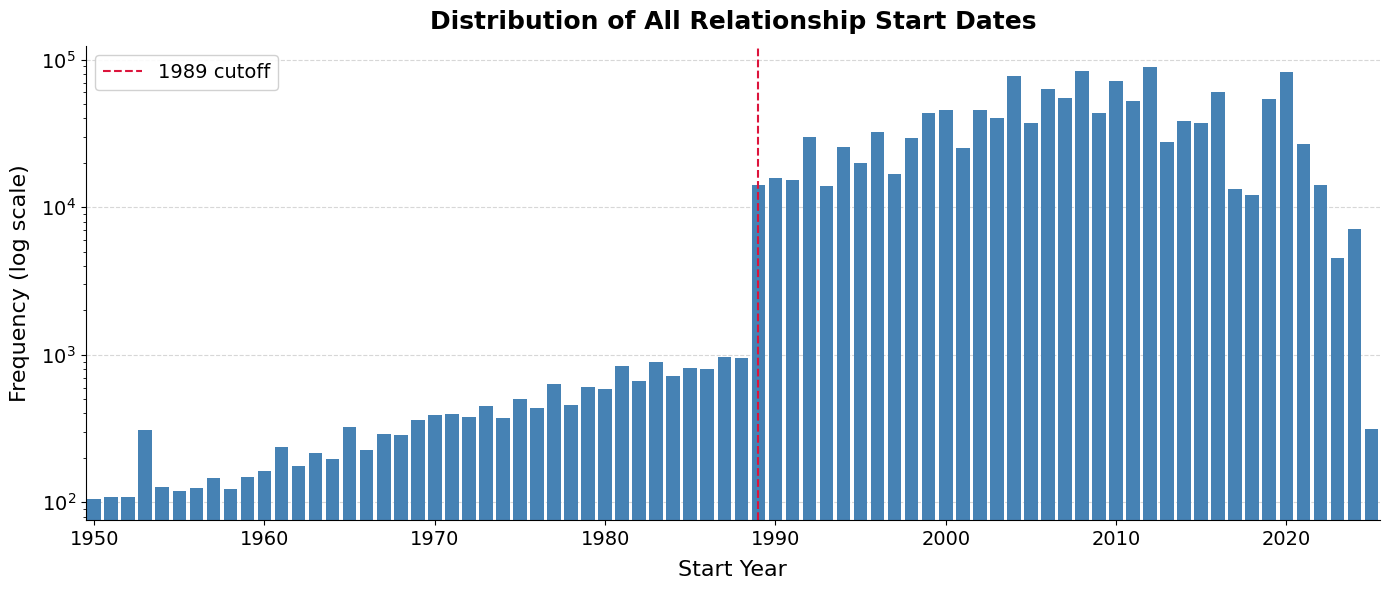

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


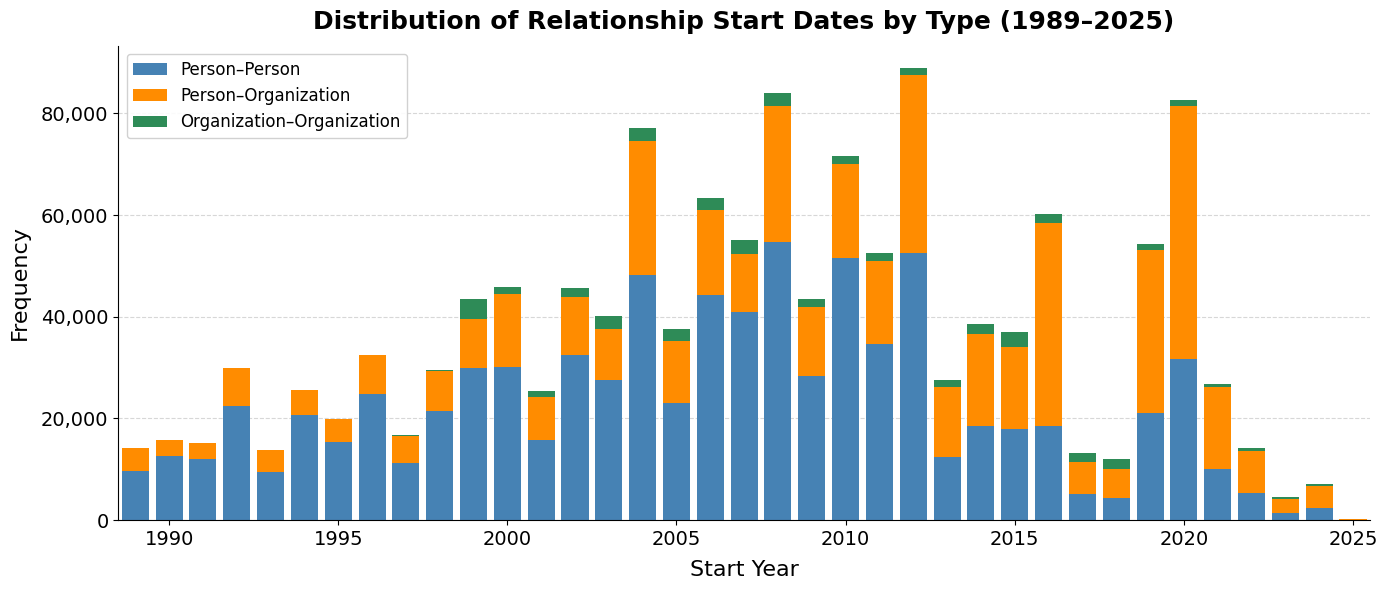

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- Combined histogram (all types merged) to motivate the 1989 cutoff ---
# Count per year for each type
def year_counts(years, bins):
    c = Counter(years)
    return np.array([c.get(y, 0) for y in bins[:-1]])

def extract_start_years(rel_dict):
    return [int(rel_dict[r]['start_date'][:4]) for r in rel_dict]

years_all = (extract_start_years(has_start_p2p) + extract_start_years(has_start_end_p2p) +
             extract_start_years(has_start_p2o) + extract_start_years(has_start_end_p2o) +
             extract_start_years(has_start_o2o) + extract_start_years(has_start_end_o2o))

year_min, year_max = min(years_all), max(years_all)
bins = range(year_min, year_max + 2)
bin_years = np.array(list(bins[:-1]))
counts_all = year_counts(years_all, bins)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years, counts_all, width=0.8, color='steelblue', edgecolor='none')
ax.axvline(x=1989, color='crimson', linestyle='--', linewidth=1.5, label='1989 cutoff')
ax.set_yscale('log')
ax.set_xlabel('Start Year', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency (log scale)', fontsize=16, labelpad=8)
ax.set_title('Distribution of All Relationship Start Dates',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(year_min - 0.5, year_max + 0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.savefig('start_date_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --- Remove entries with start dates prior to 1989 ---
for z in [has_start_p2p, has_start_end_p2p,
          has_start_p2o, has_start_end_p2o,
          has_start_o2o, has_start_end_o2o]:
    to_delete = [r for r in z if int(z[r]['start_date'][:4]) < 1989]
    for r in to_delete:
        del z[r]


# --- Stacked bar histogram (1989 onward, linear scale) ---
years_p2p = extract_start_years(has_start_p2p) + extract_start_years(has_start_end_p2p)
years_p2o = extract_start_years(has_start_p2o) + extract_start_years(has_start_end_p2o)
years_o2o = extract_start_years(has_start_o2o) + extract_start_years(has_start_end_o2o)

all_years = years_p2p + years_p2o + years_o2o
year_min, year_max = min(all_years), max(all_years)
bins = range(year_min, year_max + 2)
bin_years = np.array(list(bins[:-1]))

counts_p2p = year_counts(years_p2p, bins)
counts_p2o = year_counts(years_p2o, bins)
counts_o2o = year_counts(years_o2o, bins)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years, counts_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_years, counts_p2o, width=0.8,
       bottom=counts_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_years, counts_o2o, width=0.8,
       bottom=counts_p2p + counts_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')

ax.set_xlabel('Start Year', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Distribution of Relationship Start Dates by Type (1989–2025)',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(year_min - 0.5, year_max + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='#cccccc')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.savefig('start_date_stacked_1989.pdf', dpi=300, bbox_inches='tight')
plt.show()

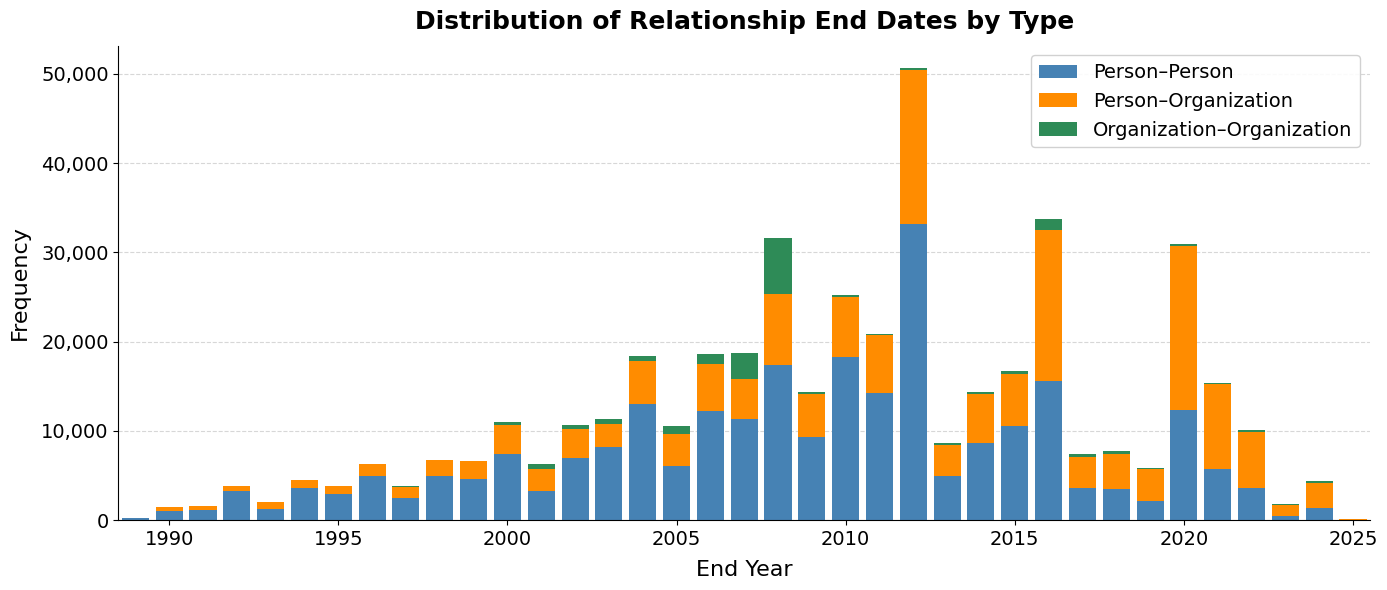

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


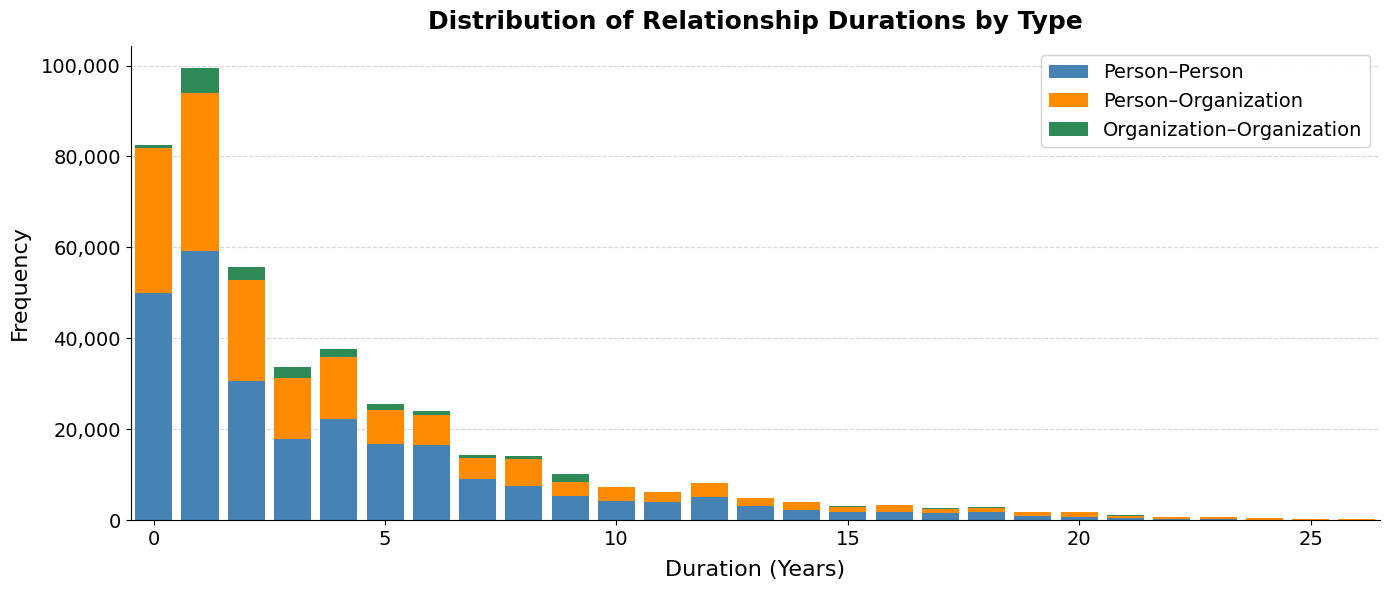

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =============================================================================
# 1. End Date Distribution (Stacked Histogram)
# =============================================================================
def extract_end_years(rel_dict):
    return [int(rel_dict[r]['end_date'][:4]) for r in rel_dict
            if rel_dict[r]['end_date'] is not None]

years_end_p2p = extract_end_years(has_start_end_p2p)
years_end_p2o = extract_end_years(has_start_end_p2o)
years_end_o2o = extract_end_years(has_start_end_o2o)

all_end_years = years_end_p2p + years_end_p2o + years_end_o2o
year_min_e, year_max_e = min(all_end_years), max(all_end_years)
bins_e = range(year_min_e, year_max_e + 2)
bin_years_e = np.array(list(bins_e[:-1]))

counts_end_p2p = year_counts(years_end_p2p, bins_e)
counts_end_p2o = year_counts(years_end_p2o, bins_e)
counts_end_o2o = year_counts(years_end_o2o, bins_e)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years_e, counts_end_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_years_e, counts_end_p2o, width=0.8,
       bottom=counts_end_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_years_e, counts_end_o2o, width=0.8,
       bottom=counts_end_p2p + counts_end_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')
ax.set_xlabel('End Year', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Distribution of Relationship End Dates by Type',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(year_min_e - 0.5, year_max_e + 0.5)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('end_date_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# 2. Relationship Duration Distribution
# =============================================================================
def extract_durations(rel_dict):
    durations = []
    for r in rel_dict:
        s = rel_dict[r]['start_date']
        e = rel_dict[r]['end_date']
        if s is not None and e is not None:
            dur = int(e[:4]) - int(s[:4])
            if dur >= 0:
                durations.append(dur)
    return durations

dur_p2p = extract_durations(has_start_end_p2p)
dur_p2o = extract_durations(has_start_end_p2o)
dur_o2o = extract_durations(has_start_end_o2o)

max_dur = max(dur_p2p + dur_p2o + dur_o2o)
bins_d = range(0, max_dur + 2)
bin_durs = np.array(list(bins_d[:-1]))[:27]

counts_dur_p2p = year_counts(dur_p2p, bins_d)[:27]
counts_dur_p2o = year_counts(dur_p2o, bins_d)[:27]
counts_dur_o2o = year_counts(dur_o2o, bins_d)[:27]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_durs, counts_dur_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_durs, counts_dur_p2o, width=0.8,
       bottom=counts_dur_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_durs, counts_dur_o2o, width=0.8,
       bottom=counts_dur_p2p + counts_dur_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')
ax.set_xlabel('Duration (Years)', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Distribution of Relationship Durations by Type',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.5, 26 + 0.5)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('duration_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()

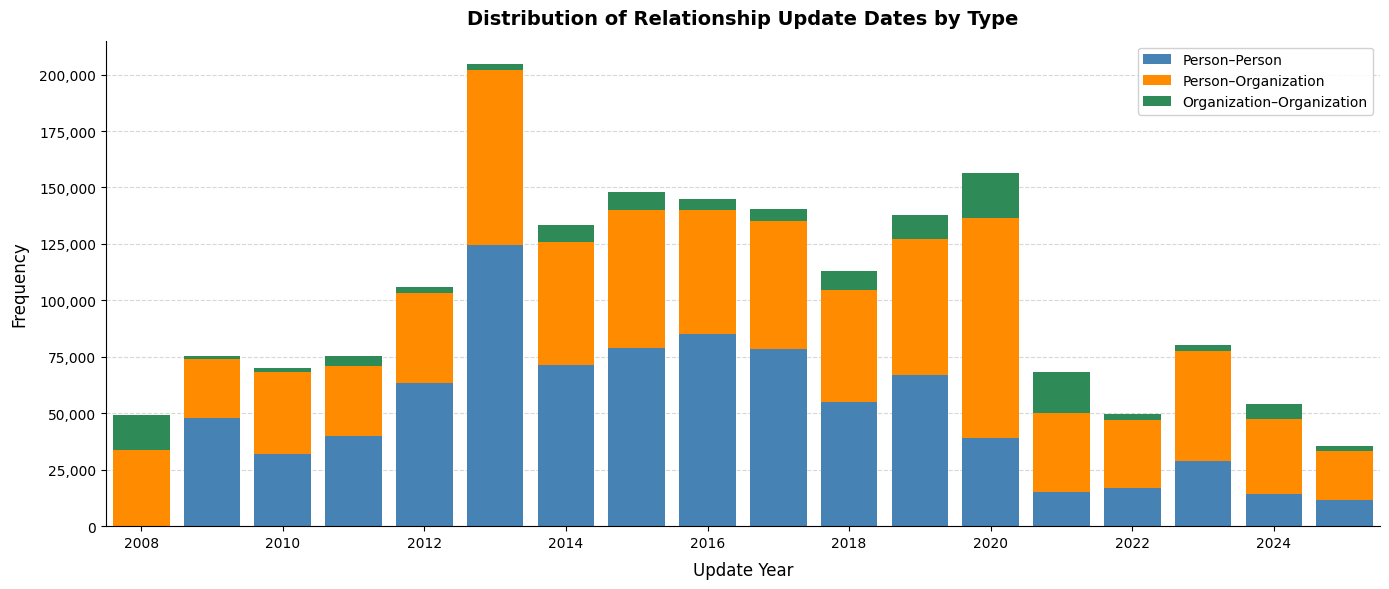

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def extract_update_years(rel_dict):
    return [int(rel_dict[r]['updated_at'][:4]) for r in rel_dict
            if rel_dict[r]['updated_at'] is not None]

years_upd_p2p = extract_update_years(person_to_person)
years_upd_p2o = extract_update_years(person_to_org)
years_upd_o2o = extract_update_years(org_to_org)

all_upd_years = years_upd_p2p + years_upd_p2o + years_upd_o2o
year_min, year_max = min(all_upd_years), max(all_upd_years)
bins = range(year_min, year_max + 2)
bin_years = np.array(list(bins[:-1]))

counts_upd_p2p = year_counts(years_upd_p2p, bins)
counts_upd_p2o = year_counts(years_upd_p2o, bins)
counts_upd_o2o = year_counts(years_upd_o2o, bins)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years, counts_upd_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_years, counts_upd_p2o, width=0.8,
       bottom=counts_upd_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_years, counts_upd_o2o, width=0.8,
       bottom=counts_upd_p2p + counts_upd_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')

ax.set_xlabel('Update Year', fontsize=12, labelpad=8)
ax.set_ylabel('Frequency', fontsize=12, labelpad=8)
ax.set_title('Distribution of Relationship Update Dates by Type',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(year_min - 0.5, year_max + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('update_date_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=False,
                          random_seed=42):
    """
    Build a graph from LittleSIS relationship dicts by adding edges in date
    order (ties broken randomly). Computes mean degree, max degree, and
    average clustering coefficient at the end of each calendar year.

    Parameters
    ----------
    rel_dicts : list of dict
    sort_by   : 'start_date' or 'updated_at'
    timing    : bool
    random_seed : int

    Returns
    -------
    yearly_stats : dict with keys 'year', 'mean_degree', 'max_degree',
                   'avg_clustering', each a list indexed by year
    D            : dict, terminal degree distribution {node: degree}
    G            : nx.Graph, terminal graph
    """
    rng = random.Random(random_seed)

    # -------------------------------------------------------------------------
    # (1/3) Collect, sort, deduplicate edges
    # -------------------------------------------------------------------------
    if timing:
        print("(1/3) Collecting and sorting edges", flush=True)
        t0 = time.time()

    raw = []
    for rel_dict in rel_dicts:
        for rel in rel_dict.values():
            date_str = rel.get(sort_by)
            if not date_str:
                continue
            u, v = rel['entity1_id'], rel['entity2_id']
            if u == v:
                continue
            raw.append((date_str, rng.random(), u, v))

    raw.sort(key=lambda x: (x[0], x[1]))

    seen_pairs = set()
    filtered = []
    for date_str, _, u, v in raw:
        key = (min(u, v), max(u, v))
        if key not in seen_pairs:
            seen_pairs.add(key)
            filtered.append((date_str, u, v))

    if timing:
        print(f"  {len(filtered)} unique edges. "
              f"Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (2/3) Evolve graph, compute stats at end of each year
    # -------------------------------------------------------------------------
    if timing:
        print("(2/3) Evolving graph and computing yearly stats", flush=True)
        t0 = time.time()

    G   = nx.Graph()
    D   = {}   # degree distribution: D[node] = degree

    yearly_stats = {
        'year':            [],
        'mean_degree':     [],
        'max_degree':      [],
        'avg_clustering':  [],
    }

    # Group edges by year for efficient yearly processing
    from itertools import groupby
    edges_by_year = {}
    for date_str, u, v in filtered:
        yr = int(date_str[:4])
        if yr not in edges_by_year:
            edges_by_year[yr] = []
        edges_by_year[yr].append((u, v))

    all_years = sorted(edges_by_year.keys())

    for yr in tqdm(all_years) if timing else all_years:
        for u, v in edges_by_year[yr]:
            # Add nodes if new
            for node in [u, v]:
                if node not in G:
                    G.add_node(node)
                    D[node] = 0
            # Add edge and update degree distribution
            G.add_edge(u, v)
            D[u] += 1
            D[v] += 1

        # End-of-year snapshot
        n_nodes = G.number_of_nodes()
        if n_nodes == 0:
            continue

        degrees      = list(D.values())
        mean_deg     = np.mean(degrees)
        max_deg      = np.max(degrees)
        avg_clust    = nx.average_clustering(G)

        yearly_stats['year'].append(yr)
        yearly_stats['mean_degree'].append(mean_deg)
        yearly_stats['max_degree'].append(max_deg)
        yearly_stats['avg_clustering'].append(avg_clust)

    if timing:
        print(f"  Done. Time: {time.time()-t0:.2f}s", flush=True)

    return yearly_stats, D, G


# =============================================================================
# Plot yearly graph statistics
# =============================================================================
def plot_graph_stats(yearly_stats, title='Graph Statistics — Annual Snapshots', save_path='graph_stats_yearly.pdf'):
    """
    Plot mean degree, max degree, and average clustering coefficient
    as annual time series.
    """
    years   = np.array(yearly_stats['year'])
    metrics = {
        'Mean Degree':                  yearly_stats['mean_degree'],
        'Max Degree':                   yearly_stats['max_degree'],
        'Avg. Clustering Coefficient':  yearly_stats['avg_clustering'],
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    for ax, (label, vals) in zip(axes, metrics.items()):
        ax.plot(years, vals, color='steelblue', linewidth=1.2,
                marker='o', markersize=4, markerfacecolor='white',
                markeredgecolor='steelblue', markeredgewidth=1.0)
        ax.set_title(label, fontsize=11, fontweight='bold', pad=6)
        ax.set_xlabel('Year', fontsize=10, labelpad=4)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x:,.3g}')
        )
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    fig.suptitle(title,
                 fontsize=13, fontweight='bold')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# Plot terminal degree distribution on log-log axes
# =============================================================================
def plot_degree_distribution(D, title='Terminal Degree Distribution', save_path='degree_distribution.pdf'):
    """
    Plot the terminal degree distribution on a log-log scale.
    Power-law exponent estimated via OLS (log-log) and MLE on log-binned data.
    """
    from collections import Counter
    from scipy import stats
    import powerlaw

    deg_counts = Counter(D.values())
    degrees    = np.array(sorted(deg_counts.keys()))
    counts     = np.array([deg_counts[d] for d in degrees])
    probs      = counts / counts.sum()

    # Log-binned version
    log_bins    = np.logspace(np.log10(max(1, degrees.min())),
                               np.log10(degrees.max()), 30)
    bin_counts, bin_edges = np.histogram(list(D.values()), bins=log_bins)
    bin_widths  = np.diff(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_density = bin_counts / (bin_counts.sum() * bin_widths)
    nonzero     = bin_counts > 0

    # --- OLS fit on log-binned data (middle 80% of log-x range) ---
    log_x = np.log10(bin_centers[nonzero])
    log_y = np.log10(bin_density[nonzero])
    lo    = np.percentile(log_x, 10)
    hi    = np.percentile(log_x, 90)
    mask  = (log_x >= lo) & (log_x <= hi) & np.isfinite(log_y)
    slope, intercept, r, _, _ = stats.linregress(log_x[mask], log_y[mask])
    gamma_ols = -slope
    r2_ols    = r**2

    x_fit = np.logspace(np.log10(bin_centers[nonzero].min()),
                         np.log10(bin_centers[nonzero].max()), 200)
    y_fit = 10**intercept * x_fit**(-gamma_ols)

    # --- MLE fit via powerlaw package on raw degree sequence ---
    degree_sequence = list(D.values())
    fit = powerlaw.Fit(degree_sequence, discrete=True, verbose=False)
    gamma_mle = fit.power_law.alpha
    xmin_mle  = fit.power_law.xmin

    # MLE fit line anchored to middle log-bin
    mid_idx    = len(bin_centers[nonzero]) // 2
    x_mid      = bin_centers[nonzero][mid_idx]
    y_mid      = bin_density[nonzero][mid_idx]
    x_mle      = np.logspace(np.log10(xmin_mle),
                              np.log10(bin_centers[nonzero].max()), 200)
    norm_mle   = y_mid * (x_mid ** gamma_mle)
    y_mle      = norm_mle * x_mle**(-gamma_mle)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # --- Left: raw, no fit ---
    axes[0].scatter(degrees, probs, color='steelblue', s=12,
                    alpha=0.7, edgecolors='none', label='Data')
    axes[0].plot(x_mle, y_mle, color='darkorange', linewidth=1.5,
                 linestyle=':',
                 label=(rf'MLE: $\gamma = {gamma_mle:.2f}$'))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Degree $k$', fontsize=16, labelpad=4)
    axes[0].set_ylabel('$P(k)$', fontsize=16, labelpad=4)
    axes[0].tick_params(axis='x', labelsize=14)
    axes[0].tick_params(axis='y', labelsize=14)
    axes[0].set_title('Degree Distribution', fontsize=16,
                       fontweight='bold', pad=6)
    axes[0].legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    axes[0].set_axisbelow(True)

    # --- Right: log-binned with OLS and MLE fits ---
    axes[1].scatter(bin_centers[nonzero], bin_density[nonzero],
                    color='steelblue', s=20, alpha=0.8,
                    edgecolors='none', label='Data')
    axes[1].plot(x_fit, y_fit, color='crimson', linewidth=1.5,
                 linestyle='--',
                 label=(rf'OLS: $\gamma = {gamma_ols:.2f}$, '
                        rf'$R^2 = {r2_ols:.3f}$'))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Degree $k$', fontsize=16, labelpad=4)
    axes[1].set_ylabel('$p(k)$ (density)', fontsize=16, labelpad=4)
    axes[1].set_title('Degree Distribution (log-binned)', fontsize=16,
                       fontweight='bold', pad=6)
    axes[1].tick_params(axis='x', labelsize=14)
    axes[1].tick_params(axis='y', labelsize=14)
    axes[1].legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    axes[1].set_axisbelow(True)

    fig.suptitle(title, fontsize=18,
                 fontweight='bold')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"OLS (log-binned): gamma = {gamma_ols:.3f}, R² = {r2_ols:.3f}")
    print(f"MLE (raw sequence): gamma = {gamma_mle:.3f}, "
          f"xmin = {xmin_mle:.1f}")

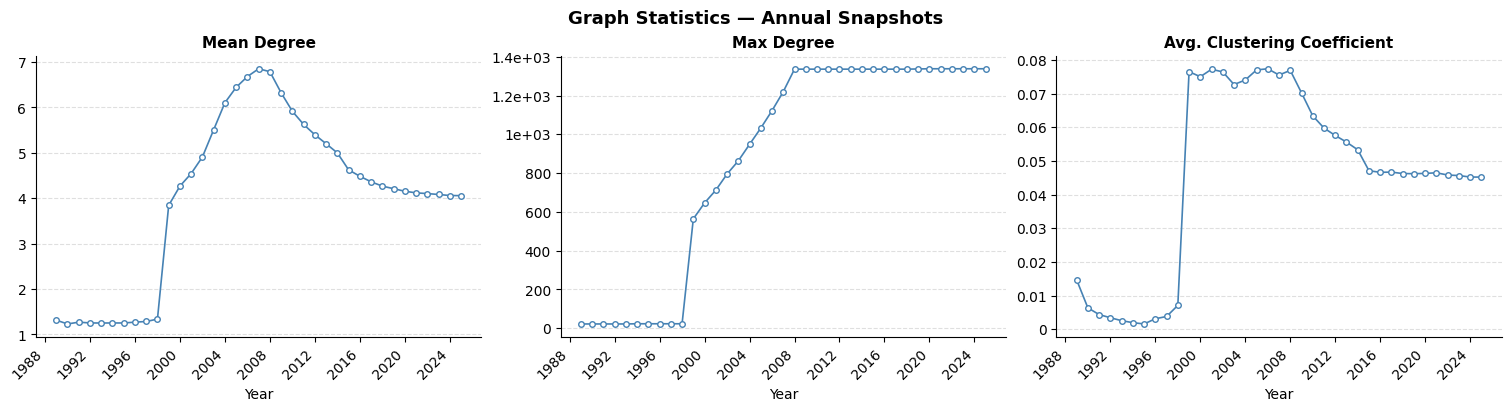

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:1982: DeprecationWarning: Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property will be removed in v2.1.
  warnings.warn("Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property will be removed in v2.1.",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.ut

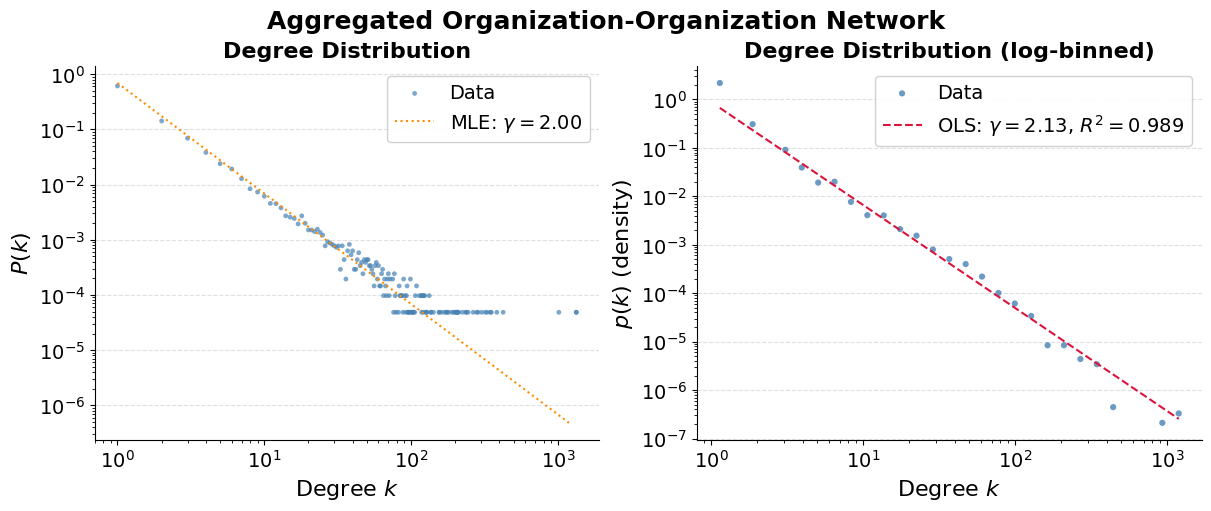

OLS (log-binned): gamma = 2.126, R² = 0.989
MLE (raw sequence): gamma = 2.002, xmin = 1.0


In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/o2o_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_o2o_start, D_o2o_start, G_o2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_o2o, has_start_end_o2o]
    yearly_stats_o2o_start, D_o2o_start, G_o2o_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_o2o_start, D_o2o_start, G_o2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_o2o_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_o2o_start, title='Aggregated Organization-Organization Network', save_path='degree_distribution.pdf')

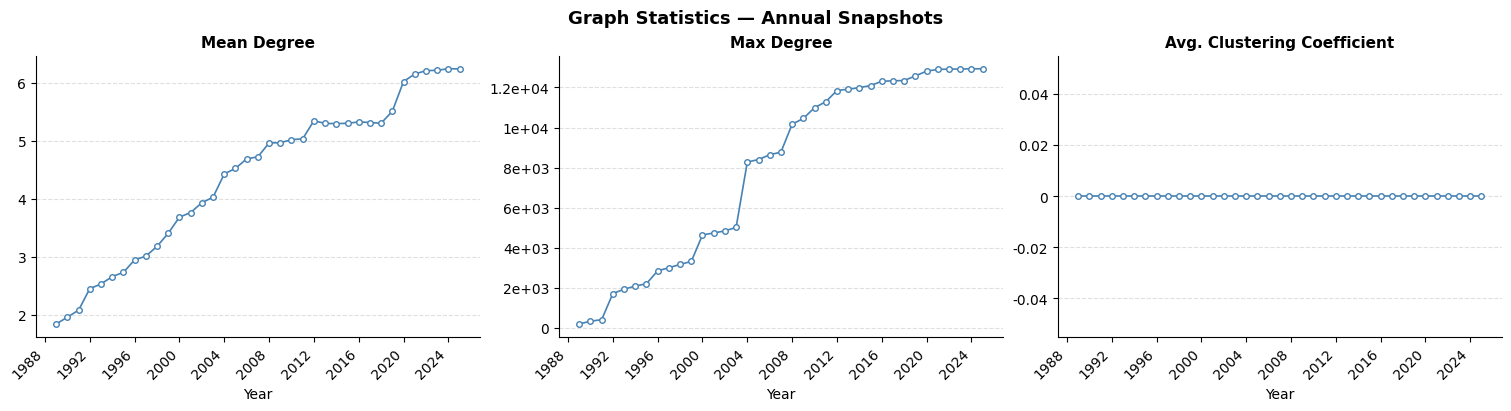

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:1982: DeprecationWarning: Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property will be removed in v2.1.
  warnings.warn("Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property 

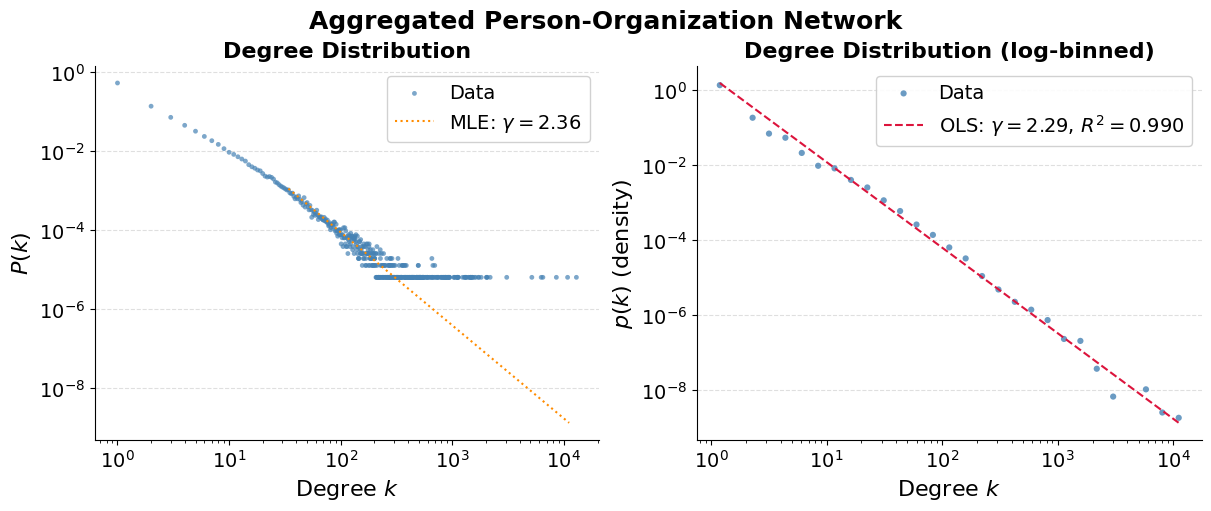

OLS (log-binned): gamma = 2.287, R² = 0.990
MLE (raw sequence): gamma = 2.357, xmin = 34.0


In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2o_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_p2o_start, D_p2o_start, G_p2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2o, has_start_end_p2o]
    yearly_stats_p2o_start, D_p2o_start, G_p2o_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_p2o_start, D_p2o_start, G_p2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_p2o_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_p2o_start, title='Aggregated Person-Organization Network', save_path='degree_distribution.pdf')

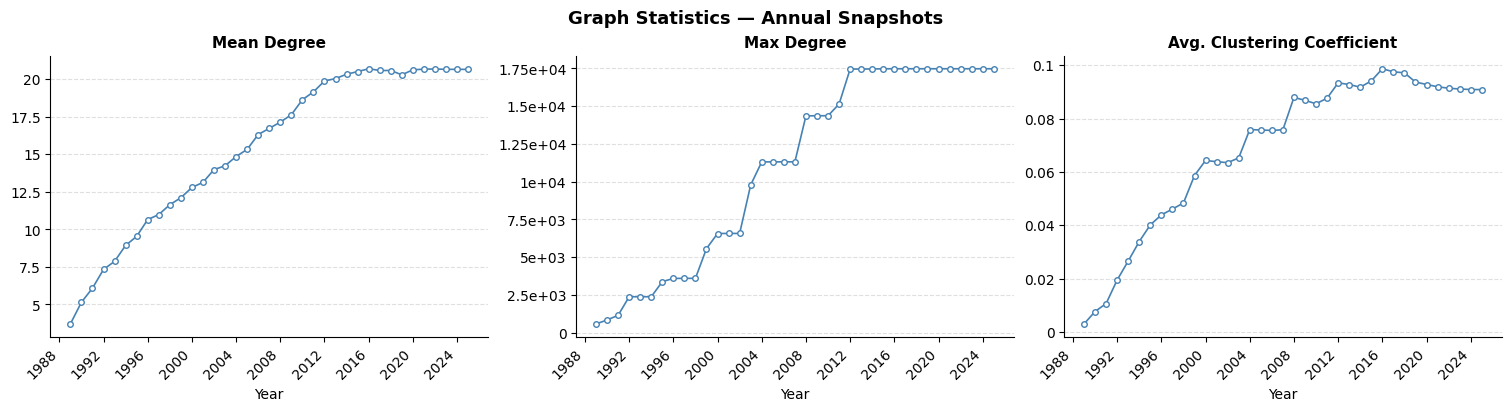

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:1982: DeprecationWarning: Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property will be removed in v2.1.
  warnings.warn("Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property will be removed in v2.1.",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.ut

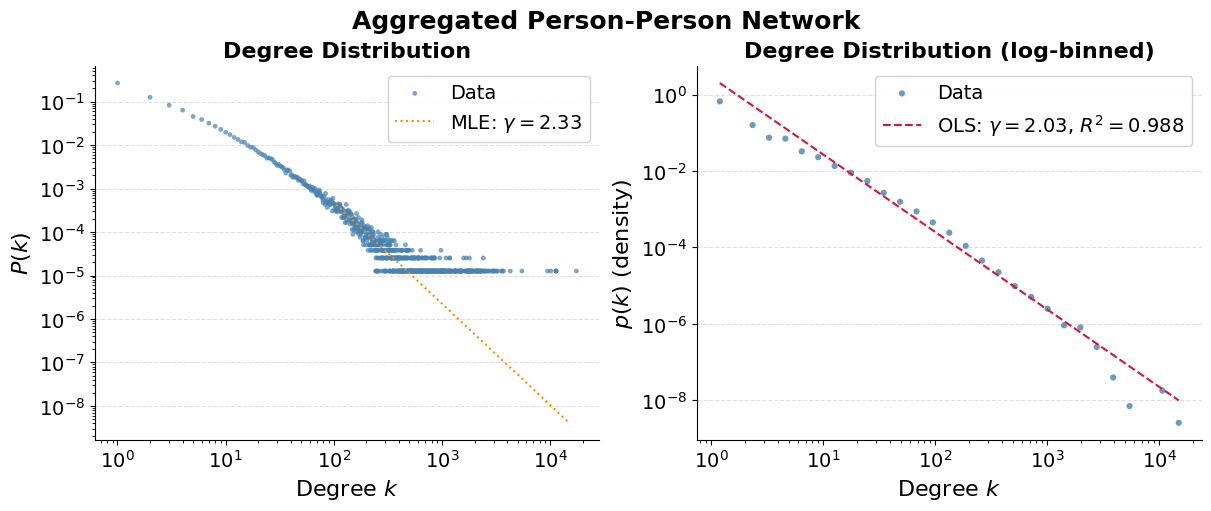

OLS (log-binned): gamma = 2.030, R² = 0.988
MLE (raw sequence): gamma = 2.330, xmin = 105.0


In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2p_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_p2p_start, D_p2p_start, G_p2p_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2p, has_start_end_p2p]
    yearly_stats_p2p_start, D_p2p_start, G_p2p_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_p2p_start, D_p2p_start, G_p2p_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_p2p_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_p2p_start, title='Aggregated Person-Person Network', save_path='degree_distribution.pdf')

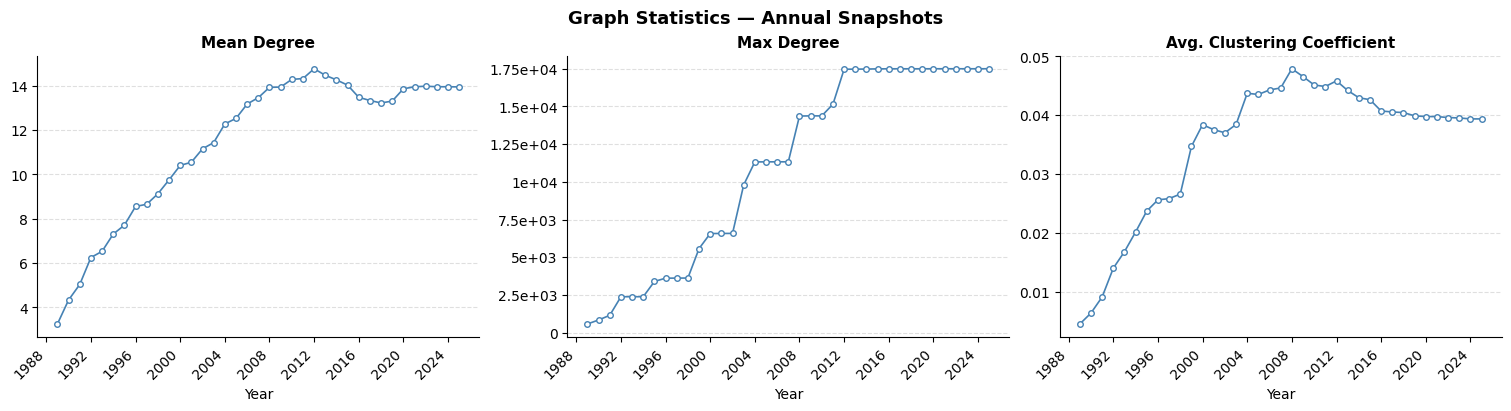

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:1982: DeprecationWarning: Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property will be removed in v2.1.
  warnings.warn("Standard error for the MLE should be accessed using the 'standard_err' property. Accessing via 'sigma' property 

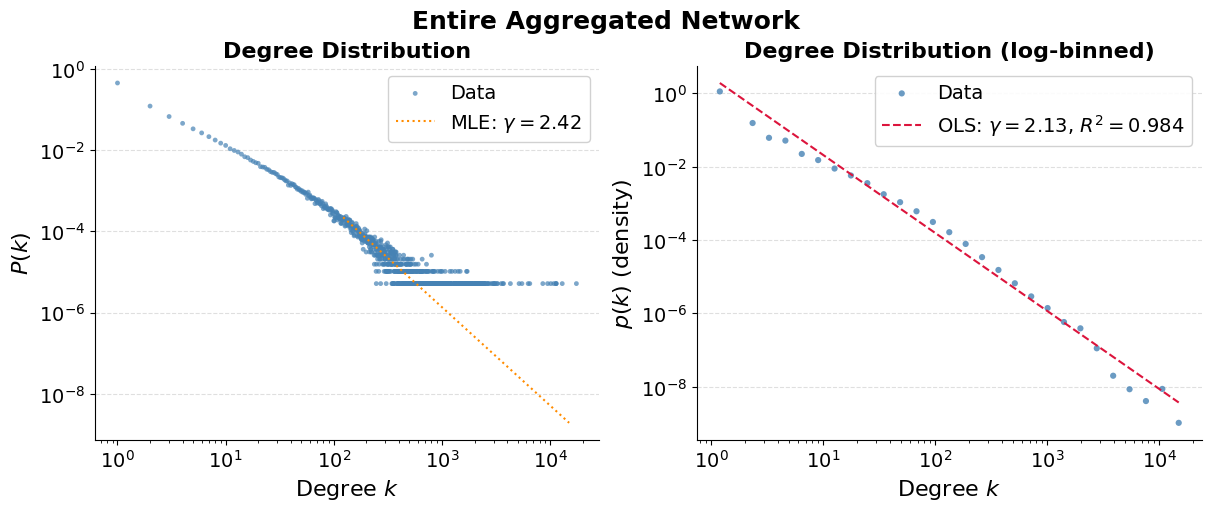

OLS (log-binned): gamma = 2.127, R² = 0.984
MLE (raw sequence): gamma = 2.422, xmin = 122.0


In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/all_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_all_start, D_all_start, G_all_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2p, has_start_end_p2p,
                 has_start_p2o, has_start_end_p2o,
                 has_start_o2o, has_start_end_o2o]
    yearly_stats_all_start, D_all_start, G_all_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_all_start, D_all_start, G_all_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_all_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_all_start, title='Entire Aggregated Network', save_path='degree_distribution.pdf')

In [ ]:
def graph_summary_from_yearly(yearly_stats_dict):
    """
    Extract terminal graph statistics from precomputed yearly stats
    and graph objects.

    Parameters
    ----------
    yearly_stats_dict : dict {name: (yearly_stats, G, D)}
        yearly_stats is the dict output of GraphStats_LittleSIS,
        G is the terminal graph, D is the terminal degree dict.

    Prints a summary table and returns a dict of statistics.
    """
    stats = {}

    print(f"{'Graph':<15} {'Nodes':>10} {'Edges':>10} "
          f"{'Mean Degree':>14} {'Avg Clustering':>16}")
    print("-" * 70)

    for name, (yearly_stats, G, D) in yearly_stats_dict.items():
        n_nodes   = G.number_of_nodes()
        n_edges   = G.number_of_edges()
        mean_deg  = yearly_stats['mean_degree'][-1]
        avg_clust = yearly_stats['avg_clustering'][-1]

        stats[name] = {
            'n_nodes':        n_nodes,
            'n_edges':        n_edges,
            'mean_degree':    mean_deg,
            'avg_clustering': avg_clust,
        }

        print(f"{name:<15} {n_nodes:>10,} {n_edges:>10,} "
              f"{mean_deg:>14.4f} {avg_clust:>16.4f}")

    return stats


yearly_stats_dict = {
    'P-P': (yearly_stats_p2p_start, G_p2p_start, D_p2p_start),
    'O-O': (yearly_stats_o2o_start, G_o2o_start, D_o2o_start),
    'P-O': (yearly_stats_p2o_start, G_p2o_start, D_p2o_start),
    'All': (yearly_stats_all_start, G_all_start, D_all_start)
}

summary_stats = graph_summary_from_yearly(yearly_stats_dict)

Graph                Nodes      Edges    Mean Degree   Avg Clustering
----------------------------------------------------------------------
P-P                 79,062    816,664        20.6588           0.0909
P-O                154,730    482,361         6.2349           0.0000
O-O                 20,612     41,824         4.0582           0.0452
All                192,250  1,340,849        13.9490           0.0394


(1/3) Collecting and sorting edges
  1340849 unique edges. Time: 4.29s
(2/3) Evolving graph and computing yearly stats


  0%|          | 0/18 [00:00<?, ?it/s]

  Done. Time: 6611.24s


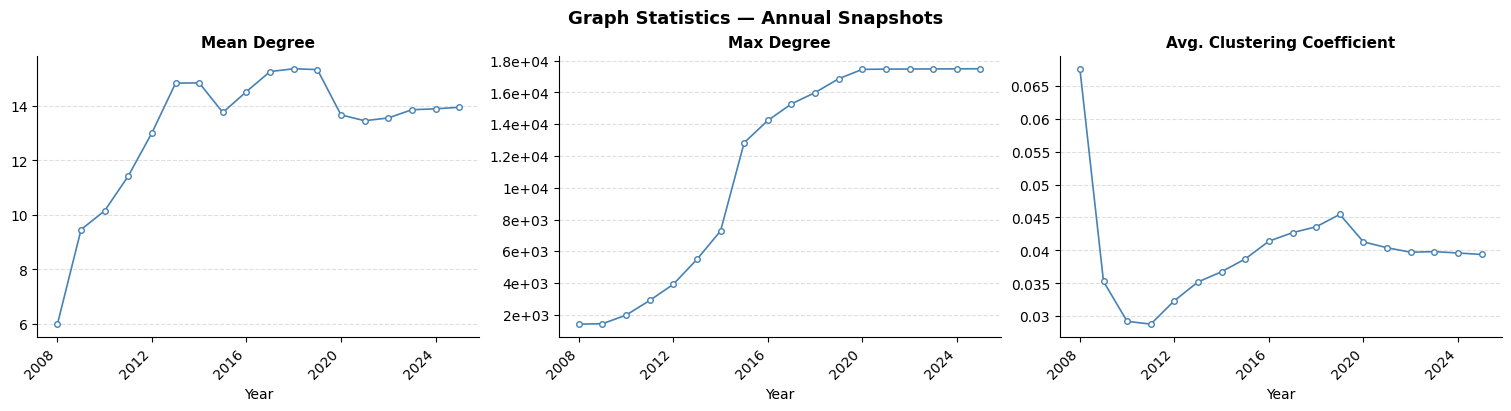

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rel_dicts = [has_start_p2p, has_start_end_p2p,
             has_start_p2o, has_start_end_p2o,
             has_start_o2o, has_start_end_o2o]
yearly_stats_all_update, D_all_update, G_all_update = GraphStats_LittleSIS(rel_dicts, sort_by='updated_at', timing=True,
                          random_seed=42)

plot_graph_stats(yearly_stats_all_update, save_path='graph_stats_yearly.pdf')

In [ ]:
def PH_LittleSIS(rel_dicts, sort_by='start_date', timing=False,
                 maxDim=np.inf, random_seed=42):
    """
    Build a graph from LittleSIS relationship dicts by adding edges in date
    order (ties broken randomly with fixed seed). Iteratively tracks simplex
    counts, average clustering coefficient, and cycle rank at each step, then
    computes persistent homology from the resulting filtration.

    Parameters
    ----------
    rel_dicts : list of dict
        Relationship dictionaries to draw edges from,
        e.g. [has_start_p2p, has_start_end_p2p].
        Pass multiple types (P-P, P-O, O-O) to build a multilayer graph.
    sort_by : str
        Date field used to order edge additions: 'start_date' or 'updated_at'.
    timing : bool
        If True, print progress messages and timing at each stage.
    maxDim : int or np.inf
        Maximum simplex dimension to track (e.g. maxDim=2 tracks up to triangles).
    random_seed : int
        Seed for tie-breaking among edges sharing the same date.

    Returns
    -------
    Betti        : np.ndarray, shape (4, n_steps)
    SimplexCounts: list of lists, one entry per edge-addition step
    Euler        : np.ndarray, shape (n_steps,)
    cycleR       : list, length n_steps
    dates        : list of str, the sort_by date string for each step
    """
    rng = random.Random(random_seed)

    # -------------------------------------------------------------------------
    # (1/5) Collect, sort, and deduplicate edges
    # -------------------------------------------------------------------------
    if timing:
        print("(1/5) Collecting and sorting edges", flush=True)
        t0 = time.time()

    raw = []
    for rel_dict in rel_dicts:
        for rel in rel_dict.values():
            date_str = rel.get(sort_by)
            if not date_str:
                continue
            u, v = rel['entity1_id'], rel['entity2_id']
            if u == v:
                continue  # skip self-loops
            raw.append((date_str, rng.random(), u, v))

    # Primary sort by date, secondary sort by random key (tie-breaking)
    raw.sort(key=lambda x: (x[0], x[1]))

    # Keep only the first occurrence of each undirected pair
    seen_pairs = set()
    filtered = []
    for date_str, _, u, v in raw:
        key = (min(u, v), max(u, v))
        if key not in seen_pairs:
            seen_pairs.add(key)
            filtered.append((date_str, u, v))

    n_steps = len(filtered)
    dates = [e[0] for e in filtered]

    if timing:
        print(f"  {n_steps} unique edges. Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (2/5) Initialize graph and data structures
    # -------------------------------------------------------------------------
    if timing:
        print("(2/5) Initializing graph and data structures", flush=True)
        t0 = time.time()

    G = nx.Graph()
    node_seen   = set()
    Times       = []       # (simplex, filtration_time) pairs for dionysus
    SimplexCounts = []     # one list of counts per step
    cycleR      = np.zeros(n_steps)

    if timing:
        print(f"  Done. Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (3/5) Evolve graph edge by edge
    # -------------------------------------------------------------------------
    if timing:
        print("(3/5) Evolving graph", flush=True)
        t0 = time.time()

    iterator = enumerate(tqdm(filtered)) if timing else enumerate(filtered)
    for timer, (date_str, u, v) in iterator:

        # Carry forward simplex counts from previous step
        current_counts = SimplexCounts[-1].copy() if SimplexCounts else []
        new_simplices = set()

        # Track newly introduced nodes as 0-simplices
        for node in [u, v]:
            if node not in node_seen:
                node_seen.add(node)
                G.add_node(node)
                new_simplices.add((node,))

        # Common neighbors before edge addition — these are exactly the nodes
        # that will form new triangles (and higher simplices) with (u,v)
        common = list(nx.common_neighbors(G, u, v))

        # Add edge; track as 1-simplex
        G.add_edge(u, v)
        new_simplices.add(tuple(sorted([u, v])))

        # Find all new higher-order simplices. A simplex is new iff it contains
        # both u and v (since the edge u-v is what makes it possible).
        # We search cliques in the subgraph induced by {u, v} + common neighbors.
        if common:
            H = G.subgraph([u, v] + common)
            for clique in nx.find_cliques(H):
              if u in clique and v in clique:
                clique_s = sorted(clique)
                for size in range(3, min(len(clique_s), maxDim) + 1):
                    for face in combinations(clique_s, size):
                        if u in face and v in face:
                            new_simplices.add(face)

        # Update simplex counts and filtration record
        for simplex in new_simplices:
            dim = len(simplex) - 1
            if dim > maxDim:
                continue
            while len(current_counts) <= dim:
                current_counts.append(0)
            current_counts[dim] += 1
            if dim <= 3:  # dionysus only needs simplices up to dim 3 for H0-H3
                Times.append((list(simplex), timer))

        SimplexCounts.append(current_counts)

        # Cycle rank: |E| - |V| (beta_0 correction added after PH)
        cycleR[timer] = G.number_of_edges() - G.number_of_nodes()

    if timing:
        print(f"  Evolution complete. Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (4/5) Persistent Homology
    # -------------------------------------------------------------------------
    if timing:
        print("(4/5) Computing Persistent Homology", flush=True)
        t0 = time.time()

    f = d.Filtration(Times)
    del Times
    gc.collect()
    m = d.homology_persistence(f)

    if timing:
        print(f"  PH complete. Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (5/5) Extract Betti numbers and Euler characteristic
    # -------------------------------------------------------------------------
    if timing:
        print("(5/5) Extracting Betti numbers and Euler characteristic", flush=True)
        t0 = time.time()

    Betti = np.zeros((4, n_steps))
    dgms = d.init_diagrams(m, f)
    for i, dgm in enumerate(dgms):
        if i >= 4:
            break
        for p in dgm:
            birth = int(p.birth)
            death = int(min(p.death, n_steps))
            Betti[i][birth:death] += 1

    Euler = np.zeros(n_steps)
    for i, counts in enumerate(SimplexCounts):
        for j, c in enumerate(counts):
            Euler[i] += (-1)**j * c

    # Add beta_0 correction to cycle rank
    cycleR = [cycleR[i] + Betti[0][i] for i in range(n_steps)]

    if timing:
        print(f"  Done. Time: {time.time()-t0:.2f}s", flush=True)

    return Betti, SimplexCounts, Euler, cycleR, dates

In [ ]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

LINE_COLOR = '#2c6fad'
LINE_KW    = dict(color=LINE_COLOR, lw=1.4, marker='o', markersize=3.5,
                  markerfacecolor='white', markeredgecolor=LINE_COLOR,
                  markeredgewidth=1.0)

# ── shared helpers ────────────────────────────────────────────────────────────

def _sc(SimplexCounts, dim, n):
    return np.array([
        SimplexCounts[t][dim] if len(SimplexCounts[t]) > dim else 0
        for t in range(n)
    ], dtype=float)

def _aggregate_yearly(arr, years, unique_years):
    out = np.full(len(unique_years), np.nan)
    for i, yr in enumerate(unique_years):
        mask = years == yr
        if np.any(mask):
            out[i] = arr[mask][-1]
    return out

def _style_ax(ax, xs, y, xlabel, x_is_dates=False):
    ax.plot(xs, y, **LINE_KW)
    if x_is_dates:
        ax.xaxis.set_major_locator(mdates.YearLocator(4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.set_xlabel(xlabel)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.3g}'))

def _yearly_xs_and_series(Betti, SimplexCounts, Euler, cycleR, dates):
    """Aggregate all quantities to end-of-year snapshots."""
    n    = len(SimplexCounts)
    b0   = Betti[0].astype(float)
    b1   = Betti[1].astype(float)
    b2   = Betti[2].astype(float)
    s0   = _sc(SimplexCounts, 0, n)
    s1   = _sc(SimplexCounts, 1, n)
    s2   = _sc(SimplexCounts, 2, n)
    s3   = _sc(SimplexCounts, 3, n)
    cr   = np.array(cycleR, dtype=float)
    chi  = np.array(Euler,  dtype=float)

    with np.errstate(invalid='ignore', divide='ignore'):
        tb0    = np.where(s0 > 0, b0 / s0, np.nan)
        tb1    = np.where(s1 > 0, b1 / s1, np.nan)
        tb2    = np.where(s2 > 0, b2 / s2, np.nan)
        cr1b1  = cr - b1
        cr2    = s2 - cr + b1            # CR2 = S2 - CR1 + b1
        cr2b2  = cr2 - b2
        g1     = np.where(s2 > 0, cr1b1 / s2, np.nan)
        g2     = np.where(s3 > 0, cr2b2 / s3, np.nan)

    years        = np.array([int(d[:4]) for d in dates])
    unique_years = np.arange(years.min(), years.max() + 1)

    def agg(arr):
        return _aggregate_yearly(arr, years, unique_years)

    raw = {
        's0': s0, 's1': s1, 's2': s2,
        'b0': b0, 'b1': b1, 'b2': b2,
        'tb0': tb0, 'tb1': tb1, 'tb2': tb2,
        'cr1b1': cr1b1, 'g1': g1,
        'cr2b2': cr2b2, 'g2': g2,
        'chi': chi,
    }
    yearly = {k: agg(v) for k, v in raw.items()}
    return unique_years, yearly

# ── Figure 1: N0 N1 N2 | b0 b1 b2 | tb0 tb1 tb2 ─────────────────────────────

def plot_ph_simplices_betti(Betti, SimplexCounts, Euler, cycleR, dates,
                            title='', save_path=None):
    """
    3×3 figure:
      Row 1: S0, S1, S2
      Row 2: β0, β1, β2
      Row 3: β̃0, β̃1, β̃2
    """
    xs, Y = _yearly_xs_and_series(Betti, SimplexCounts, Euler, cycleR, dates)
    xlabel = 'Year'

    panels = [
        (Y['s0'],  r'$N_0$ (nodes)'),
        (Y['s1'],  r'$N_1$ (edges)'),
        (Y['s2'],  r'$N_2$ (triangles)'),
        (Y['b0'],  r'$\beta_0$ (components)'),
        (Y['b1'],  r'$\beta_1$ (tunnels)'),
        (Y['b2'],  r'$\beta_2$ (voids)'),
        (Y['tb0'], r'$\tilde{\beta}_0 = \beta_0 / N_0$'),
        (Y['tb1'], r'$\tilde{\beta}_1 = \beta_1 / N_1$'),
        (Y['tb2'], r'$\tilde{\beta}_2 = \beta_2 / N_2$'),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    for ax, (y, label) in zip(axes.flatten(), panels):
        _style_ax(ax, xs, y, xlabel)
        ax.set_title(label, pad=6)

    if save_path:
        fig.savefig(save_path + '.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(save_path + '.png', dpi=300, bbox_inches='tight')
    plt.show()
    return fig

# ── Figure 2: CR1-b1 g1 | CR2-b2 g2 | Euler (centred) ───────────────────────

def plot_ph_cyclerank_euler(Betti, SimplexCounts, Euler, cycleR, dates,
                            title='', save_path=None):
    """
    Layout:
      Row 1 (2 cols): CR1−β1,  γ1
      Row 2 (2 cols): CR2−β2,  γ2
      Row 3 (1 col, centred): Euler characteristic
    """
    xs, Y = _yearly_xs_and_series(Betti, SimplexCounts, Euler, cycleR, dates)
    xlabel = 'Year'

    fig = plt.figure(figsize=(13, 10))
    fig.suptitle(title, fontsize=14)
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38,
                           left=0.07, right=0.97, top=0.92, bottom=0.07)

    # Row 1: 2 panels spanning cols 0-1 and 2-3
    ax_cr1b1 = fig.add_subplot(gs[0, :2])
    ax_g1    = fig.add_subplot(gs[0, 2:])

    # Row 2: 2 panels
    ax_cr2b2 = fig.add_subplot(gs[1, :2])
    ax_g2    = fig.add_subplot(gs[1, 2:])

    # Row 3: 1 centred panel spanning middle 2 cols
    ax_chi   = fig.add_subplot(gs[2, 1:3])

    panels = [
        (ax_cr1b1, Y['cr1b1'], r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)'),
        (ax_g1,    Y['g1'],    r'$\gamma_1 = (\mathcal{CR}_1 - \beta_1)\,/\,N_2$'),
        (ax_cr2b2, Y['cr2b2'], r'$\mathcal{CR}_2 - \beta_2$ (filled voids)'),
        (ax_g2,    Y['g2'],    r'$\gamma_2 = (\mathcal{CR}_2 - \beta_2)\,/\,N_3$'),
        (ax_chi,   Y['chi'],   r'$\chi$ (Euler characteristic)'),
    ]

    for ax, y, label in panels:
        _style_ax(ax, xs, y, xlabel)
        ax.set_title(label, pad=6)

    if save_path:
        fig.savefig(save_path + '.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(save_path + '.png', dpi=300, bbox_inches='tight')
    plt.show()
    return fig

# ── Figure 3: N0 N1 | b0 b1 | tb0 tb1 ───────────────────────────────────────

def plot_ph_graph(Betti, SimplexCounts, Euler, cycleR, dates,
                  title='', save_path=None):
    """
    3×2 figure restricted to graph-level (dim 0 and 1) quantities:
      Row 1: N0, N1
      Row 2: β0, β1
      Row 3: β̃0, β̃1
    """
    xs, Y  = _yearly_xs_and_series(Betti, SimplexCounts, Euler, cycleR, dates)
    xlabel = 'Year'

    panels = [
        (Y['s0'],  r'$N_0$ (vertices)'),
        (Y['s1'],  r'$N_1$ (edges)'),
        (Y['b0'],  r'$\beta_0$ (components)'),
        (Y['b1'],  r'$\beta_1$ (tunnels)'),
        (Y['tb0'], r'$\tilde{\beta}_0 = \beta_0 / N_0$'),
        (Y['tb1'], r'$\tilde{\beta}_1 = \beta_1 / N_1$'),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(10, 10), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    for ax, (y, label) in zip(axes.flatten(), panels):
        _style_ax(ax, xs, y, xlabel)
        ax.set_title(label, pad=6)

    if save_path:
        fig.savefig(save_path + '.png', dpi=300, bbox_inches='tight')
    plt.show()
    return fig

# ── convenience wrapper matching original plot_ph_yearly signature ────────────

def plot_ph_yearly(Betti, SimplexCounts, Euler, cycleR, dates,
                   title='', save_path='ph_yearly'):
    plot_ph_simplices_betti(Betti, SimplexCounts, Euler, cycleR, dates,
                            title=title,
                            save_path=save_path + '_fig1')
    plot_ph_cyclerank_euler(Betti, SimplexCounts, Euler, cycleR, dates,
                            title=title,
                            save_path=save_path + '_fig2')

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_math

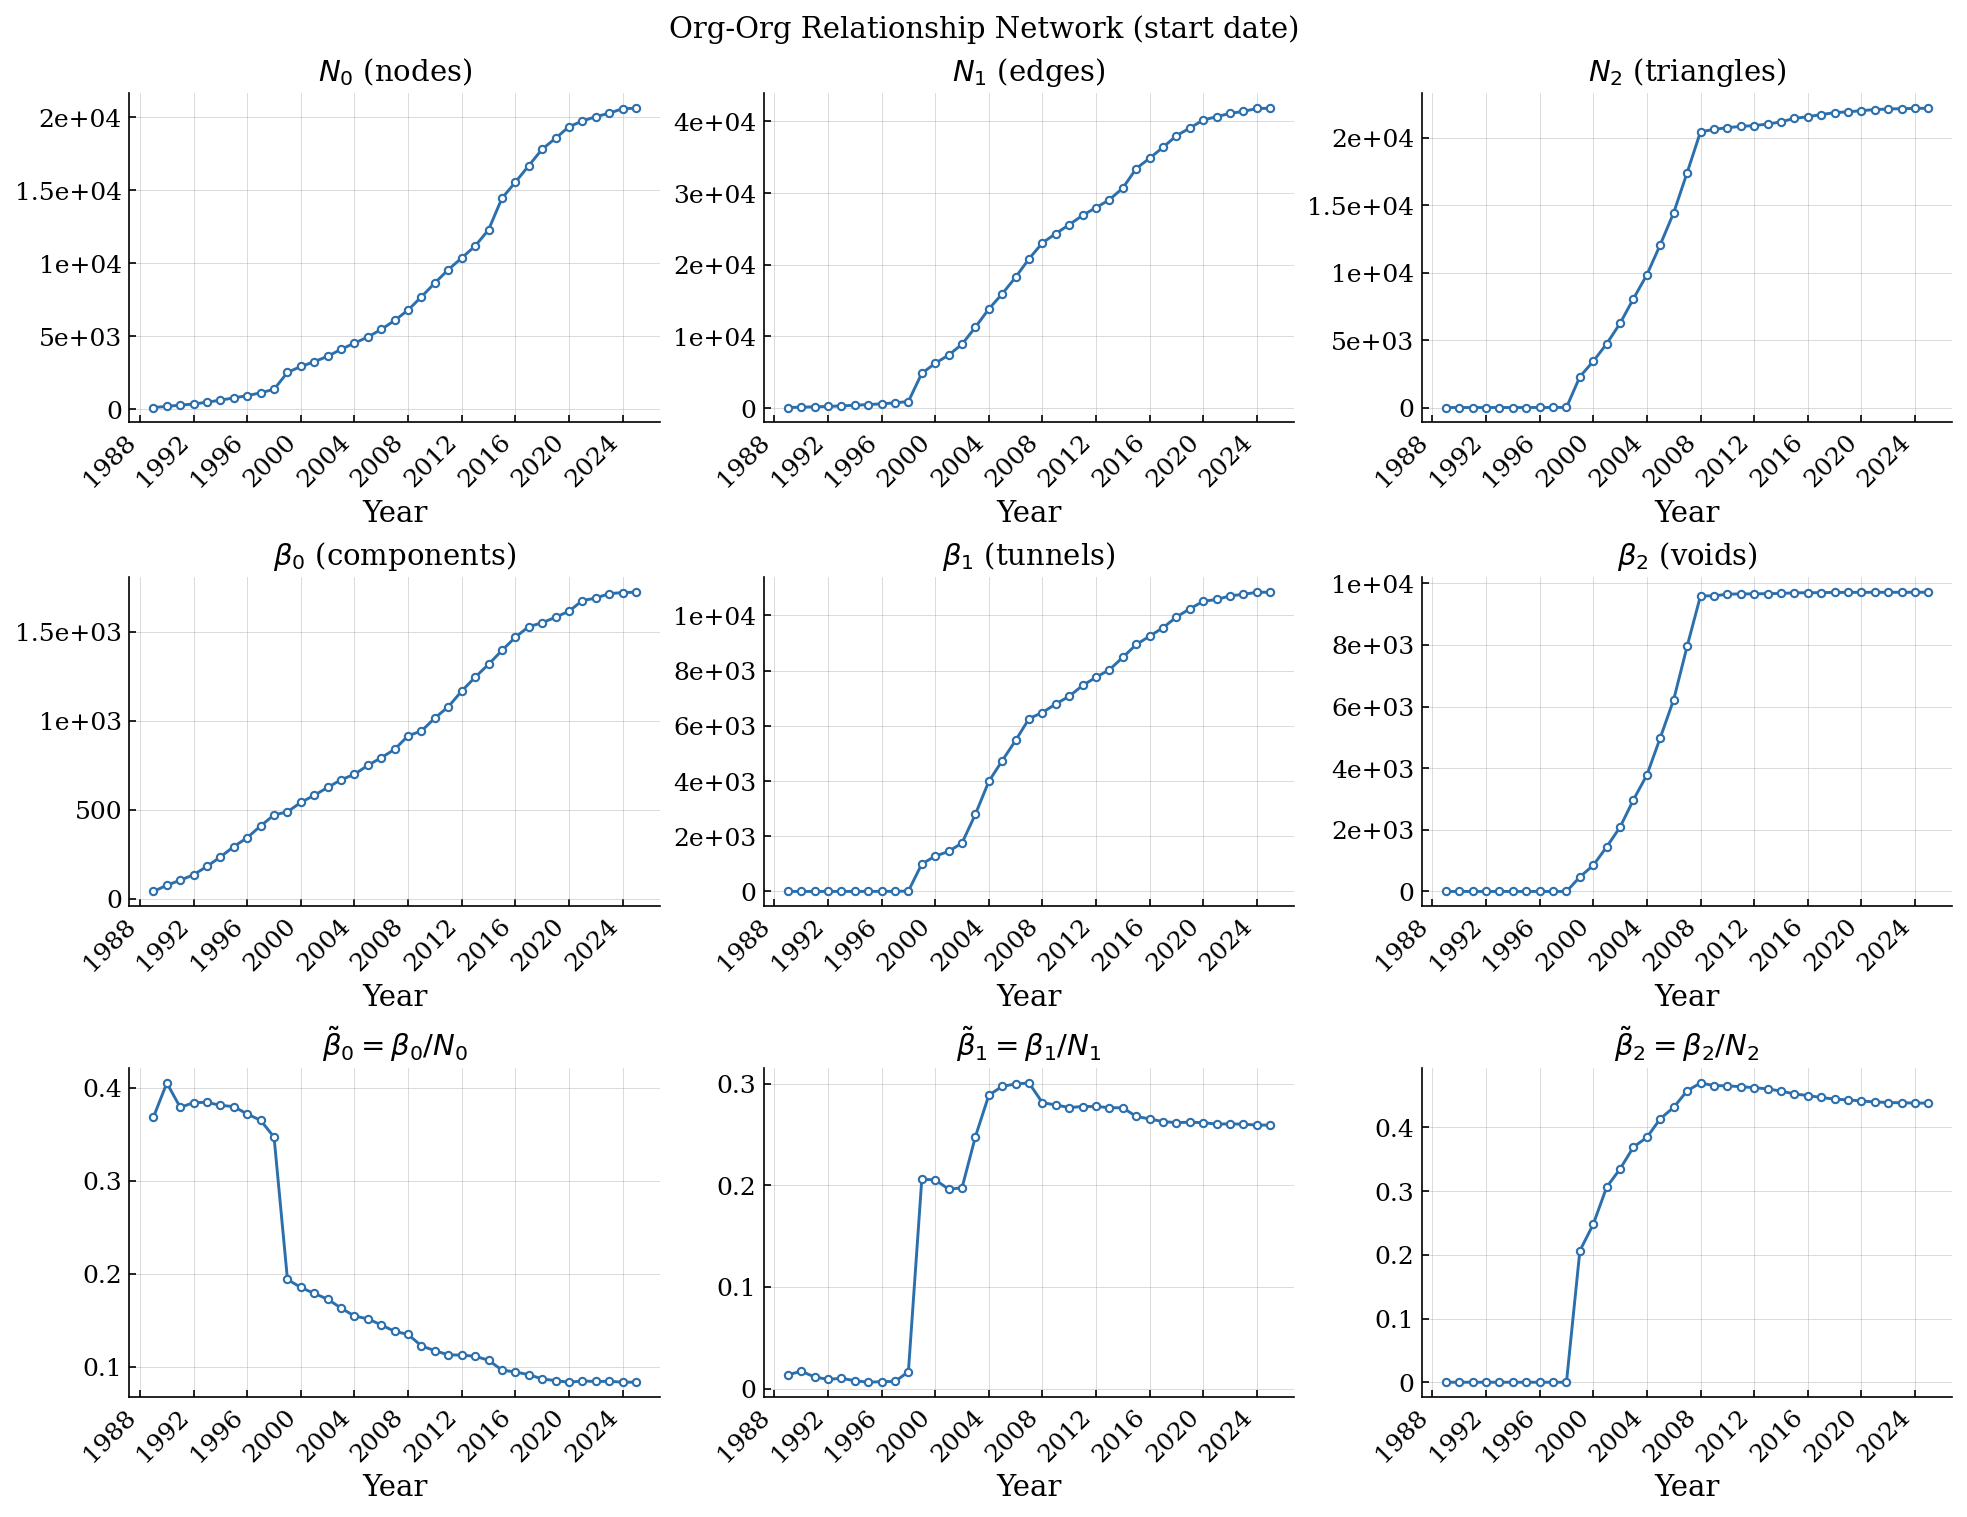

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

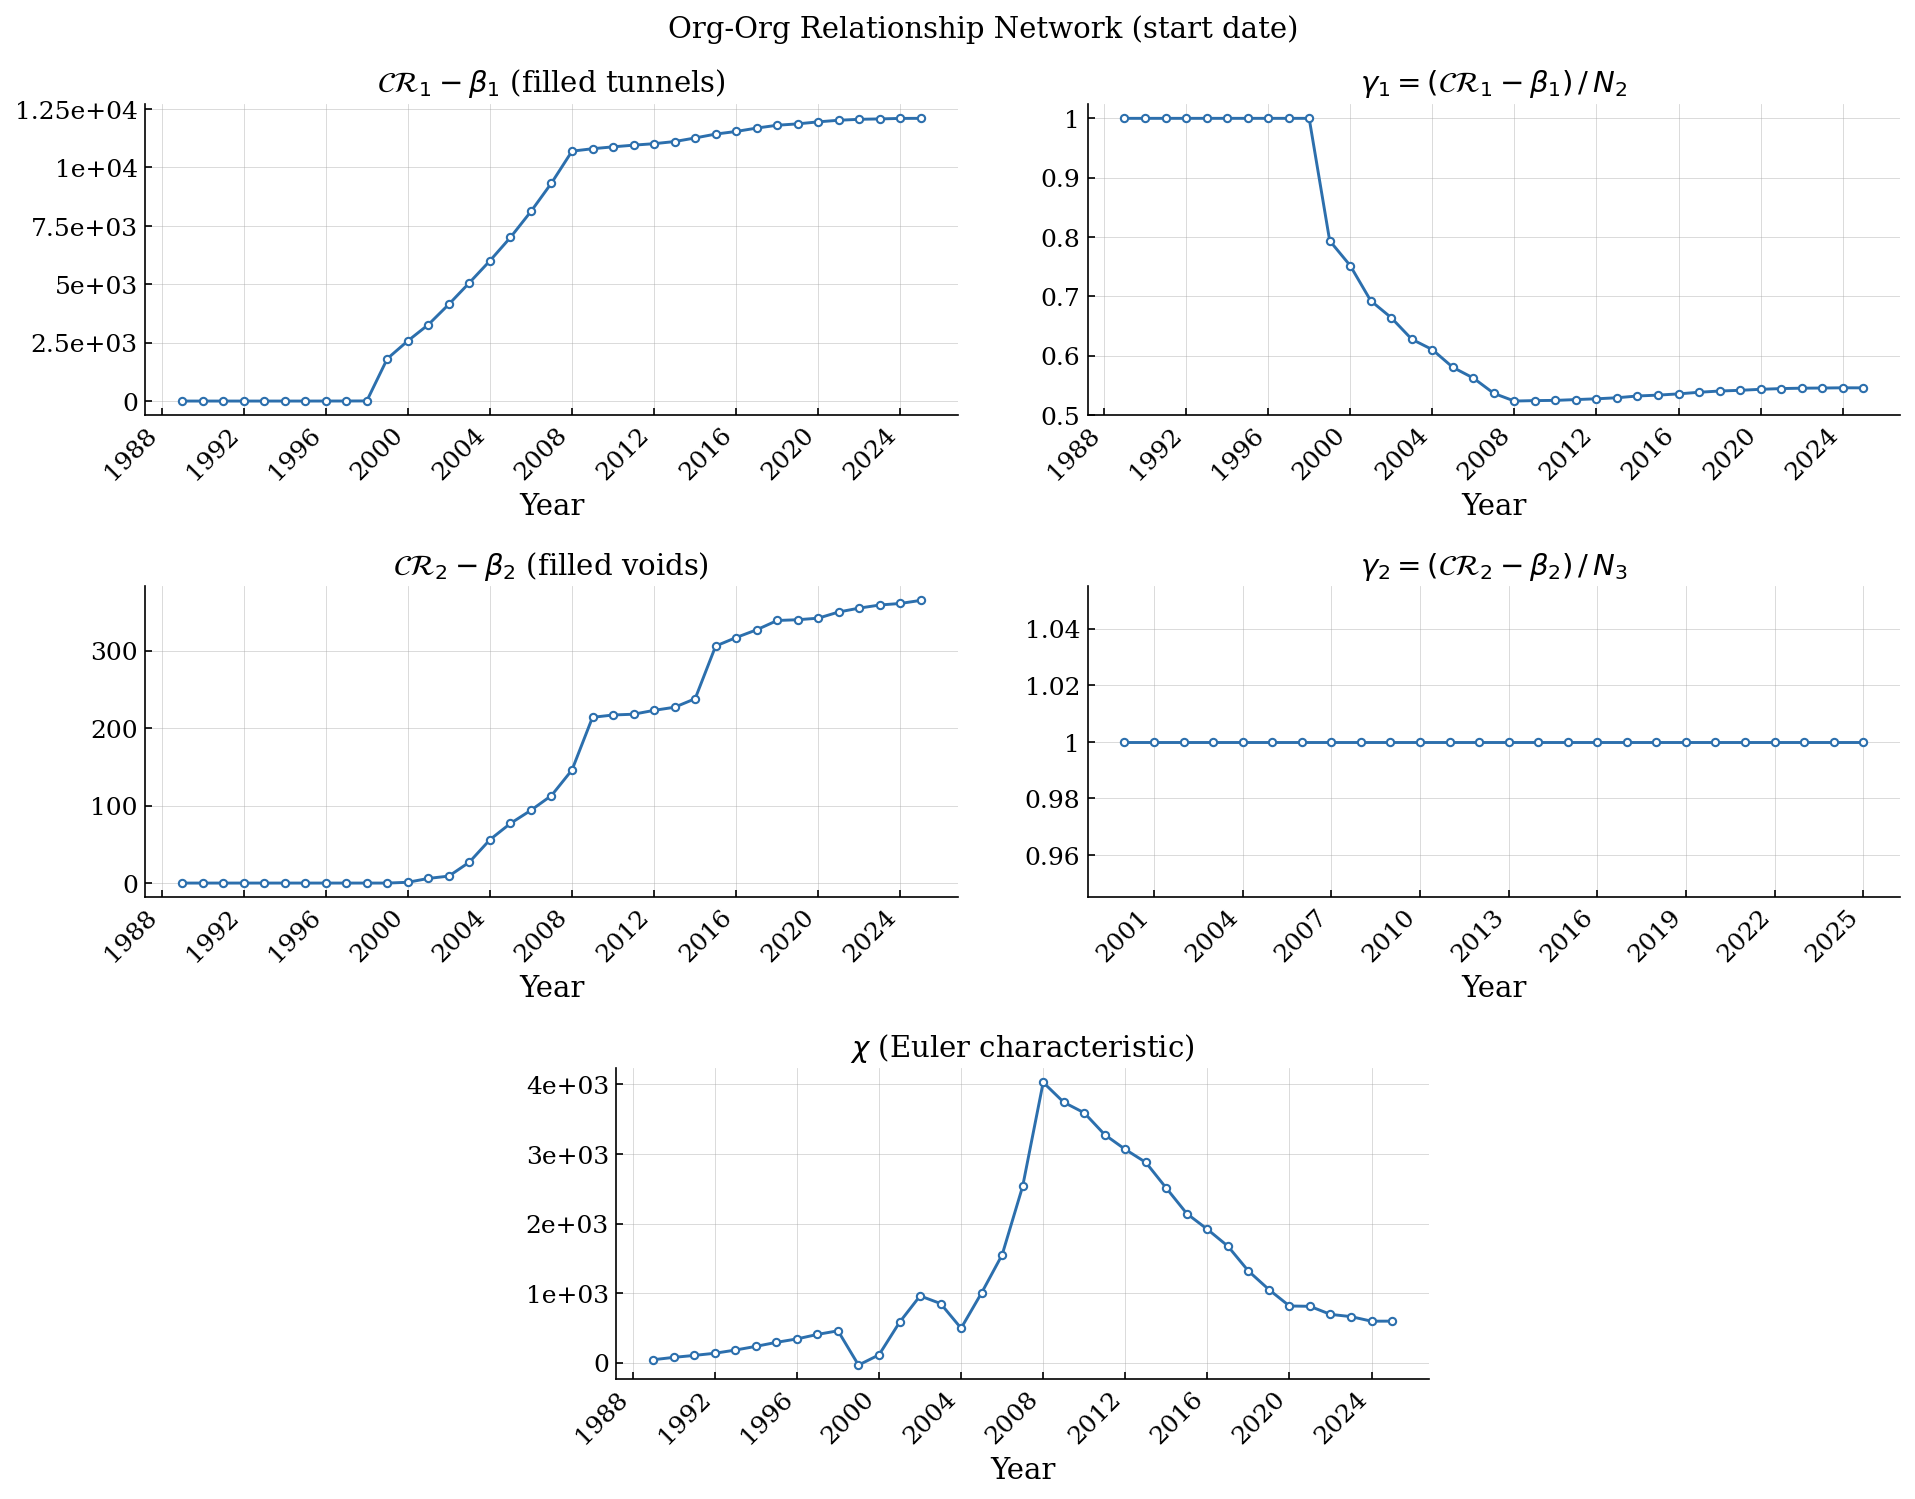

In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/o2o_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_o2o, has_start_end_o2o]
    Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start,
                   save_path='ph_yearly.pdf',title='Org-Org Relationship Network (start date)')

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

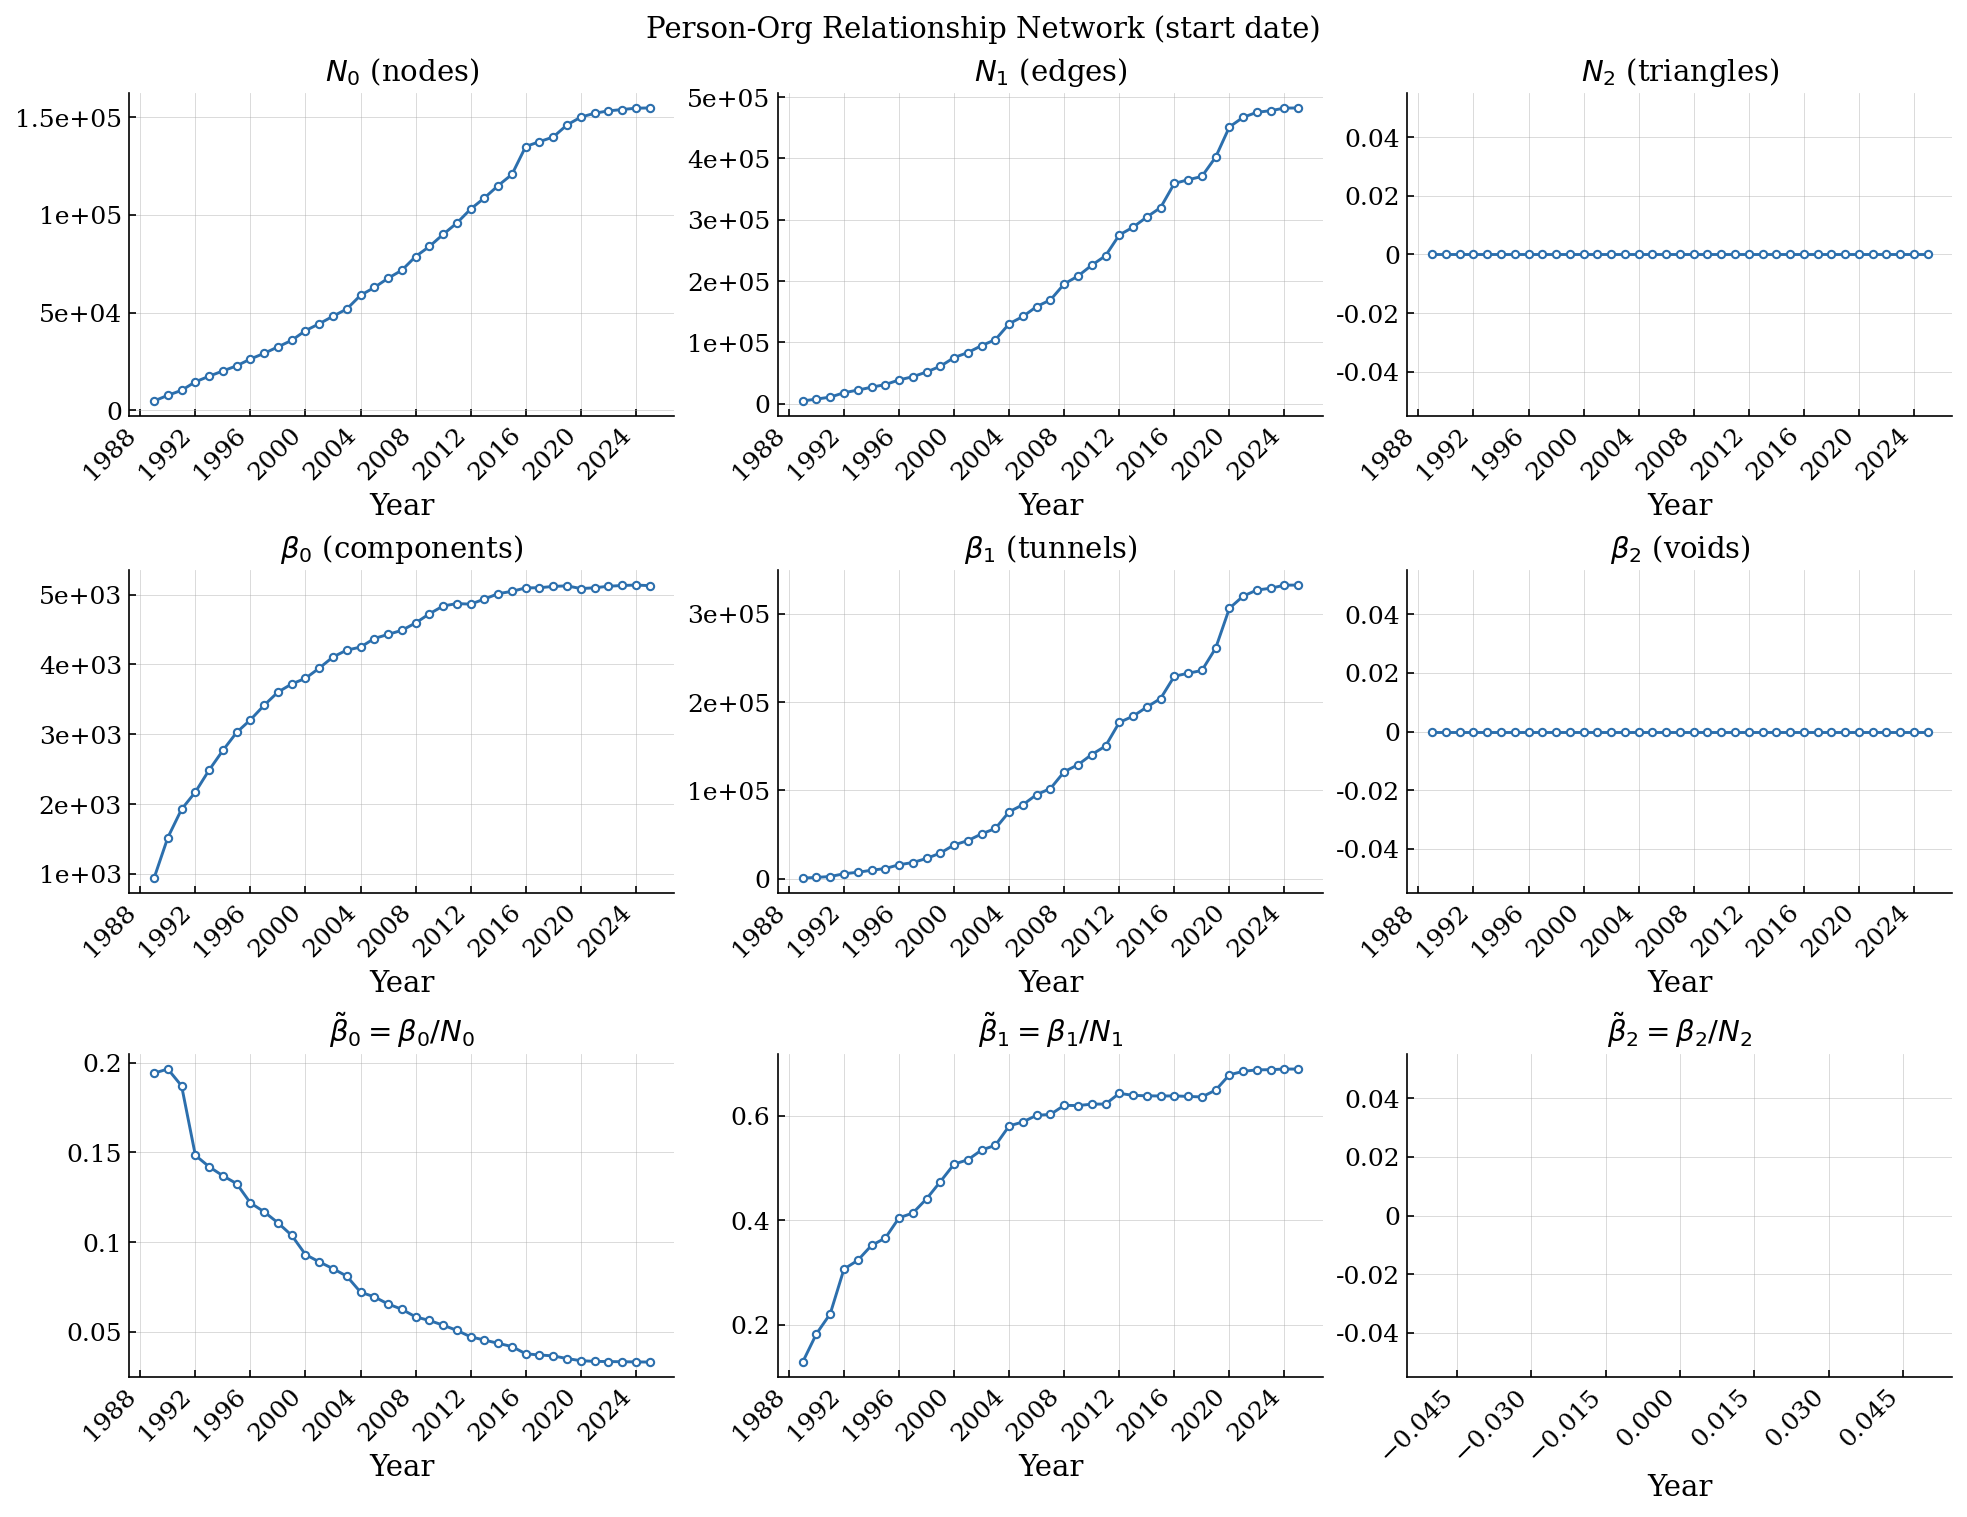

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

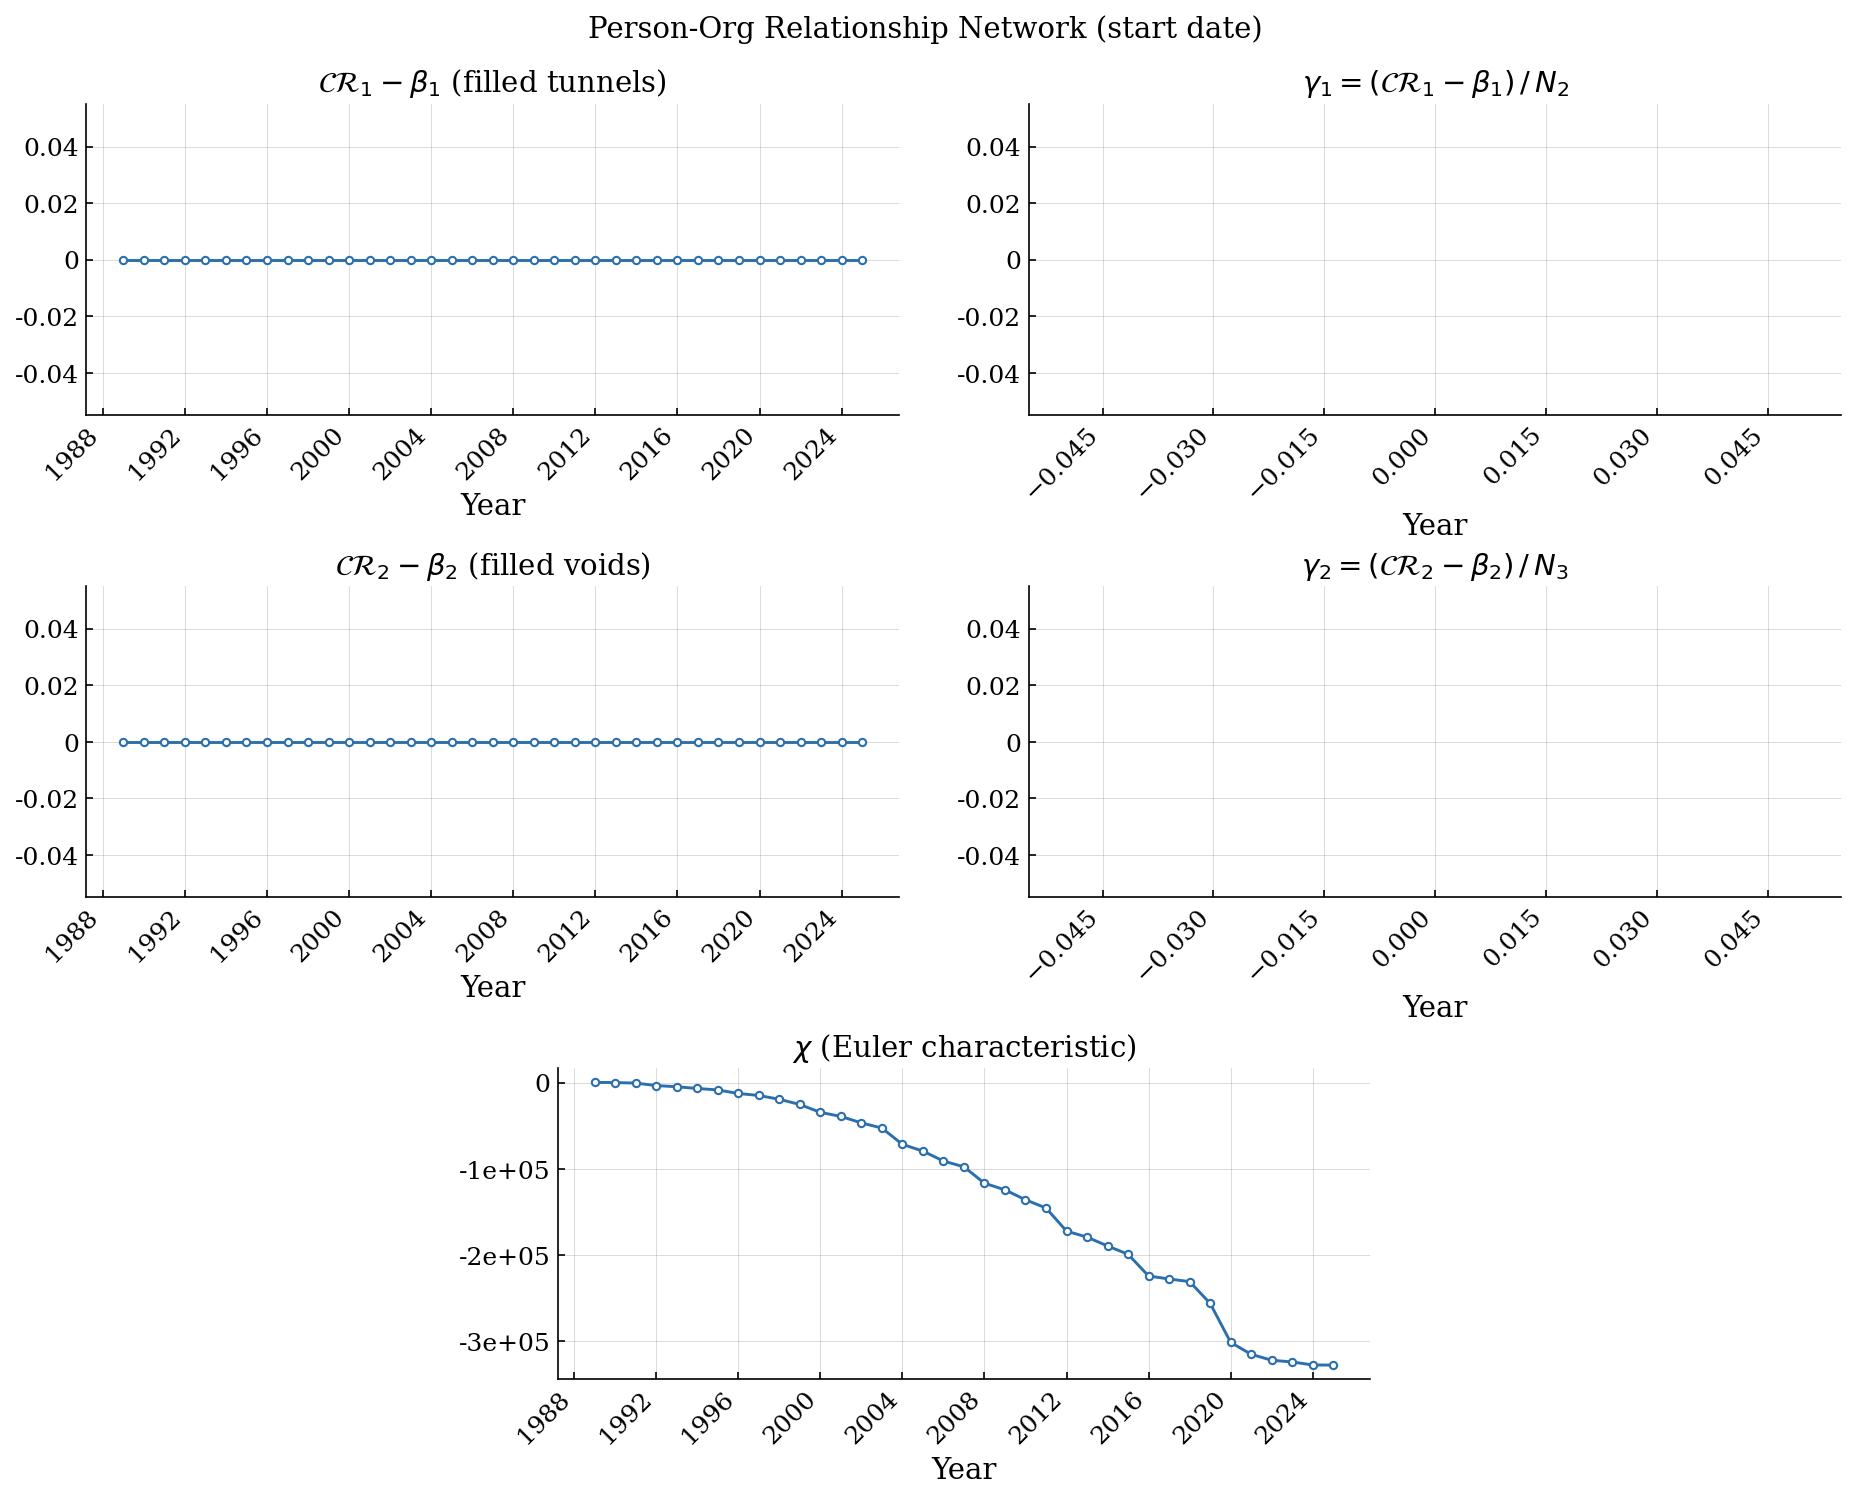

In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2o_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2o, has_start_end_p2o]
    Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start,
                   save_path='ph_yearly.pdf',title='Person-Org Relationship Network (start date)')

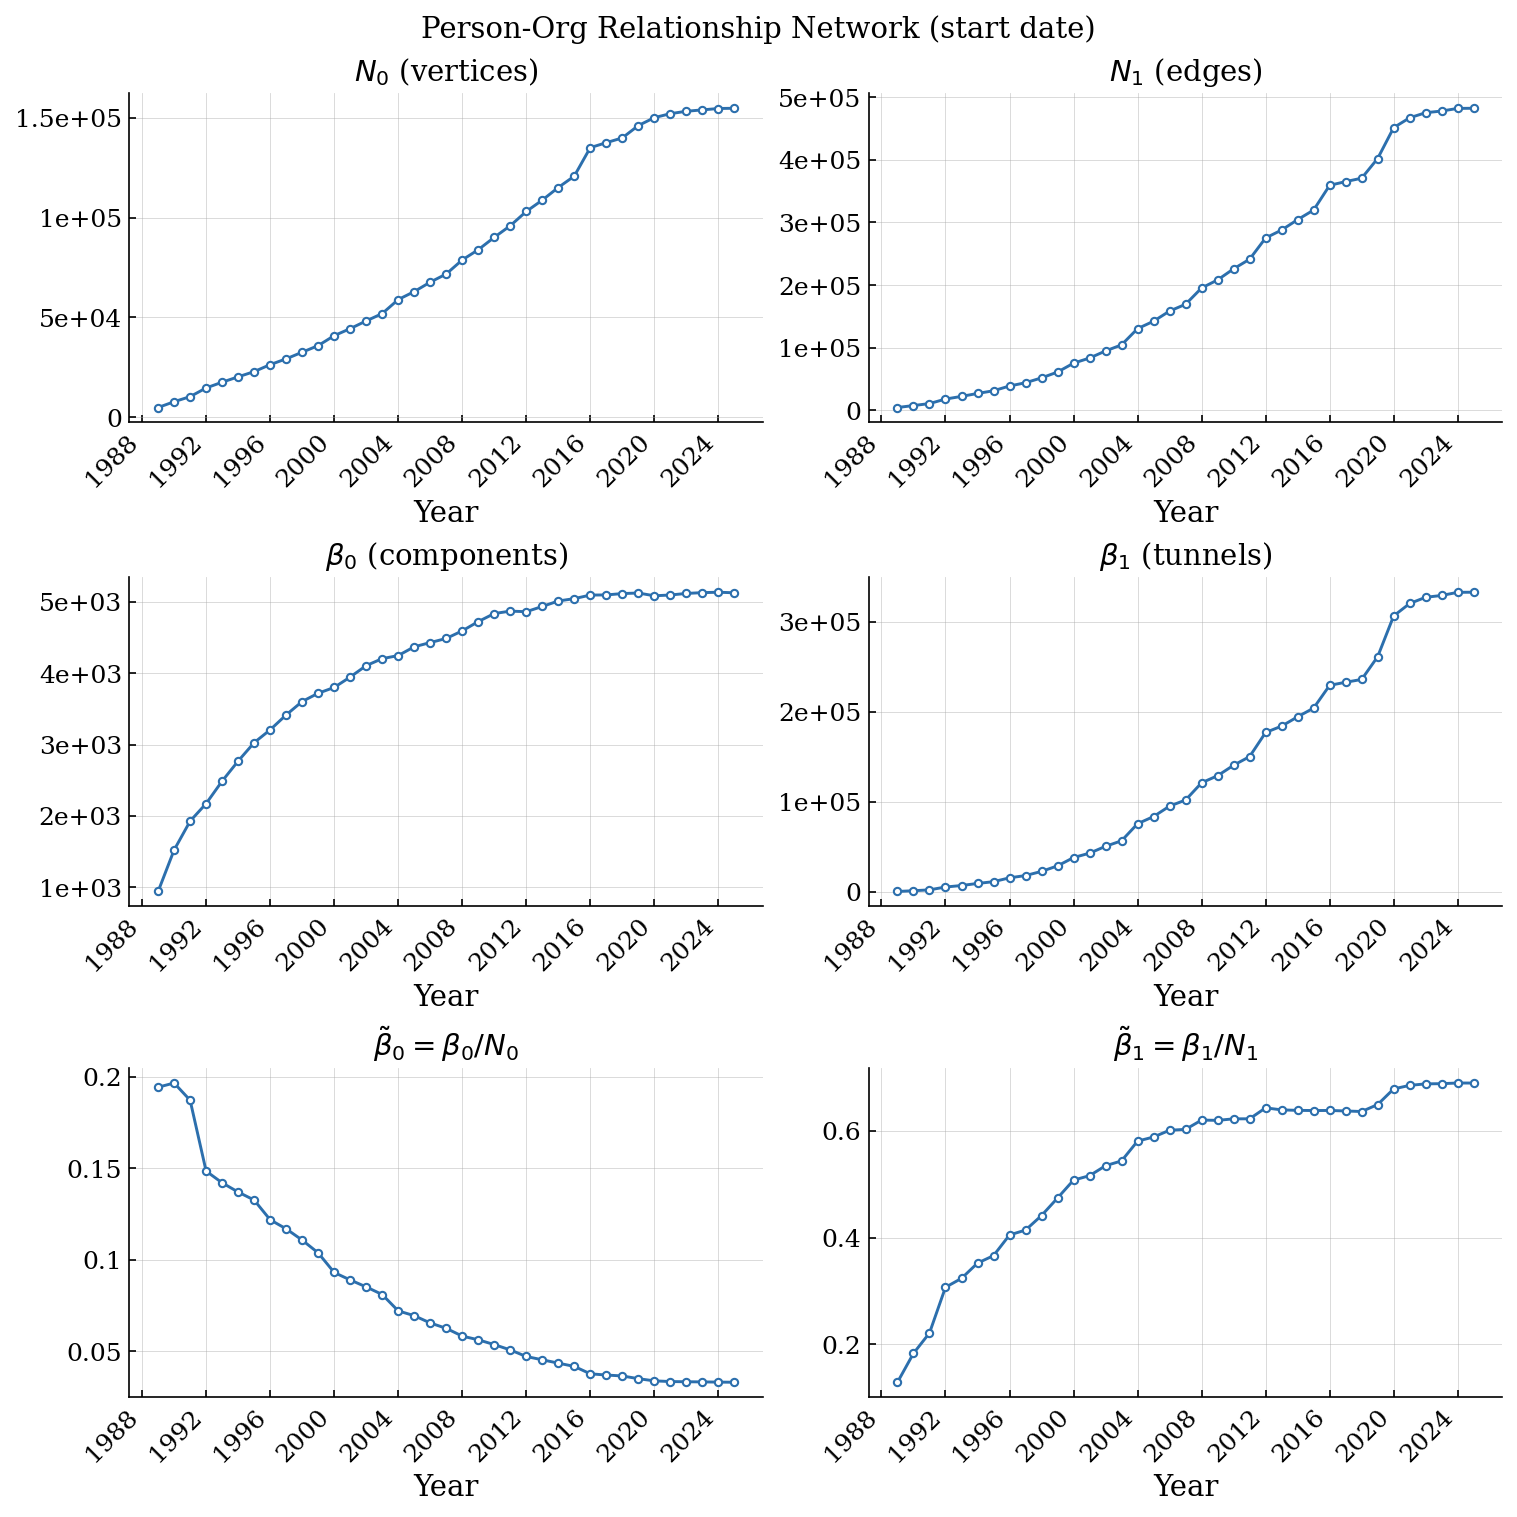

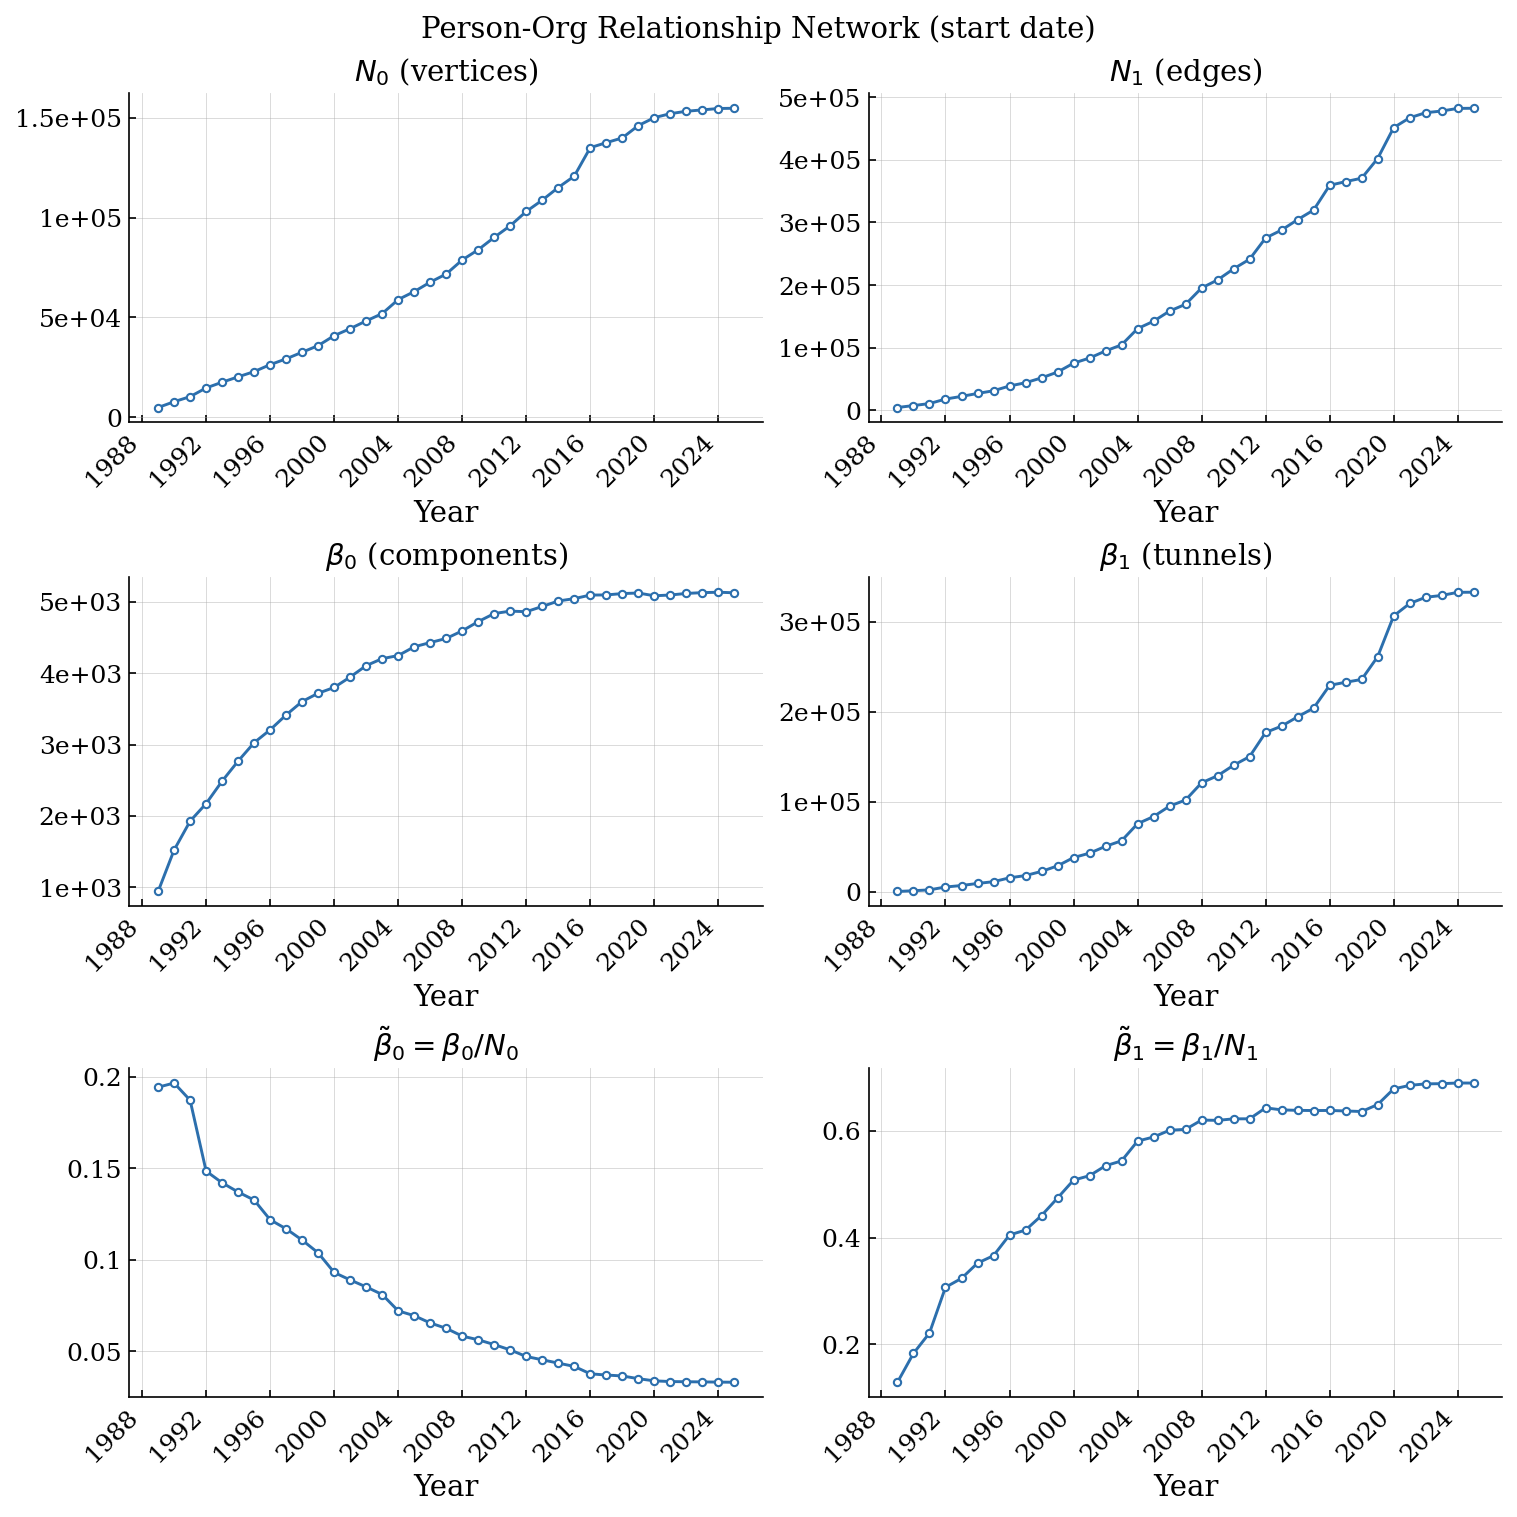

In [ ]:
plot_ph_graph(Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start,
              cycleR_p2o_start, dates_p2o_start,
              title='Person-Org Relationship Network (start date)',
              save_path='ph_p2o_start_graph')

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

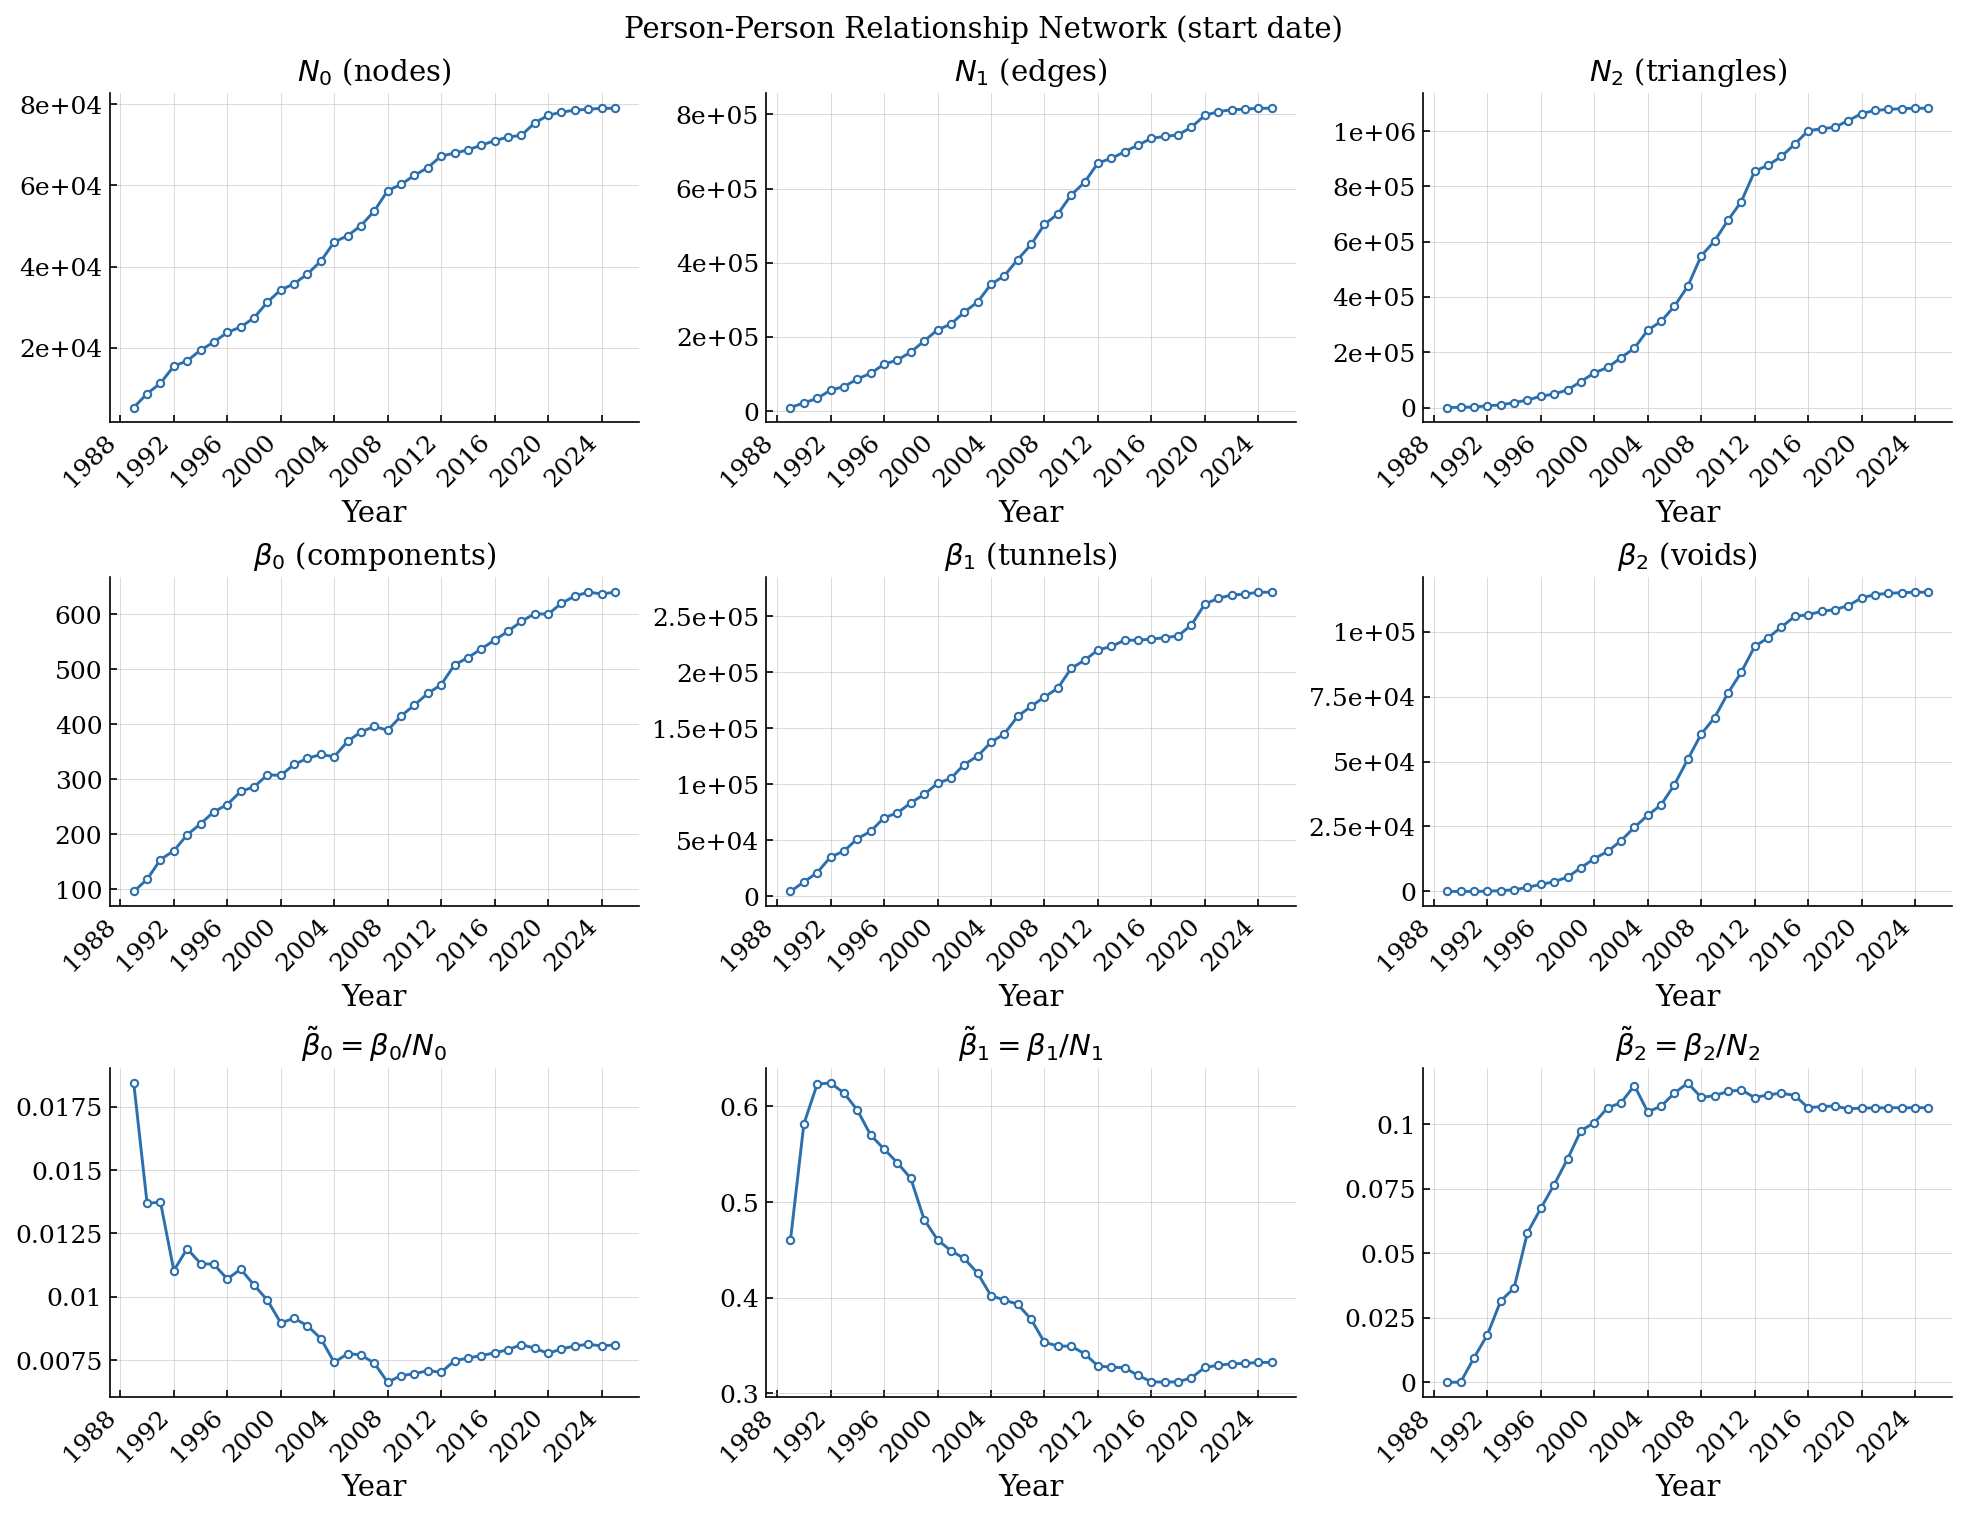

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

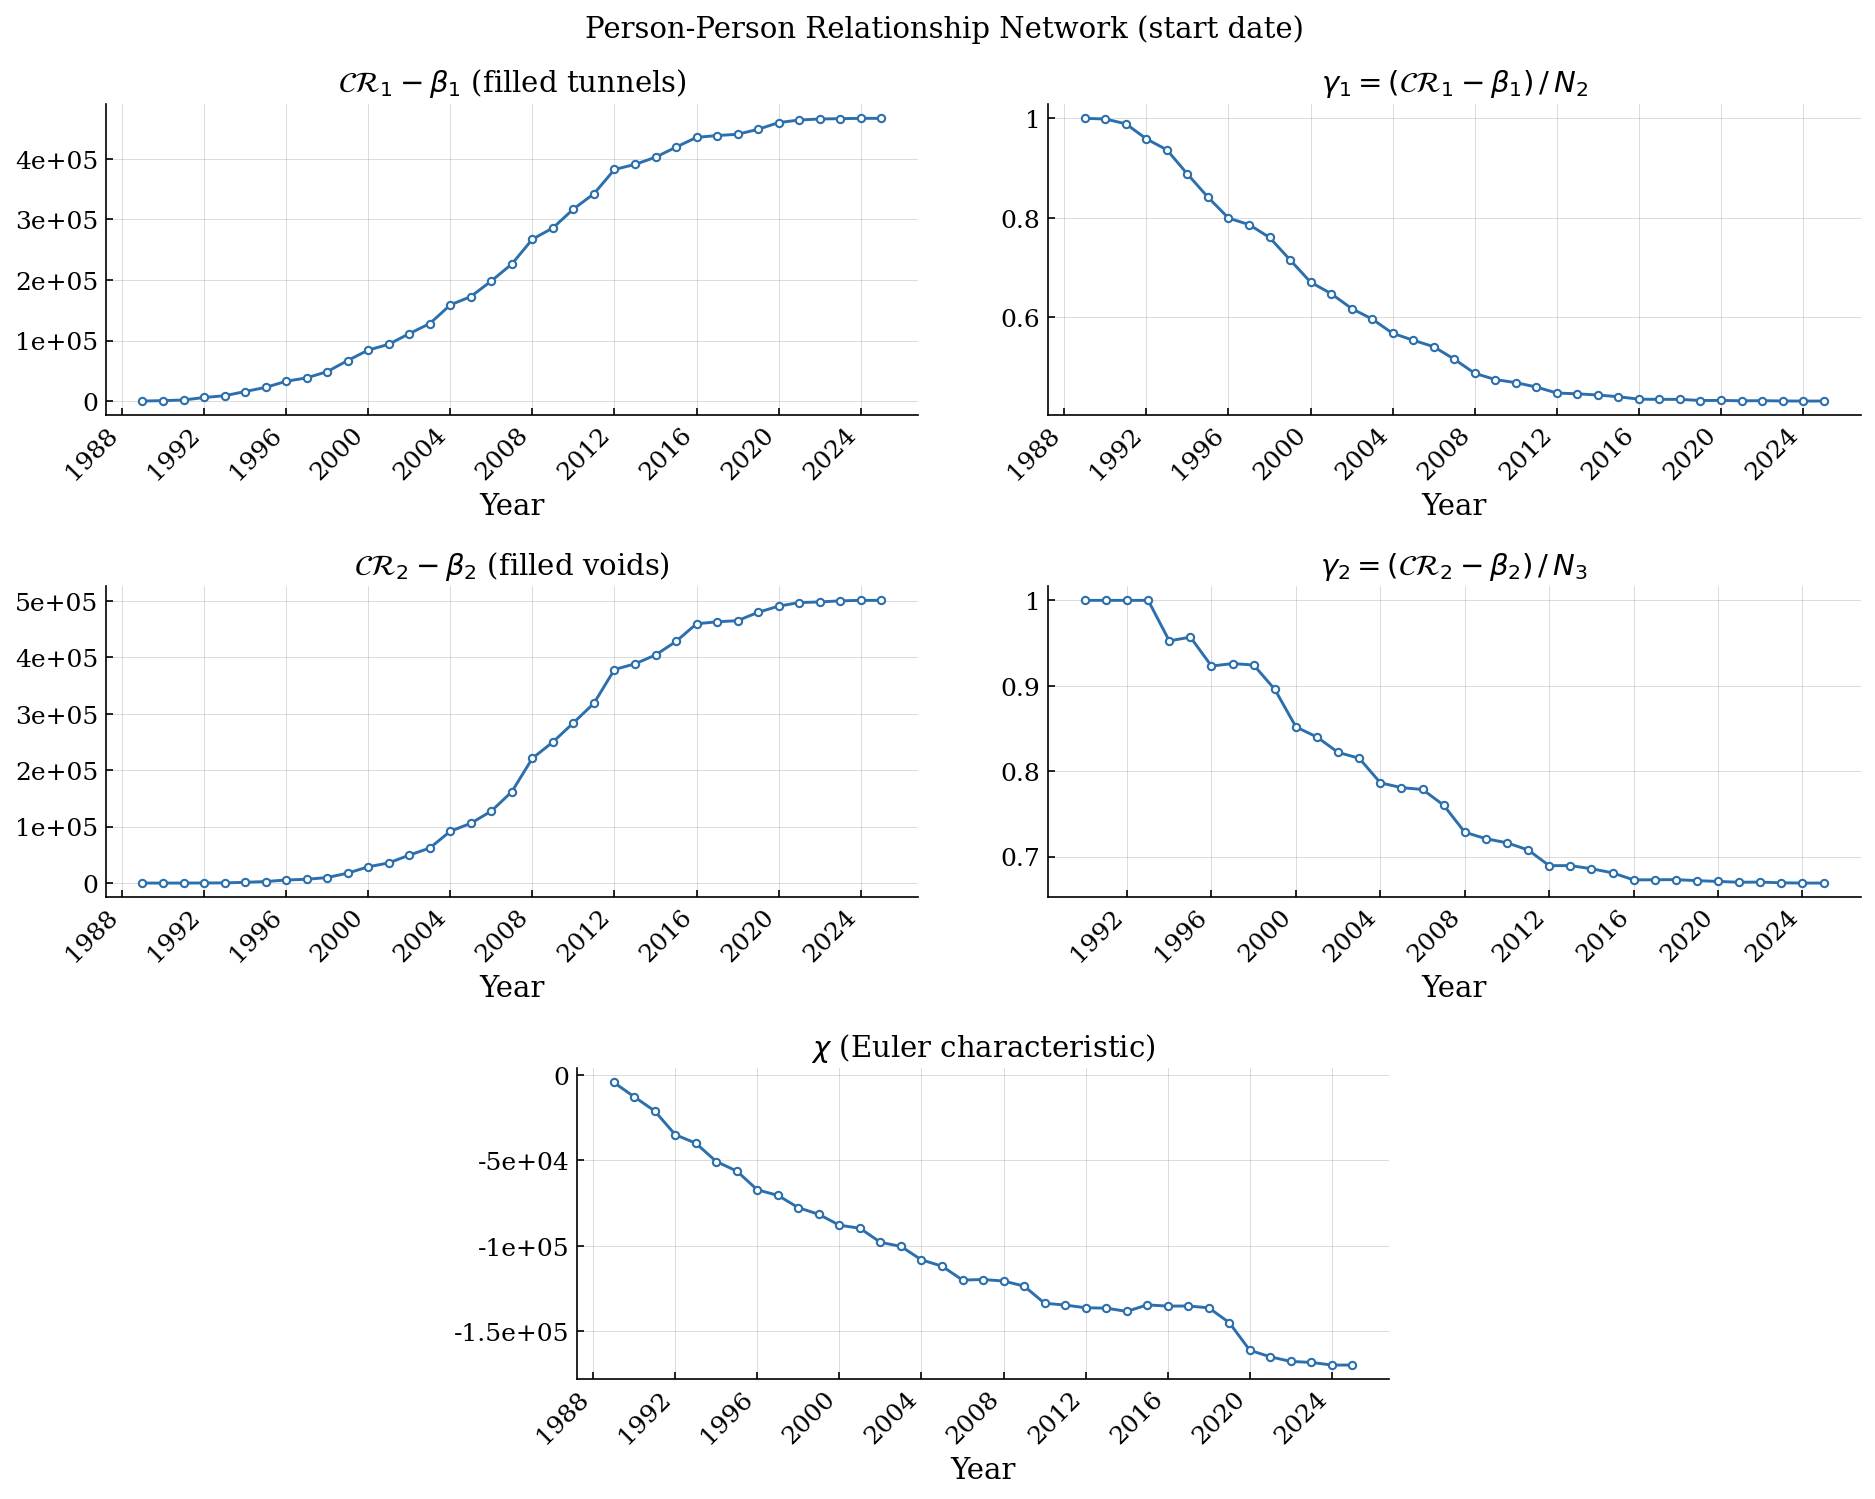

In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2p_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2p, has_start_end_p2p]
    Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start,
                   save_path='ph_yearly.pdf', title='Person-Person Relationship Network (start date)')

In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/all_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_all_start, SimplexCounts_all_start, Euler_all_start, cycleR_all_start, dates_all_start = pickle.load(f)
else:
    rel_dicts = [has_start_o2o, has_start_end_o2o,
                 has_start_p2o, has_start_end_p2o,
                 has_start_p2p, has_start_end_p2p]
    Betti_all_start, SimplexCounts_all_start, Euler_all_start, cycleR_all_start, dates_all_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_all_start, SimplexCounts_all_start, Euler_all_start, cycleR_all_start, dates_all_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_all_start, SimplexCounts_all_start, Euler_all_start, cycleR_all_start, dates_all_start,
                   save_path='ph_yearly.pdf')

In [ ]:
def ZZ_LittleSIS(rel_dicts, timing=False, maxDim=np.inf, random_seed=42):
    """
    Build a zigzag filtration from LittleSIS relationship dicts. Edges are
    added at start_date and removed at end_date (if present and is_current
    is False). Duplicate edges (same undirected pair) are merged if their
    intervals overlap, and kept as separate events if they do not.
    Isolated nodes are removed when their last edge is deleted.

    Parameters
    ----------
    rel_dicts : list of dict
        Relationship dictionaries, e.g. [has_start_p2p, has_start_end_p2p].
    timing : bool
    maxDim : int or np.inf
    random_seed : int

    Returns
    -------
    Betti        : np.ndarray, shape (4, n_steps)
    SimplexCounts: list of lists, one entry per event step
    Euler        : np.ndarray, shape (n_steps,)
    cycleR       : list, length n_steps
    dates        : list of str
    """
    rng = random.Random(random_seed)
    SENTINEL = '9999-99-99'  # Represents open-ended intervals

    # -------------------------------------------------------------------------
    # (1/5) Collect intervals, merge overlapping ones, build event list
    # -------------------------------------------------------------------------
    if timing:
        print("(1/5) Collecting and sorting events", flush=True)
        t0 = time.time()

    # Group all intervals by undirected pair
    pair_intervals = {}
    for rel_dict in rel_dicts:
        for rel in rel_dict.values():
            start = rel.get('start_date')
            if not start:
                continue
            u, v = rel['entity1_id'], rel['entity2_id']
            if u == v:
                continue
            key = (min(u, v), max(u, v))
            # None end means open-ended (is_current=True or no end_date)
            end = (rel.get('end_date')
                   if not rel.get('is_current', False) else None)
            if key not in pair_intervals:
                pair_intervals[key] = []
            pair_intervals[key].append((start, end))

    def merge_intervals(intervals):
        """
        Standard interval merge. Intervals with None end extend to SENTINEL.
        Returns list of (start, end) with None restored for open-ended intervals.
        Non-overlapping intervals are kept as separate entries.
        """
        ivs = sorted(
            [(s, e if e is not None else SENTINEL) for s, e in intervals],
            key=lambda x: x[0]
        )
        merged = []
        cur_s, cur_e = ivs[0]
        for s, e in ivs[1:]:
            if s <= cur_e:
                # Intervals overlap: merge into earlier start, later end
                cur_e = max(cur_e, e)
            else:
                # No overlap: keep as separate interval
                merged.append((cur_s, cur_e))
                cur_s, cur_e = s, e
        merged.append((cur_s, cur_e))
        return [(s, None if e == SENTINEL else e) for s, e in merged]

    # Build event list: (date_str, priority, rand_key, action, u, v)
    # priority 0=add, 1=remove so additions precede removals on same date
    raw_events = []
    for (u, v), intervals in pair_intervals.items():
        for start, end in merge_intervals(intervals):
            raw_events.append((start, 0, rng.random(), 'add', u, v))
            if end is not None:
                raw_events.append((end, 1, rng.random(), 'remove', u, v))

    raw_events.sort(key=lambda x: (x[0], x[1], x[2]))
    n_steps = len(raw_events)
    dates   = [e[0] for e in raw_events]

    if timing:
        n_add = sum(1 for e in raw_events if e[3] == 'add')
        n_rem = n_steps - n_add
        print(f"  {n_add} additions, {n_rem} removals ({n_steps} total). "
              f"Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (2/5) Initialize graph and data structures
    # -------------------------------------------------------------------------
    if timing:
        print("(2/5) Initializing graph and data structures", flush=True)
        t0 = time.time()

    G             = nx.Graph()
    Times         = {}
    SimplexCounts = []
    cycleR        = np.zeros(n_steps)

    if timing:
        print(f"  Done. Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (3/5) Evolve graph event by event
    # -------------------------------------------------------------------------
    if timing:
        print("(3/5) Evolving graph", flush=True)
        t0 = time.time()

    iterator = enumerate(tqdm(raw_events)) if timing else enumerate(raw_events)

    for timer, (date_str, _, __, action, u, v) in iterator:

        current_counts = SimplexCounts[-1].copy() if SimplexCounts else []

        # --- ADDITION --------------------------------------------------------
        if action == 'add':
            new_simplices = set()

            for node in [u, v]:
                if node not in G:
                    G.add_node(node)
                    new_simplices.add((node,))

            common = list(nx.common_neighbors(G, u, v))
            G.add_edge(u, v)
            new_simplices.add(tuple(sorted([u, v])))

            if common and maxDim > 1:
                H = G.subgraph([u, v] + common)
                for clique in nx.find_cliques(H):
                    if u in clique and v in clique:
                        clique_s = sorted(clique)
                        for size in range(3, min(len(clique_s),
                                                  maxDim) + 1):
                            for face in combinations(clique_s, size):
                                if u in face and v in face:
                                    new_simplices.add(face)

            for simplex in new_simplices:
                dim = len(simplex) - 1
                if dim > maxDim:
                    continue
                while len(current_counts) <= dim:
                    current_counts.append(0)
                current_counts[dim] += 1
                if dim <= 3:
                    if simplex in Times:
                        Times[simplex].append(timer)
                    else:
                        Times[simplex] = [timer]

        # --- REMOVAL ---------------------------------------------------------
        else:
            if not G.has_edge(u, v):
                SimplexCounts.append(current_counts)
                cycleR[timer] = (G.number_of_edges() - G.number_of_nodes()
                                 if G.number_of_nodes() > 0 else 0)
                continue

            # Collect all simplices containing (u,v) before removing edge
            rem_simplices = set([tuple(sorted([u, v]))])
            for clique in nx.find_cliques(G, sorted([u, v])):
                remainder = [node for node in clique
                             if node != u and node != v]
                for r in range(1, min(len(remainder),
                                      maxDim - 1) + 1):
                    for face in combinations(remainder, r):
                        rem_simplices.add(tuple(sorted(face + (u, v))))

            G.remove_edge(u, v)

            # Remove isolated nodes
            for node in [u, v]:
                if node in G and G.degree(node) == 0:
                    G.remove_node(node)
                    iso = (node,)
                    rem_simplices.add(iso)

            for simplex in rem_simplices:
                dim = len(simplex) - 1
                if dim > maxDim:
                    continue
                if dim < len(current_counts):
                    current_counts[dim] -= 1
                if dim <= 3 and simplex in Times:
                    Times[simplex].append(timer)

        SimplexCounts.append(current_counts)
        cycleR[timer] = (G.number_of_edges() - G.number_of_nodes()
                         if G.number_of_nodes() > 0 else 0)

    if timing:
        print(f"  Evolution complete. Time: {time.time()-t0:.2f}s", flush=True)

    # Close all simplices still open at the final step
    for tlist in Times.values():
        if len(tlist) % 2 == 1:
            tlist.append(n_steps)

    # -------------------------------------------------------------------------
    # (4/5) Zigzag Persistent Homology
    # -------------------------------------------------------------------------
    if timing:
        print("(4/5) Computing Zigzag Persistent Homology", flush=True)
        t0 = time.time()

    simplices = [list(k) for k in Times]
    times     = [Times[k] for k in Times]
    del Times; gc.collect()

    f = d.Filtration(simplices)
    zz, dgms, cells = d.zigzag_homology_persistence(f, times)
    del simplices; del times; gc.collect()

    if timing:
        print(f"  ZZ PH complete. Time: {time.time()-t0:.2f}s", flush=True)

    # -------------------------------------------------------------------------
    # (5/5) Betti numbers and Euler characteristic
    # -------------------------------------------------------------------------
    if timing:
        print("(5/5) Extracting Betti numbers and Euler characteristic",
              flush=True)
        t0 = time.time()

    Betti = np.zeros((4, n_steps))
    for i, dgm in enumerate(dgms):
        if i >= 4:
            break
        for p in dgm:
            birth = int(p.birth)
            death = int(min(p.death, n_steps))
            Betti[i][birth:death] += 1

    Euler = np.zeros(n_steps)
    for i, counts in enumerate(SimplexCounts):
        for j, c in enumerate(counts):
            Euler[i] += (-1)**j * c

    cycleR = [cycleR[i] + Betti[0][i] for i in range(n_steps)]

    if timing:
        print(f"  Done. Time: {time.time()-t0:.2f}s", flush=True)

    return Betti, SimplexCounts, Euler, cycleR, dates

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

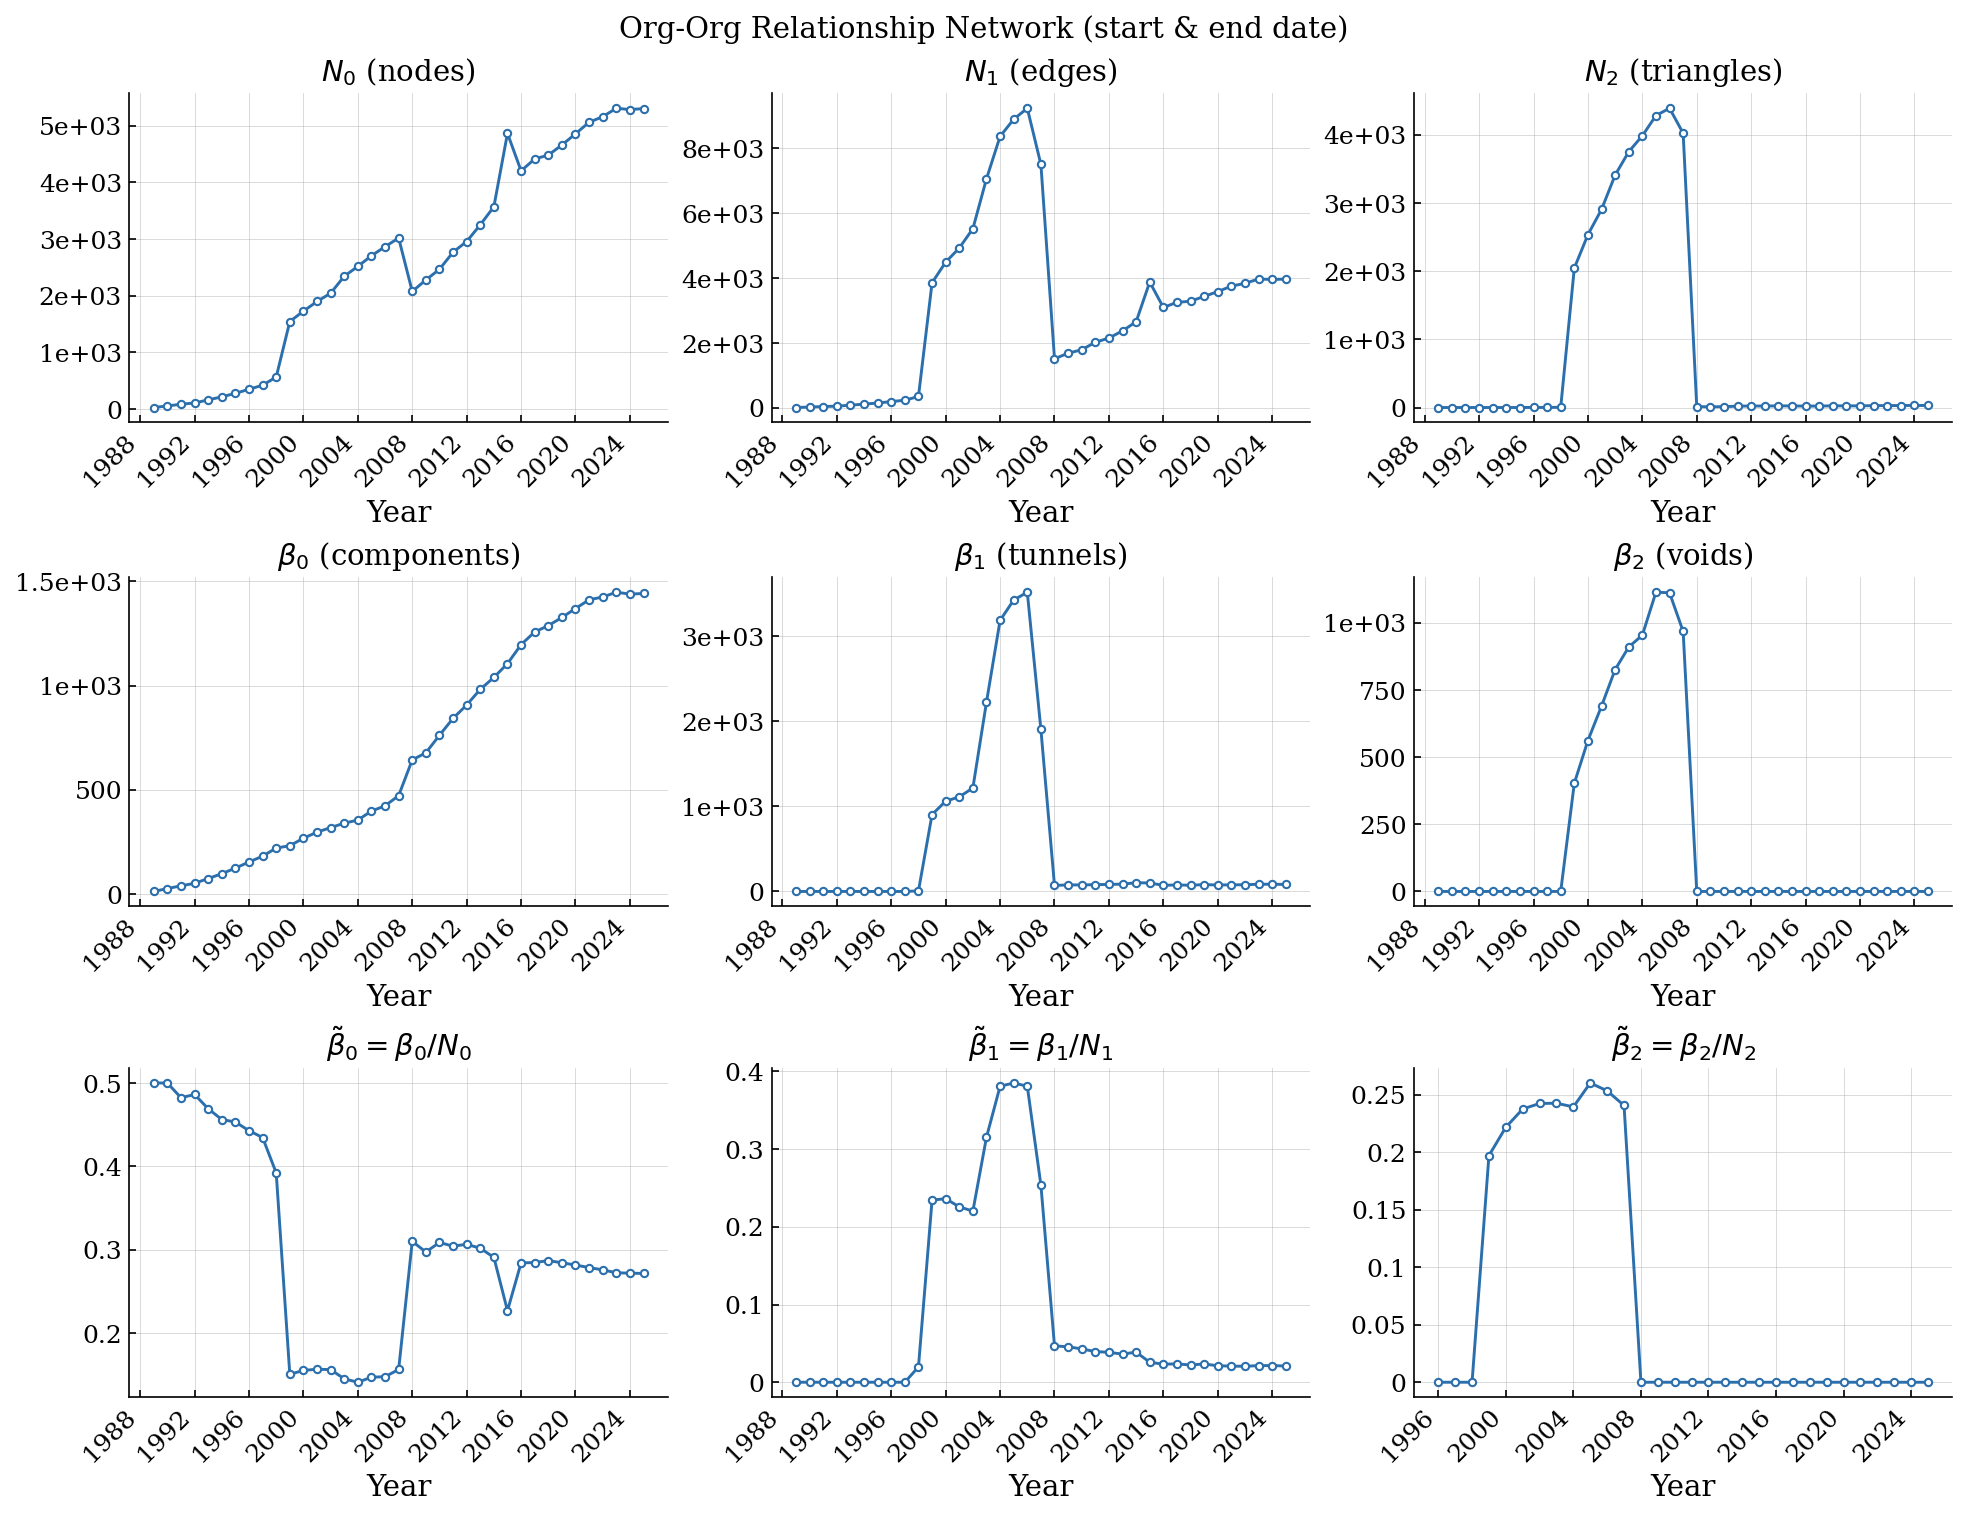

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

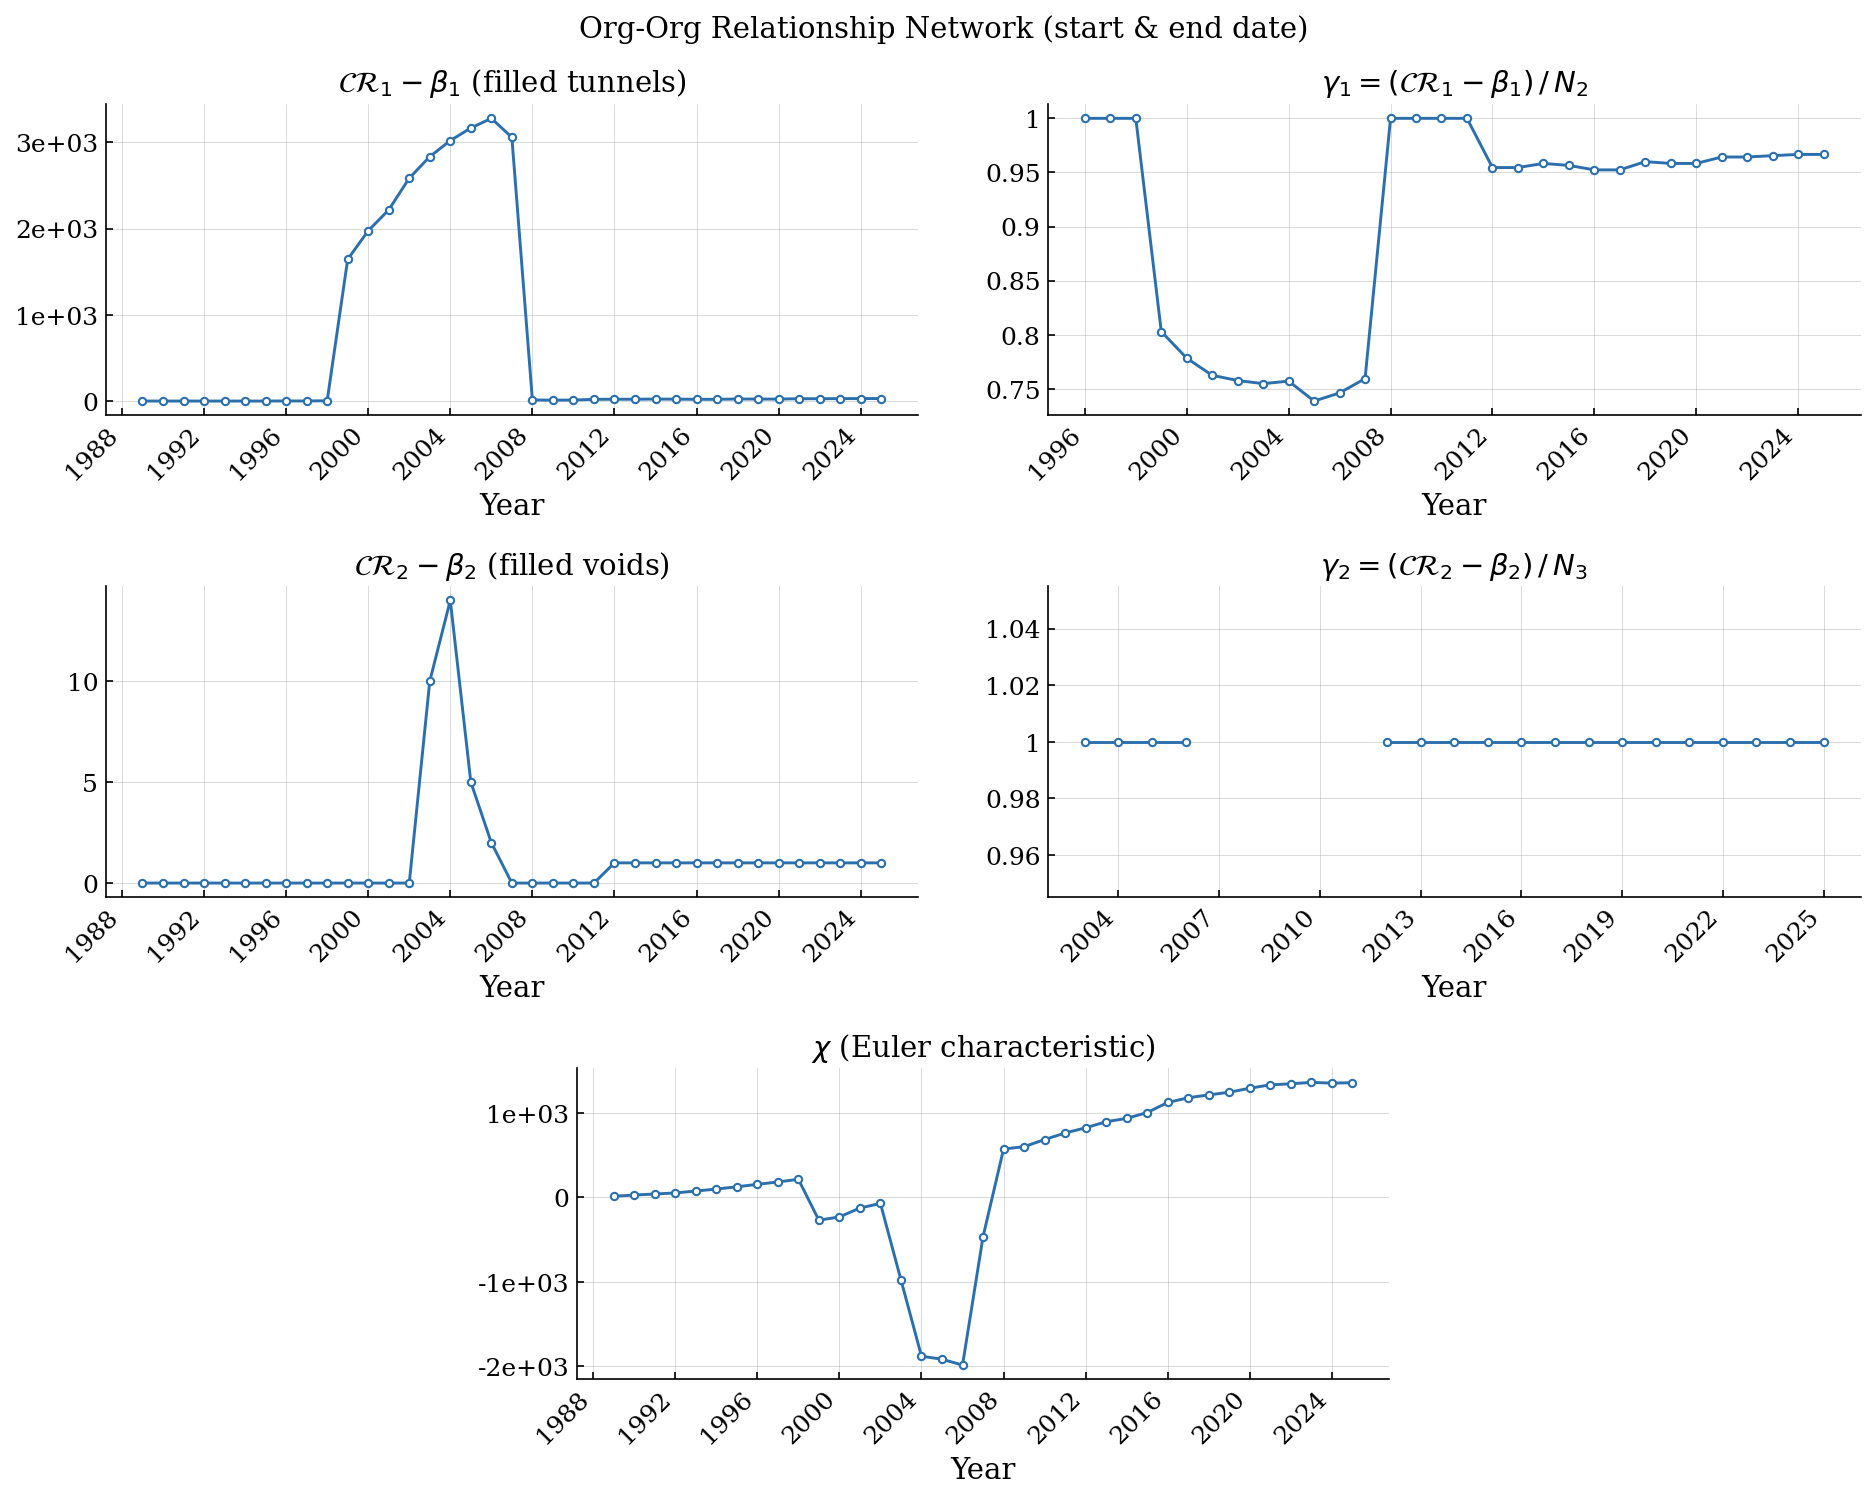

In [ ]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/o2o_start_end_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end = pickle.load(f)
else:
    rel_dicts = [has_start_end_o2o]
    Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end = ZZ_LittleSIS(rel_dicts, timing=True, maxDim=np.inf, random_seed=42)
    data = [Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end,
                   save_path='ph_yearly.pdf',title='Org-Org Relationship Network (start & end date)')

O-O relationships with start_date 2000-2005: 11543


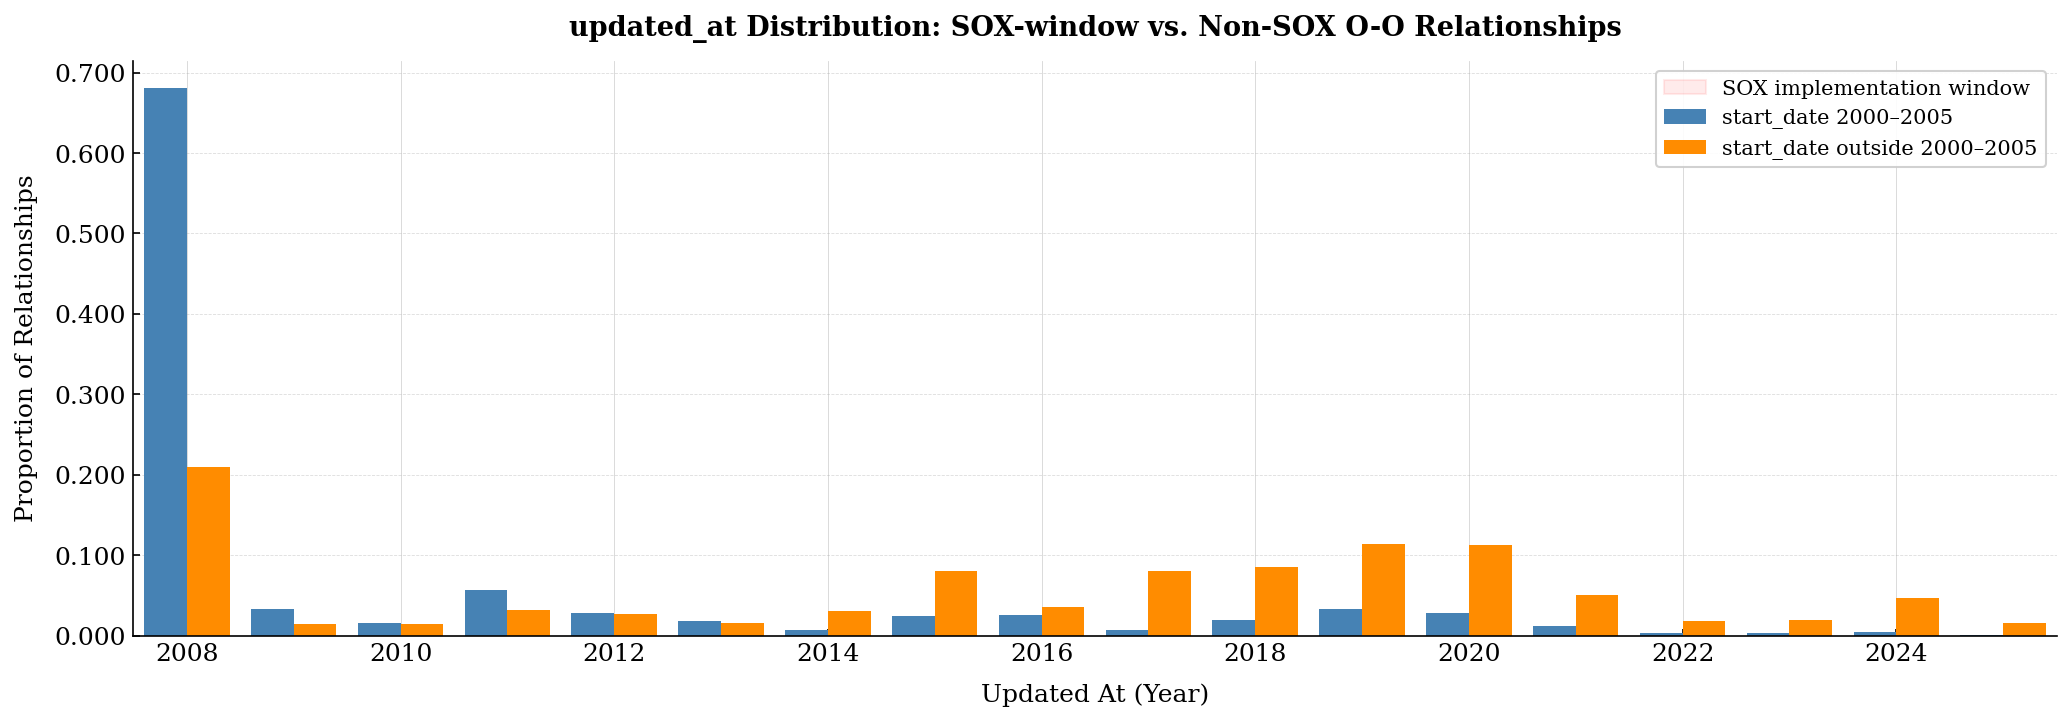

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


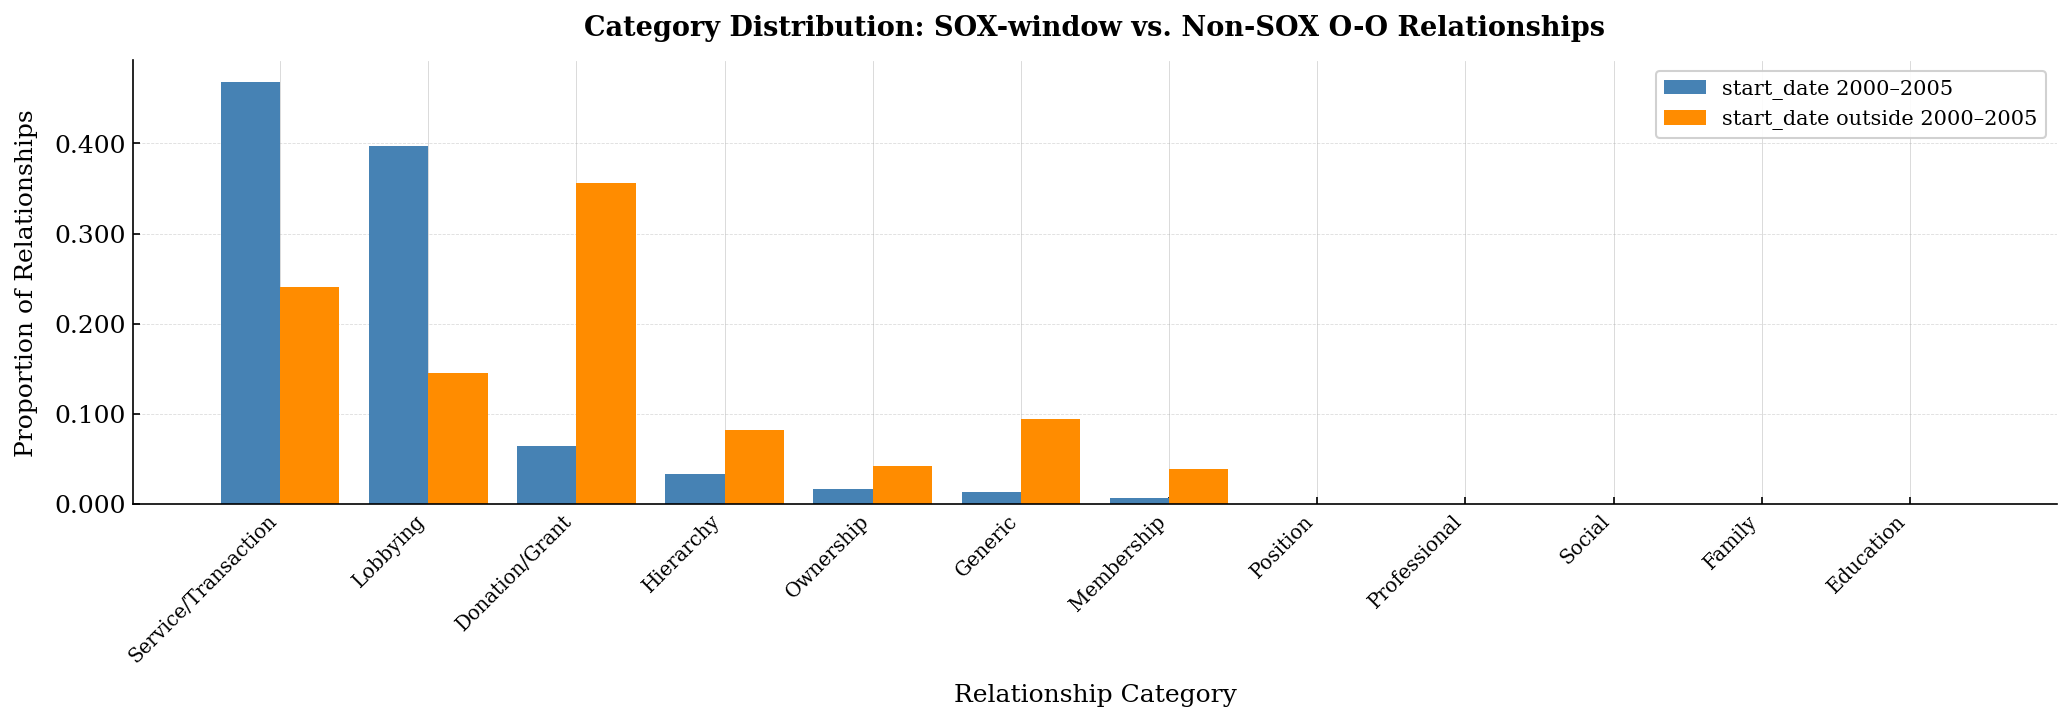


--- Category breakdown (SOX-window, start_date 2000-2005) ---
  Service/Transaction           :   5409  (46.9%)
  Lobbying                      :   4583  (39.7%)
  Donation/Grant                :    744  (6.4%)
  Hierarchy                     :    384  (3.3%)
  Ownership                     :    196  (1.7%)
  Generic                       :    148  (1.3%)
  Membership                    :     76  (0.7%)
  Position                      :      3  (0.0%)
  Professional                  :      0  (0.0%)
  Social                        :      0  (0.0%)
  Family                        :      0  (0.0%)
  Education                     :      0  (0.0%)

--- Category breakdown (Non-SOX-window) ---
  Donation/Grant                :  12939  (35.6%)
  Service/Transaction           :   8745  (24.1%)
  Lobbying                      :   5274  (14.5%)
  Generic                       :   3434  (9.5%)
  Hierarchy                     :   2987  (8.2%)
  Ownership                     :   1514  (4.2%)
  Mem

In [ ]:
# =============================================================================
# SOX Hypothesis Test: O-O relationships with start_date in 2000-2005
# =============================================================================

# --- Extract relevant relationships ---
sox_window_oo = {
    r: org_to_org[r] for r in org_to_org
    if org_to_org[r]['start_date'] is not None
    and 2000 <= int(org_to_org[r]['start_date'][:4]) <= 2005
}
print(f"O-O relationships with start_date 2000-2005: {len(sox_window_oo)}")

# --- (1) updated_at distribution ---
update_years_sox = [
    int(sox_window_oo[r]['updated_at'][:4])
    for r in sox_window_oo
    if sox_window_oo[r]['updated_at'] is not None
]

# For comparison: updated_at distribution for O-O relationships
# with start_date OUTSIDE 2000-2005
non_sox_oo = {
    r: org_to_org[r] for r in org_to_org
    if org_to_org[r]['start_date'] is not None
    and not (2000 <= int(org_to_org[r]['start_date'][:4]) <= 2005)
}
update_years_non_sox = [
    int(non_sox_oo[r]['updated_at'][:4])
    for r in non_sox_oo
    if non_sox_oo[r]['updated_at'] is not None
]

yr_min = min(update_years_sox + update_years_non_sox)
yr_max = max(update_years_sox + update_years_non_sox)
bins_u = range(yr_min, yr_max + 2)
bin_years_u = np.array(list(bins_u[:-1]))

counts_sox     = year_counts(update_years_sox,     bins_u)
counts_non_sox = year_counts(update_years_non_sox, bins_u)

# Normalize to proportions for fair comparison
prop_sox     = counts_sox     / counts_sox.sum()
prop_non_sox = counts_non_sox / counts_non_sox.sum()

fig, ax = plt.subplots(figsize=(14, 5))
width = 0.4
ax.bar(bin_years_u - width/2, prop_sox,     width=width,
       color='steelblue', edgecolor='none',
       label='start_date 2000–2005')
ax.bar(bin_years_u + width/2, prop_non_sox, width=width,
       color='darkorange', edgecolor='none',
       label='start_date outside 2000–2005')
ax.axvspan(2002.5, 2006.5, alpha=0.08, color='red',
           label='SOX implementation window')
ax.set_xlabel('Updated At (Year)', fontsize=12, labelpad=8)
ax.set_ylabel('Proportion of Relationships', fontsize=12, labelpad=8)
ax.set_title('updated_at Distribution: SOX-window vs. Non-SOX O-O Relationships',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(yr_min - 0.5, yr_max + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('sox_updated_at.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- (2) category_id distribution ---
# Count category_ids for SOX-window relationships
counts_cat_sox     = np.zeros(12)
counts_cat_non_sox = np.zeros(12)

for r in sox_window_oo:
    cid = sox_window_oo[r]['category_id']
    if 1 <= cid <= 12:
        counts_cat_sox[cid - 1] += 1

for r in non_sox_oo:
    cid = non_sox_oo[r]['category_id']
    if 1 <= cid <= 12:
        counts_cat_non_sox[cid - 1] += 1

# Normalize to proportions
prop_cat_sox     = counts_cat_sox     / counts_cat_sox.sum()
prop_cat_non_sox = counts_cat_non_sox / counts_cat_non_sox.sum()

# Sort by SOX-window proportion descending
sort_idx_cat = np.argsort(prop_cat_sox)[::-1]
sorted_labels_cat     = [Rel_types_all[i] for i in sort_idx_cat]
sorted_prop_sox       = prop_cat_sox[sort_idx_cat]
sorted_prop_non_sox   = prop_cat_non_sox[sort_idx_cat]

x_cat = np.arange(12)
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_cat - width/2, sorted_prop_sox,     width=width,
       color='steelblue', edgecolor='none',
       label='start_date 2000–2005')
ax.bar(x_cat + width/2, sorted_prop_non_sox, width=width,
       color='darkorange', edgecolor='none',
       label='start_date outside 2000–2005')
ax.set_xticks(x_cat)
ax.set_xticklabels(sorted_labels_cat, rotation=45, ha='right', fontsize=9.5)
ax.set_xlabel('Relationship Category', fontsize=12, labelpad=8)
ax.set_ylabel('Proportion of Relationships', fontsize=12, labelpad=8)
ax.set_title('Category Distribution: SOX-window vs. Non-SOX O-O Relationships',
             fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('sox_category.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- (3) Print summary statistics ---
print("\n--- Category breakdown (SOX-window, start_date 2000-2005) ---")
for i in sort_idx_cat:
    n   = int(counts_cat_sox[i])
    pct = 100 * prop_cat_sox[i]
    print(f"  {Rel_types_all[i]:<30s}: {n:>6d}  ({pct:.1f}%)")

print("\n--- Category breakdown (Non-SOX-window) ---")
non_sox_sort = np.argsort(prop_cat_non_sox)[::-1]
for i in non_sox_sort:
    n   = int(counts_cat_non_sox[i])
    pct = 100 * prop_cat_non_sox[i]
    print(f"  {Rel_types_all[i]:<30s}: {n:>6d}  ({pct:.1f}%)")

# --- (4) Chi-squared test for distributional difference ---
from scipy.stats import chi2_contingency

contingency = np.vstack([counts_cat_sox, counts_cat_non_sox])
# Drop categories where BOTH groups have zero counts
nonzero_cols = contingency.sum(axis=0) > 0
contingency_filtered = contingency[:, nonzero_cols]

chi2, p, dof, expected = chi2_contingency(contingency_filtered)
print(f"\nChi-squared test (category distributions, excluding empty categories):")
print(f"  chi2 = {chi2:.2f}, dof = {dof}, p = {p:.2e}")
print(f"  {'Distributions are significantly different (p < 0.05)' if p < 0.05 else 'No significant difference detected'}")

In [ ]:
bulk_import_o2o = {
    r: has_start_end_o2o[r] for r in has_start_end_o2o
    if has_start_end_o2o[r]['updated_at'] is not None
    and int(has_start_end_o2o[r]['updated_at'][:4]) == 2008
    #and int(has_start_end_o2o[r]['start_date'][:4]) <= 2005
}

non_bulk_o2o = {
    r: has_start_end_o2o[r] for r in has_start_end_o2o
    if r not in bulk_import_o2o
}

print(f"has_start_end_o2o total:   {len(has_start_end_o2o)}")
print(f"Bulk import cohort:        {len(bulk_import_o2o)} "
      f"({100*len(bulk_import_o2o)/len(has_start_end_o2o):.1f}%)")
print(f"Non-bulk cohort:           {len(non_bulk_o2o)} "
      f"({100*len(non_bulk_o2o)/len(has_start_end_o2o):.1f}%)")

has_start_end_o2o total:   22488
Bulk import cohort:        11042 (49.1%)
Non-bulk cohort:           11446 (50.9%)


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

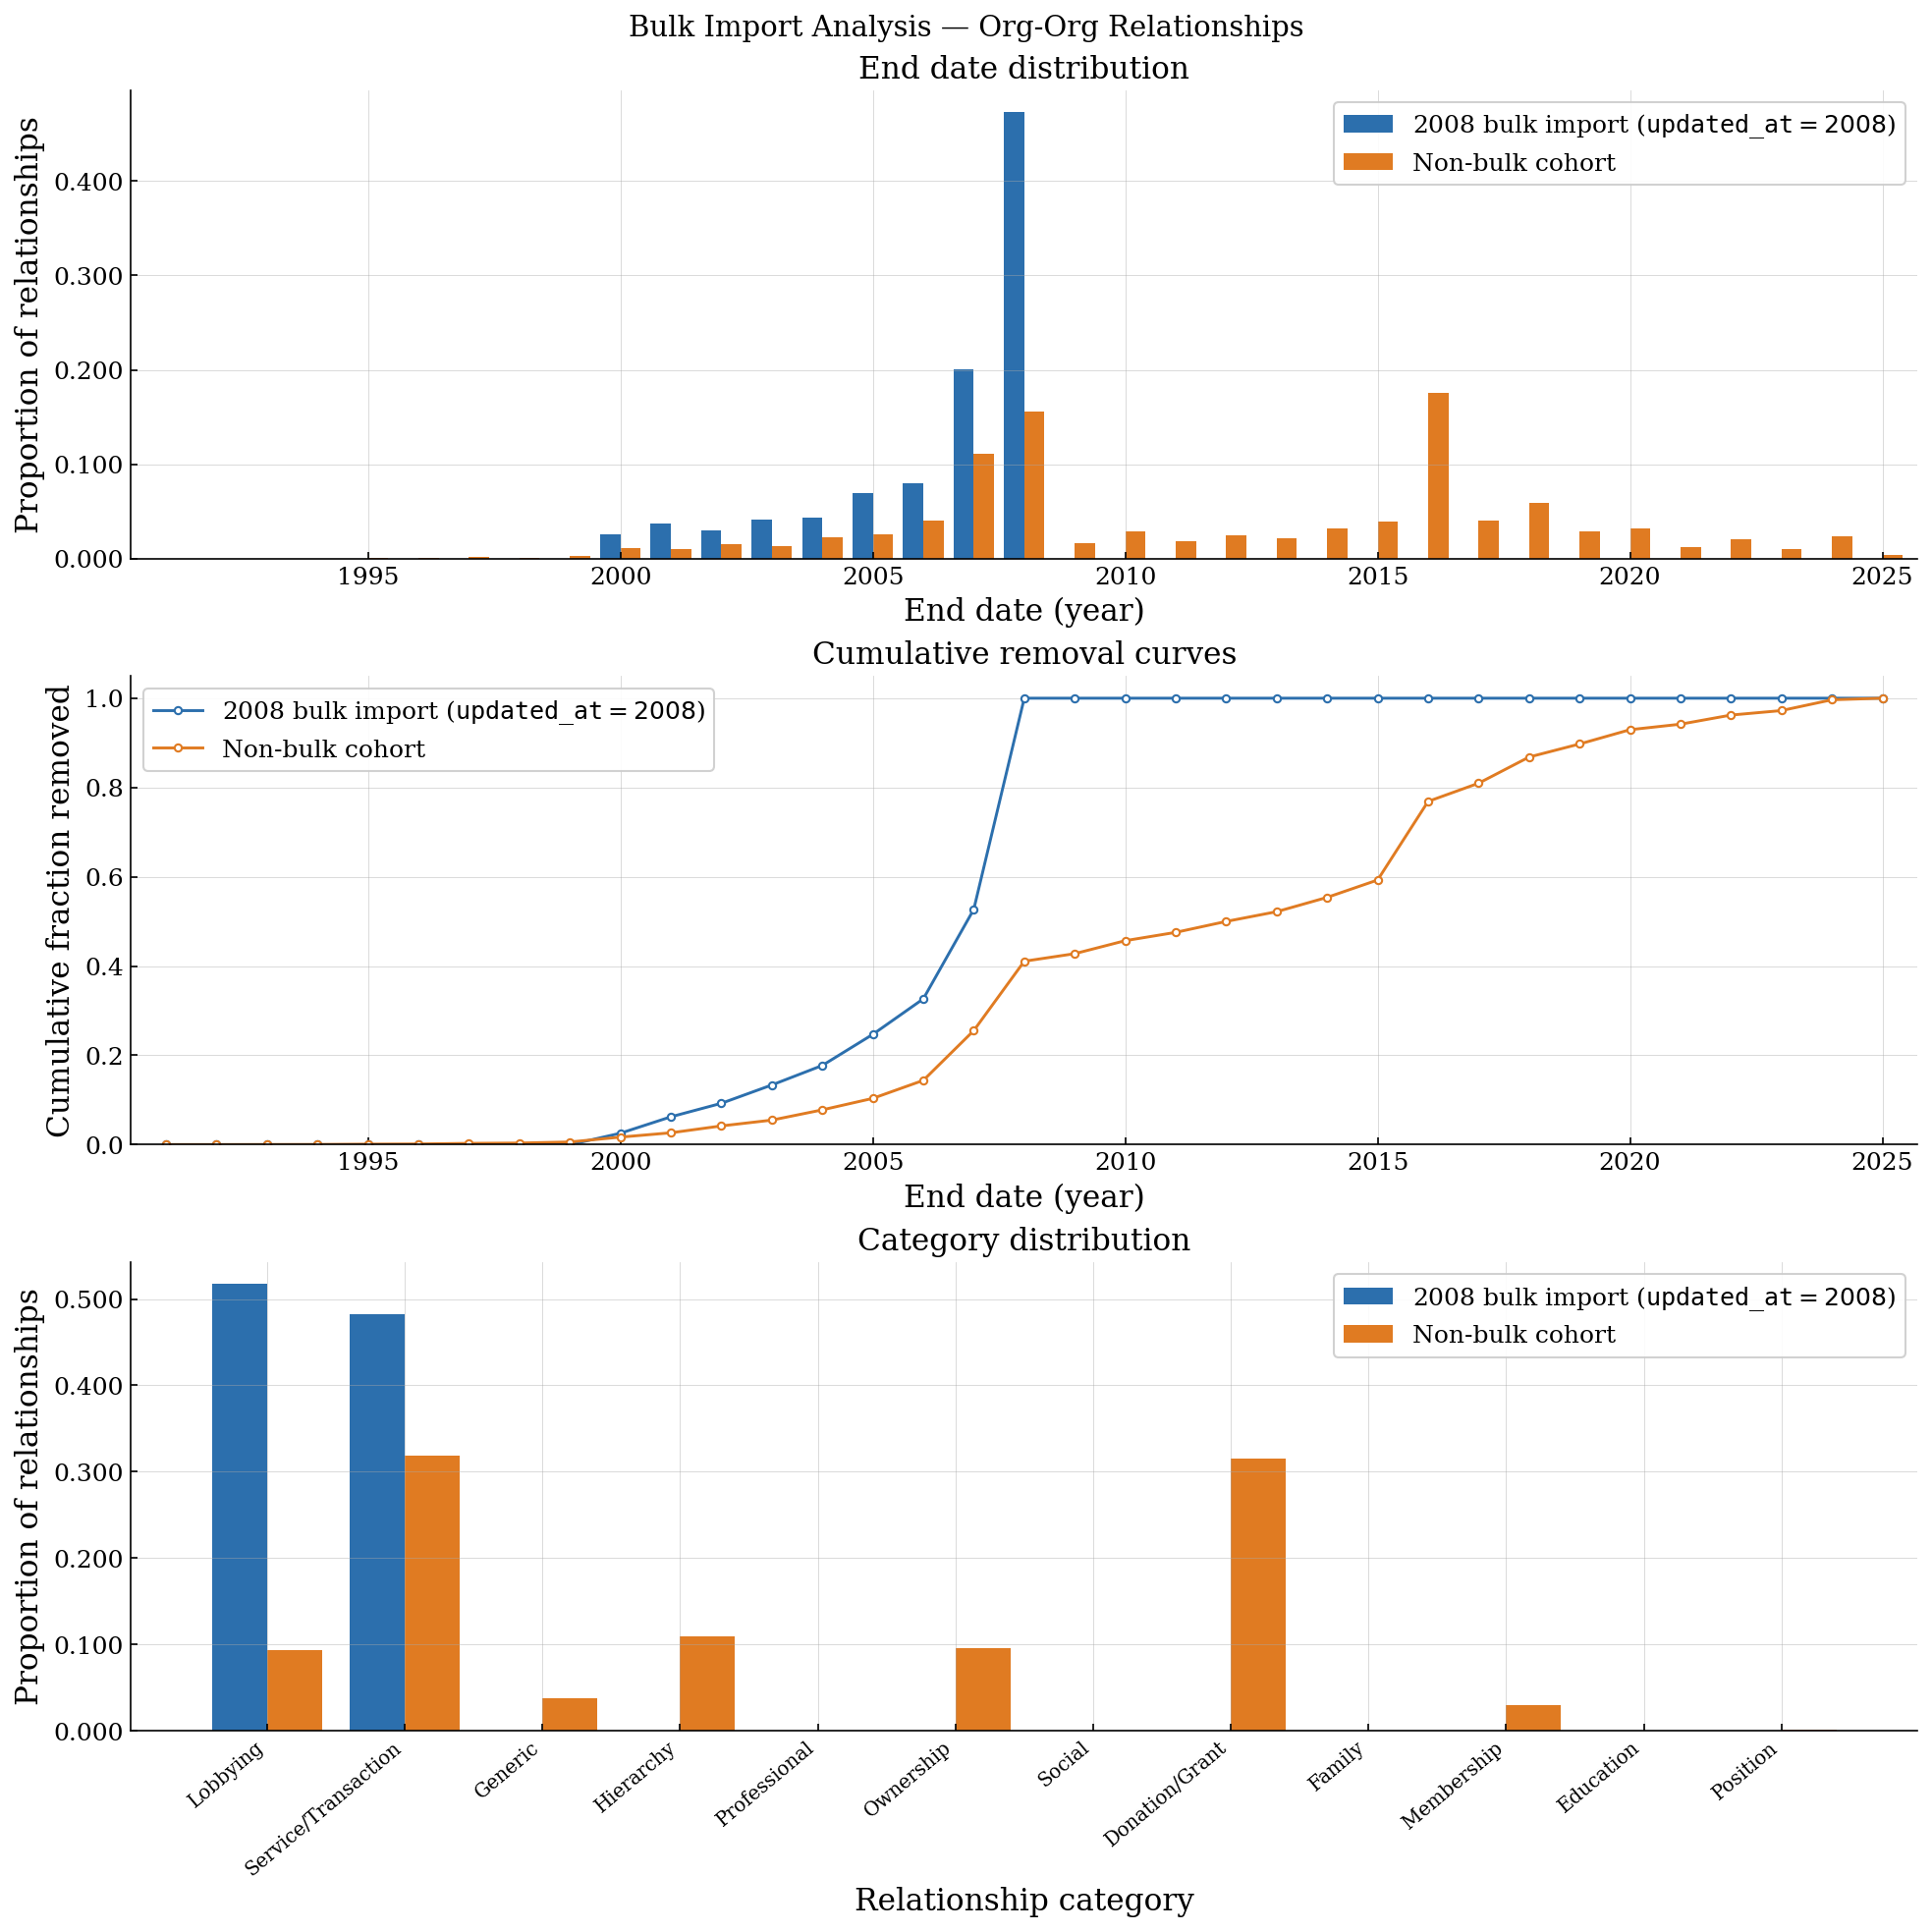

Saved: fig_bulk_import_analysis


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         14,
    'axes.labelsize':    15,
    'axes.titlesize':    15,
    'legend.fontsize':   12,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

BULK_COLOR    = '#2c6fad'
NONBULK_COLOR = '#e07b22'
BULK_LABEL    = '2008 bulk import ($\\mathtt{updated\\_at}=2008$)'
NONBULK_LABEL = 'Non-bulk cohort'

save_path = '/content/drive/My Drive/Colab Notebooks/LittleSIS/'

# ── helpers ───────────────────────────────────────────────────────────────────

def year_counts(years, bins):
    counts = np.zeros(len(bins) - 1, dtype=float)
    for yr in years:
        for i in range(len(bins) - 1):
            if bins[i] <= yr < bins[i + 1]:
                counts[i] += 1
                break
    return counts

def line_kw(color):
    return dict(color=color, lw=1.4, marker='o', markersize=3.5,
                markerfacecolor='white', markeredgecolor=color,
                markeredgewidth=1.0)

# ── data preparation ──────────────────────────────────────────────────────────

end_years_bulk     = [int(bulk_import_o2o[r]['end_date'][:4])
                      for r in bulk_import_o2o
                      if bulk_import_o2o[r]['end_date'] is not None]
end_years_non_bulk = [int(non_bulk_o2o[r]['end_date'][:4])
                      for r in non_bulk_o2o
                      if non_bulk_o2o[r]['end_date'] is not None]

yr_min   = min(end_years_bulk + end_years_non_bulk)
yr_max   = max(end_years_bulk + end_years_non_bulk)
bins_e   = range(yr_min, yr_max + 2)
bin_years = np.array(list(bins_e)[:-1])

counts_bulk     = year_counts(end_years_bulk,     bins_e)
counts_non_bulk = year_counts(end_years_non_bulk, bins_e)

prop_bulk     = counts_bulk     / counts_bulk.sum()
prop_non_bulk = counts_non_bulk / counts_non_bulk.sum()

cum_bulk     = np.cumsum(counts_bulk)     / len(end_years_bulk)
cum_non_bulk = np.cumsum(counts_non_bulk) / len(end_years_non_bulk)

# category counts
counts_cat_bulk     = np.zeros(12)
counts_cat_non_bulk = np.zeros(12)
for r in bulk_import_o2o:
    cid = bulk_import_o2o[r]['category_id']
    if 1 <= cid <= 12:
        counts_cat_bulk[cid - 1] += 1
for r in non_bulk_o2o:
    cid = non_bulk_o2o[r]['category_id']
    if 1 <= cid <= 12:
        counts_cat_non_bulk[cid - 1] += 1

prop_cat_bulk     = counts_cat_bulk     / counts_cat_bulk.sum()
prop_cat_non_bulk = counts_cat_non_bulk / counts_cat_non_bulk.sum()
sort_idx          = np.argsort(prop_cat_bulk)[::-1]

# ── figure ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 13), constrained_layout=True)
fig.suptitle('Bulk Import Analysis — Org-Org Relationships', fontsize=14)

# ── row 1: end date distribution (bar) ───────────────────────────────────────

ax = axes[0]
w  = 0.4
ax.bar(bin_years - w/2, prop_bulk,     width=w, color=BULK_COLOR,
       edgecolor='none', label=BULK_LABEL)
ax.bar(bin_years + w/2, prop_non_bulk, width=w, color=NONBULK_COLOR,
       edgecolor='none', label=NONBULK_LABEL)
ax.set_xlabel('End date (year)')
ax.set_ylabel('Proportion of relationships')
ax.set_title('End date distribution', pad=6)
ax.set_xlim(yr_min - 0.7, yr_max + 0.7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.3f}'))
ax.legend(loc='upper right', framealpha=0.9)

# ── row 2: cumulative removal curves ─────────────────────────────────────────

ax = axes[1]
ax.plot(bin_years, cum_bulk,     label=BULK_LABEL,    **line_kw(BULK_COLOR))
ax.plot(bin_years, cum_non_bulk, label=NONBULK_LABEL, **line_kw(NONBULK_COLOR))
ax.set_xlabel('End date (year)')
ax.set_ylabel('Cumulative fraction removed')
ax.set_title('Cumulative removal curves', pad=6)
ax.set_xlim(yr_min - 0.7, yr_max + 0.7)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', framealpha=0.9)

# ── row 3: category distribution (bar) ───────────────────────────────────────

ax  = axes[2]
x   = np.arange(12)
ax.bar(x - w/2, prop_cat_bulk[sort_idx],     width=w, color=BULK_COLOR,
       edgecolor='none', label=BULK_LABEL)
ax.bar(x + w/2, prop_cat_non_bulk[sort_idx], width=w, color=NONBULK_COLOR,
       edgecolor='none', label=NONBULK_LABEL)
ax.set_xticks(x)
ax.set_xticklabels([Rel_types_all[i] for i in sort_idx],
                   rotation=40, ha='right', fontsize=9.5)
ax.set_xlabel('Relationship category')
ax.set_ylabel('Proportion of relationships')
ax.set_title('Category distribution', pad=6)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.3f}'))
ax.legend(loc='upper right', framealpha=0.9)

fig.savefig(save_path + 'fig_bulk_import_analysis.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(save_path + 'fig_bulk_import_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_bulk_import_analysis')

Running ZZ pipeline on bulk import cohort...
(1/5) Collecting and sorting events
  10918 additions, 10918 removals (21836 total). Time: 0.07s
(2/5) Initializing graph and data structures
  Done. Time: 0.00s
(3/5) Evolving graph


  0%|          | 0/21836 [00:00<?, ?it/s]

  Evolution complete. Time: 21.76s
(4/5) Computing Zigzag Persistent Homology
  ZZ PH complete. Time: 7.97s
(5/5) Extracting Betti numbers and Euler characteristic
  Done. Time: 0.07s
Running ZZ pipeline on non-bulk cohort...
(1/5) Collecting and sorting events
  10527 additions, 6554 removals (17081 total). Time: 0.07s
(2/5) Initializing graph and data structures
  Done. Time: 0.00s
(3/5) Evolving graph


  0%|          | 0/17081 [00:00<?, ?it/s]

  Evolution complete. Time: 42.59s
(4/5) Computing Zigzag Persistent Homology
  ZZ PH complete. Time: 7.49s
(5/5) Extracting Betti numbers and Euler characteristic
  Done. Time: 0.04s


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

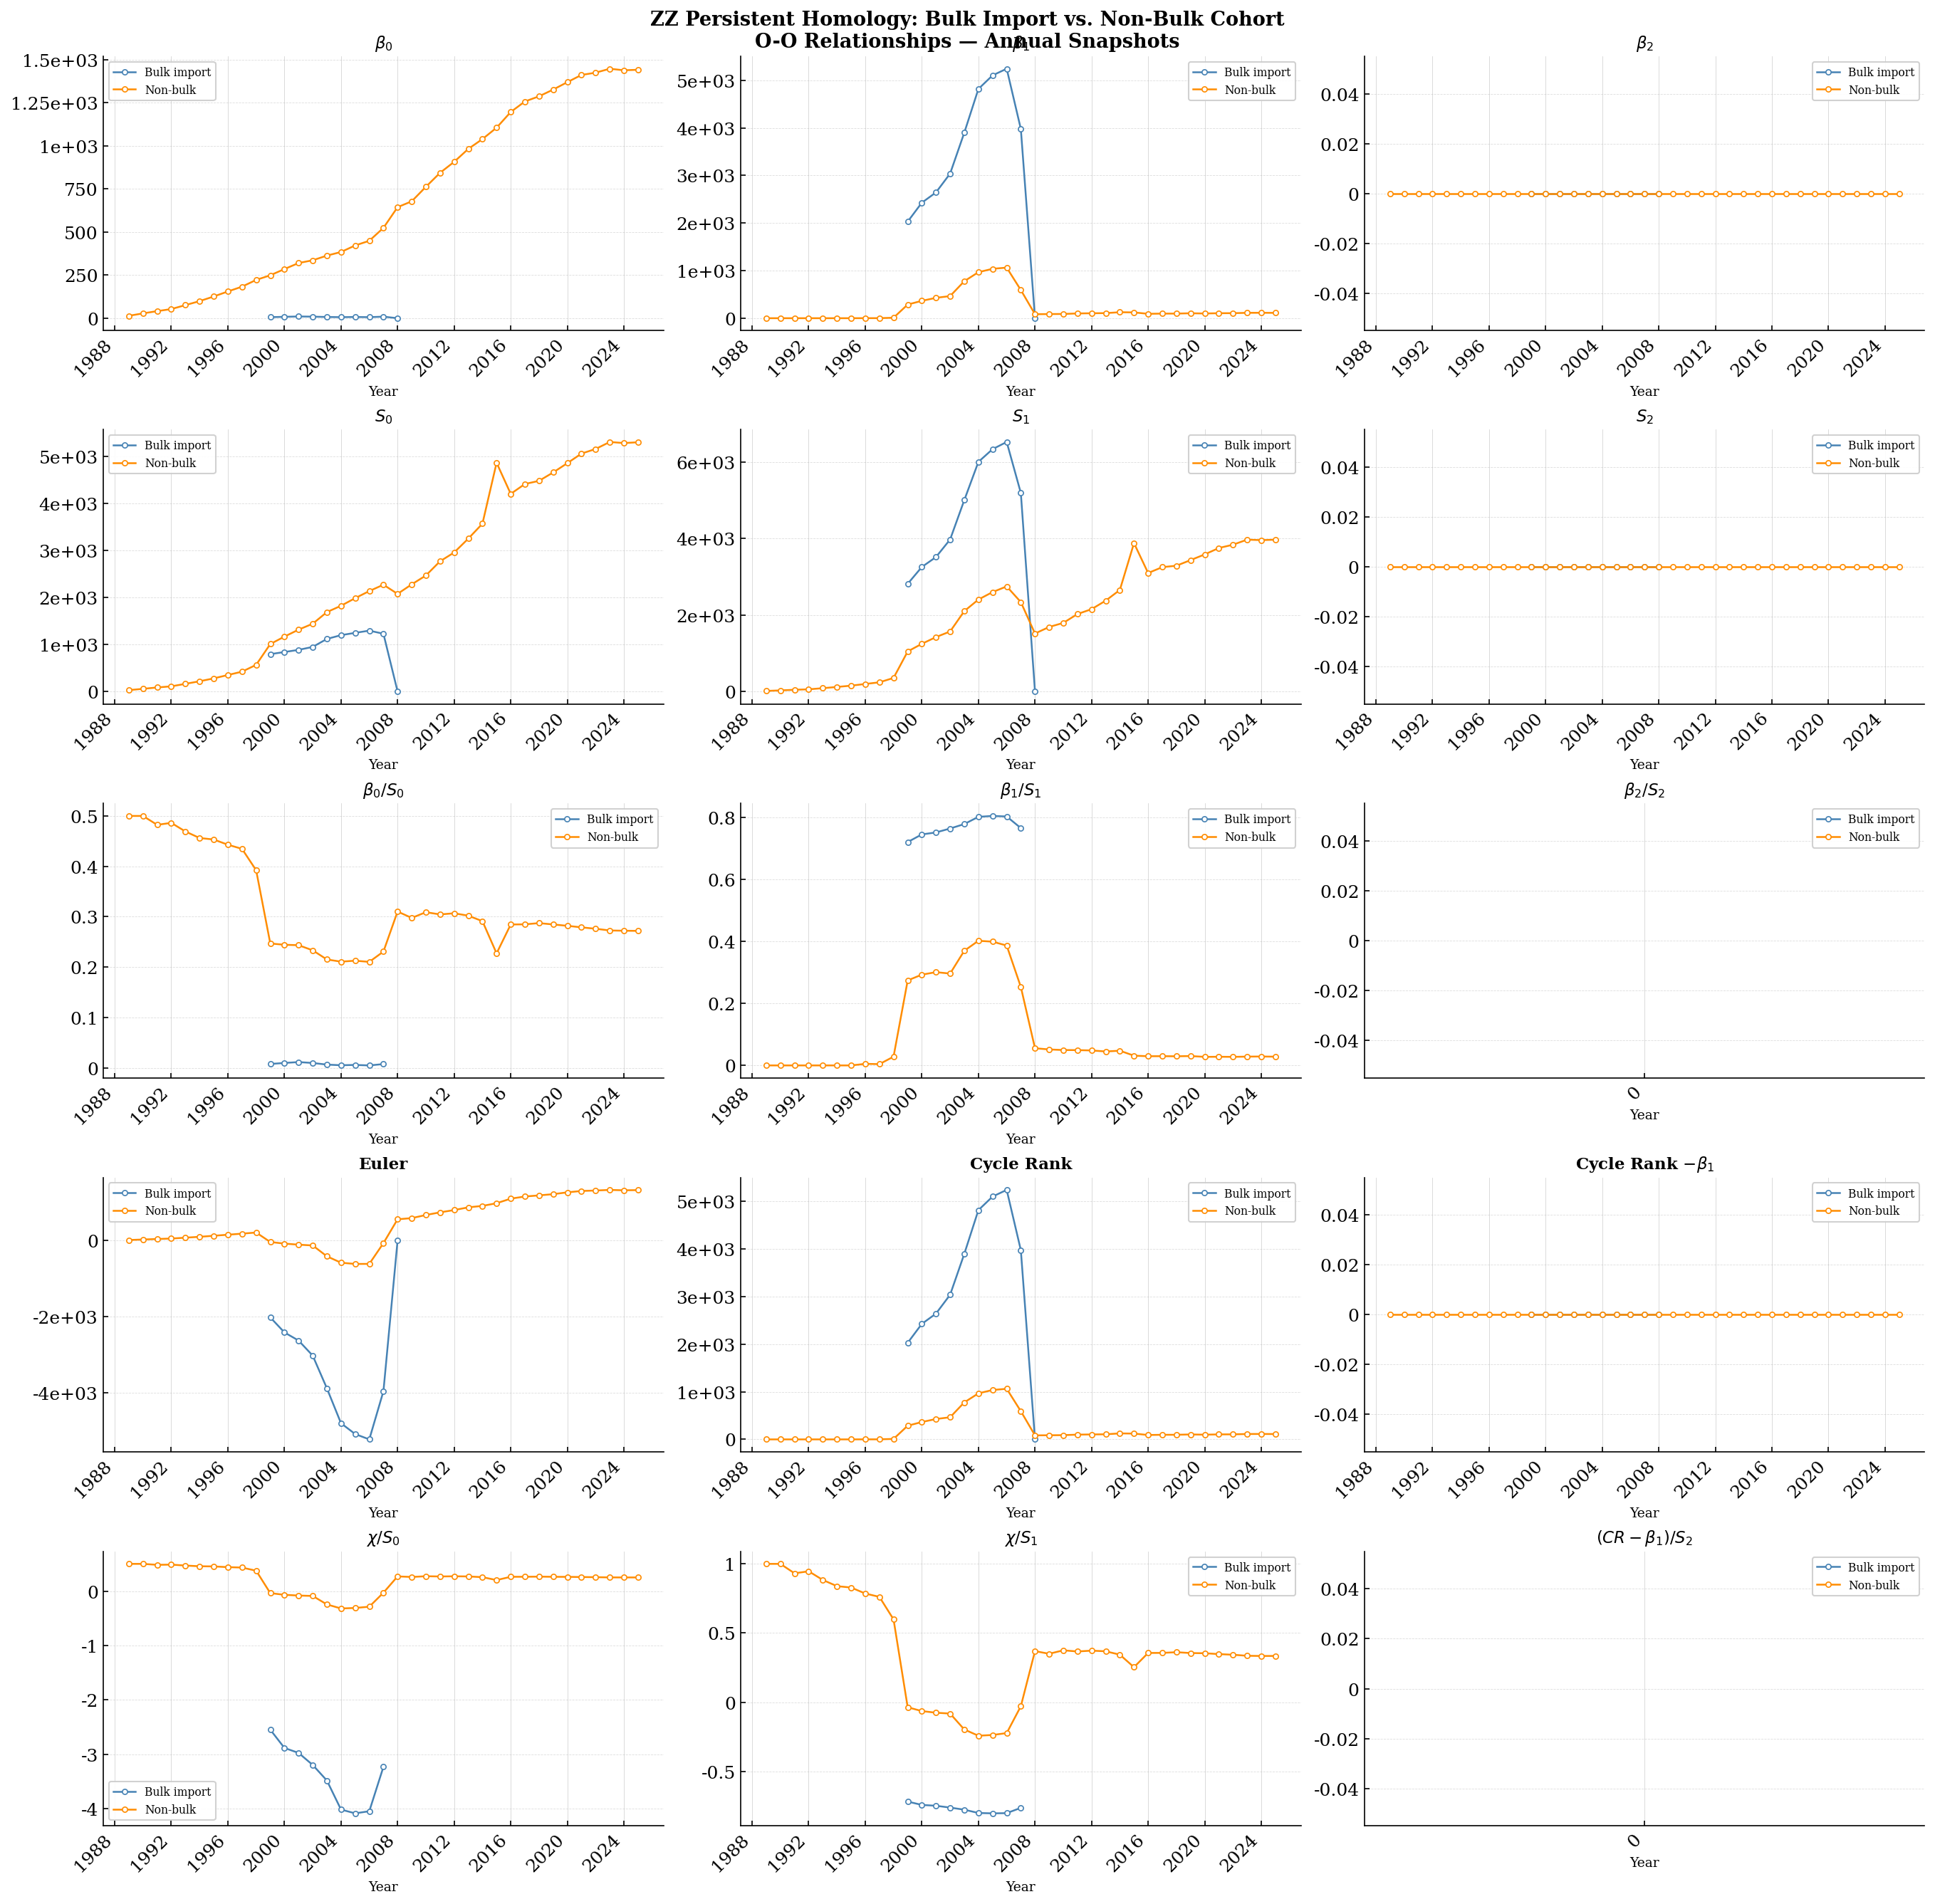

In [ ]:
# =============================================================================
# Run ZZ pipeline separately on bulk import and non-bulk cohorts
# =============================================================================
timing = True
if timing:
    print("Running ZZ pipeline on bulk import cohort...", flush=True)
Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk = ZZ_LittleSIS(
    rel_dicts=[bulk_import_o2o],
    timing=True,
    maxDim=2,
    random_seed=42
)

if timing:
    print("Running ZZ pipeline on non-bulk cohort...", flush=True)
Betti_non, SC_non, Euler_non, cycleR_non, dates_non = ZZ_LittleSIS(
    rel_dicts=[non_bulk_o2o],
    timing=True,
    maxDim=2,
    random_seed=42
)


# =============================================================================
# Aggregate to yearly snapshots (end-of-year)
# =============================================================================
def yearly_snapshot(arr, dates):
    """Return end-of-year values for a 1D array indexed by event."""
    years     = np.array([int(d[:4]) for d in dates])
    yr_range  = np.arange(years.min(), years.max() + 1)
    out       = np.full(len(yr_range), np.nan)
    for i, yr in enumerate(yr_range):
        mask = years == yr
        if np.any(mask):
            out[i] = arr[mask][-1]
    return yr_range, out


def prepare_yearly(Betti, SC, Euler, cycleR, dates):
    n = len(SC)
    sc0 = np.array([SC[t][0] if len(SC[t]) > 0 else 0
                    for t in range(n)], dtype=float)
    sc1 = np.array([SC[t][1] if len(SC[t]) > 1 else 0
                    for t in range(n)], dtype=float)
    sc2 = np.array([SC[t][2] if len(SC[t]) > 2 else 0
                    for t in range(n)], dtype=float)
    b0  = Betti[0].astype(float)
    b1  = Betti[1].astype(float)
    b2  = Betti[2].astype(float)
    cr  = np.array(cycleR, dtype=float)
    chi = np.array(Euler,  dtype=float)

    with np.errstate(invalid='ignore', divide='ignore'):
        r0      = np.where(sc0 > 0, b0  / sc0, np.nan)
        r1      = np.where(sc1 > 0, b1  / sc1, np.nan)
        r2      = np.where(sc2 > 0, b2  / sc2, np.nan)
        chi_s0  = np.where(sc0 > 0, chi / sc0, np.nan)
        chi_s1  = np.where(sc1 > 0, chi / sc1, np.nan)
        filled  = np.where(sc2 > 0, (cr - b1) / sc2, np.nan)

    raw = {
        r'$\beta_0$ (components)':                      b0,
        r'$\beta_1$ (tunnels)':                      b1,
        r'$\beta_2$ (voids)':                      b2,
        r'$S_0$':                          sc0,
        r'$S_1$':                          sc1,
        r'$S_2$':                          sc2,
        r'$\beta_0/S_0$':                  r0,
        r'$\beta_1/S_1$':                  r1,
        r'$\beta_2/S_2$':                  r2,
        'Euler':                           chi,
        'Cycle Rank':                      cr,
        r'Cycle Rank $-\beta_1$':          cr - b1,
        r'$\chi/S_0$':                     chi_s0,
        r'$\chi/S_1$':                     chi_s1,
        r'$(CR-\beta_1)/S_2$':             filled,
    }

    yearly = {}
    for key, arr in raw.items():
        yrs, vals = yearly_snapshot(arr, dates)
        yearly[key] = (yrs, vals)

    return yearly


yearly_bulk = prepare_yearly(
    Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk)
yearly_non  = prepare_yearly(
    Betti_non,  SC_non,  Euler_non,  cycleR_non,  dates_non)


# =============================================================================
# Plot: overlay bulk vs non-bulk for each quantity
# =============================================================================
def plot_cohort_comparison(yearly_bulk, yearly_non,
                           save_path='cohort_comparison.pdf'):
    keys   = list(yearly_bulk.keys())
    ncols  = 3
    nrows  = int(np.ceil(len(keys) / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 3.5 * nrows),
                             constrained_layout=True)
    axes = axes.flatten()

    for ax, key in zip(axes, keys):
        yrs_b, vals_b = yearly_bulk[key]
        yrs_n, vals_n = yearly_non[key]

        ax.plot(yrs_b, vals_b, color='steelblue', linewidth=1.2,
                marker='o', markersize=3.5, markerfacecolor='white',
                markeredgecolor='steelblue', markeredgewidth=0.8,
                label='Bulk import')
        ax.plot(yrs_n, vals_n, color='darkorange', linewidth=1.2,
                marker='o', markersize=3.5, markerfacecolor='white',
                markeredgecolor='darkorange', markeredgewidth=0.8,
                label='Non-bulk')

        ax.set_title(key, fontsize=11, fontweight='bold', pad=6)
        ax.set_xlabel('Year', fontsize=9, labelpad=4)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x:,.3g}'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        ax.legend(fontsize=7.5, framealpha=0.9, edgecolor='#cccccc')

    for ax in axes[len(keys):]:
        ax.set_visible(False)

    fig.suptitle('ZZ Persistent Homology: Bulk Import vs. Non-Bulk Cohort\n'
                 'O-O Relationships — Annual Snapshots',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_cohort_comparison(yearly_bulk, yearly_non)


# =============================================================================
# Normalized comparison: scale each cohort by its own S1 maximum
# so quantities of different magnitudes are directly comparable on same axes
# =============================================================================
def plot_normalized_comparison(yearly_bulk, yearly_non,
                                save_path='cohort_normalized.pdf'):
    """
    For a subset of key quantities, normalize each cohort by its own
    terminal S1 value so that size differences don't dominate the comparison.
    Focus on normalized and ratio quantities that are already size-invariant.
    """
    ratio_keys = [
        r'$\beta_0/S_0$',
        r'$\beta_1/S_1$',
        r'$\beta_2/S_2$',
        r'$\chi/S_0$',
        r'$\chi/S_1$',
        r'$(CR-\beta_1)/S_2$',
    ]

    ncols = 3
    nrows = int(np.ceil(len(ratio_keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 3.5 * nrows),
                             constrained_layout=True)
    axes = axes.flatten()

    for ax, key in zip(axes, ratio_keys):
        yrs_b, vals_b = yearly_bulk[key]
        yrs_n, vals_n = yearly_non[key]

        ax.plot(yrs_b, vals_b, color='steelblue', linewidth=1.2,
                marker='o', markersize=3.5, markerfacecolor='white',
                markeredgecolor='steelblue', markeredgewidth=0.8,
                label='Bulk import')
        ax.plot(yrs_n, vals_n, color='darkorange', linewidth=1.2,
                marker='o', markersize=3.5, markerfacecolor='white',
                markeredgecolor='darkorange', markeredgewidth=0.8,
                label='Non-bulk')

        ax.set_title(key, fontsize=11, fontweight='bold', pad=6)
        ax.set_xlabel('Year', fontsize=9, labelpad=4)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{x:,.3g}'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        ax.legend(fontsize=7.5, framealpha=0.9, edgecolor='#cccccc')

    for ax in axes[len(ratio_keys):]:
        ax.set_visible(False)

    fig.suptitle('Size-Invariant Quantities: Bulk Import vs. Non-Bulk Cohort\n'
                 'O-O Relationships — Annual Snapshots',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetim

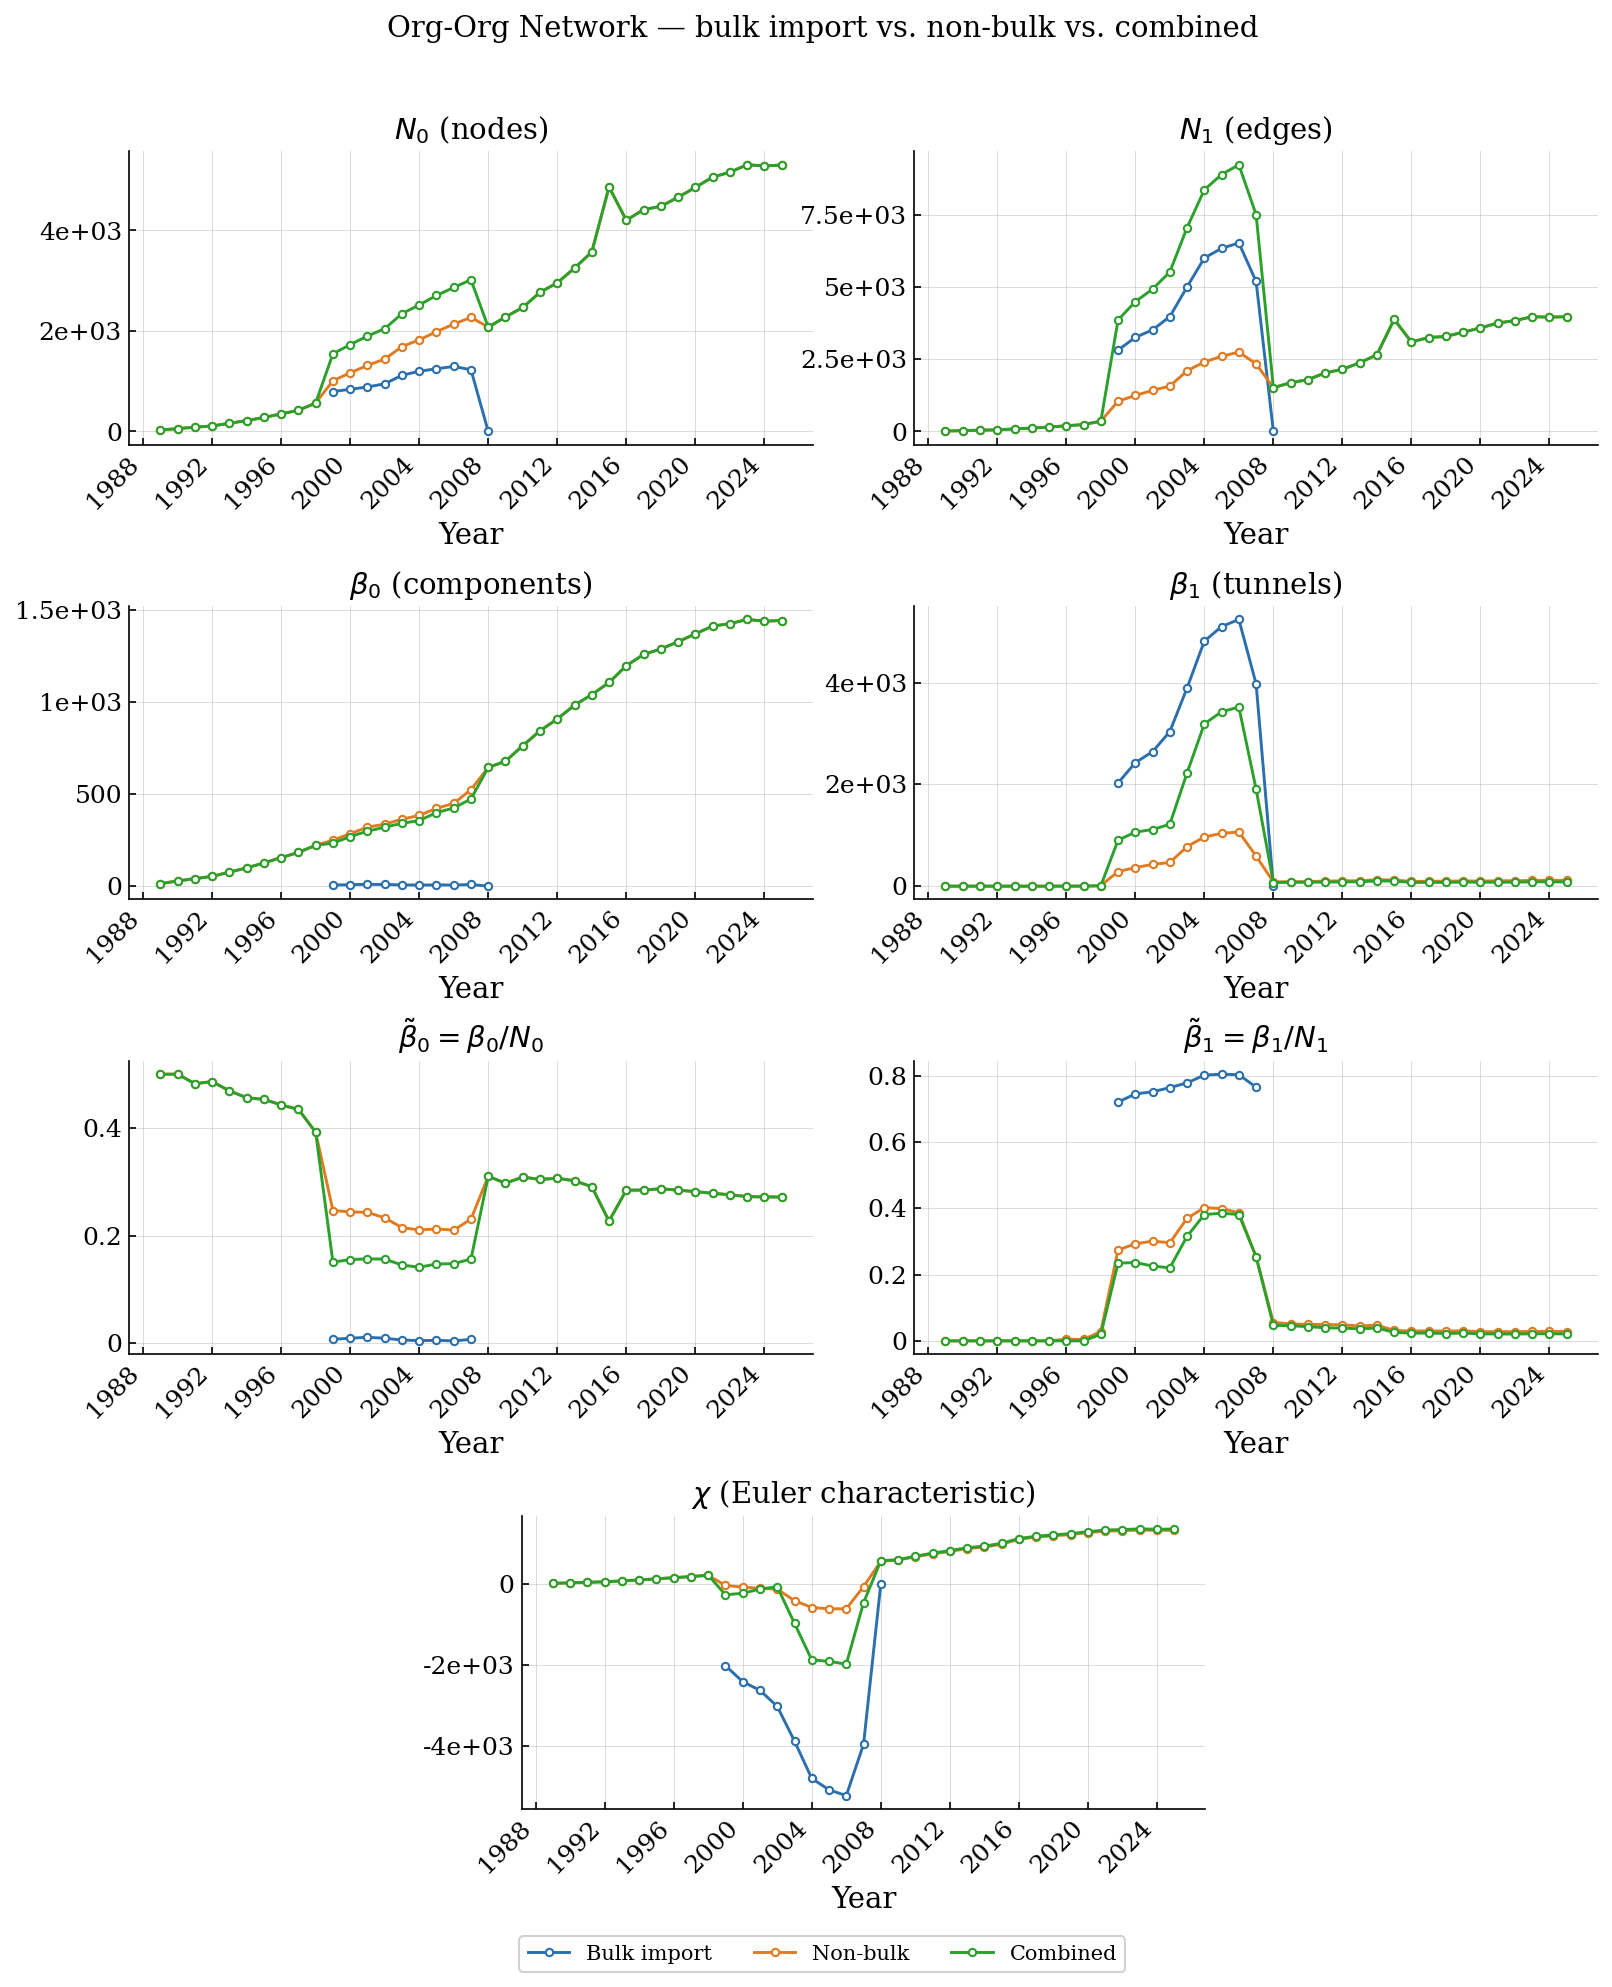

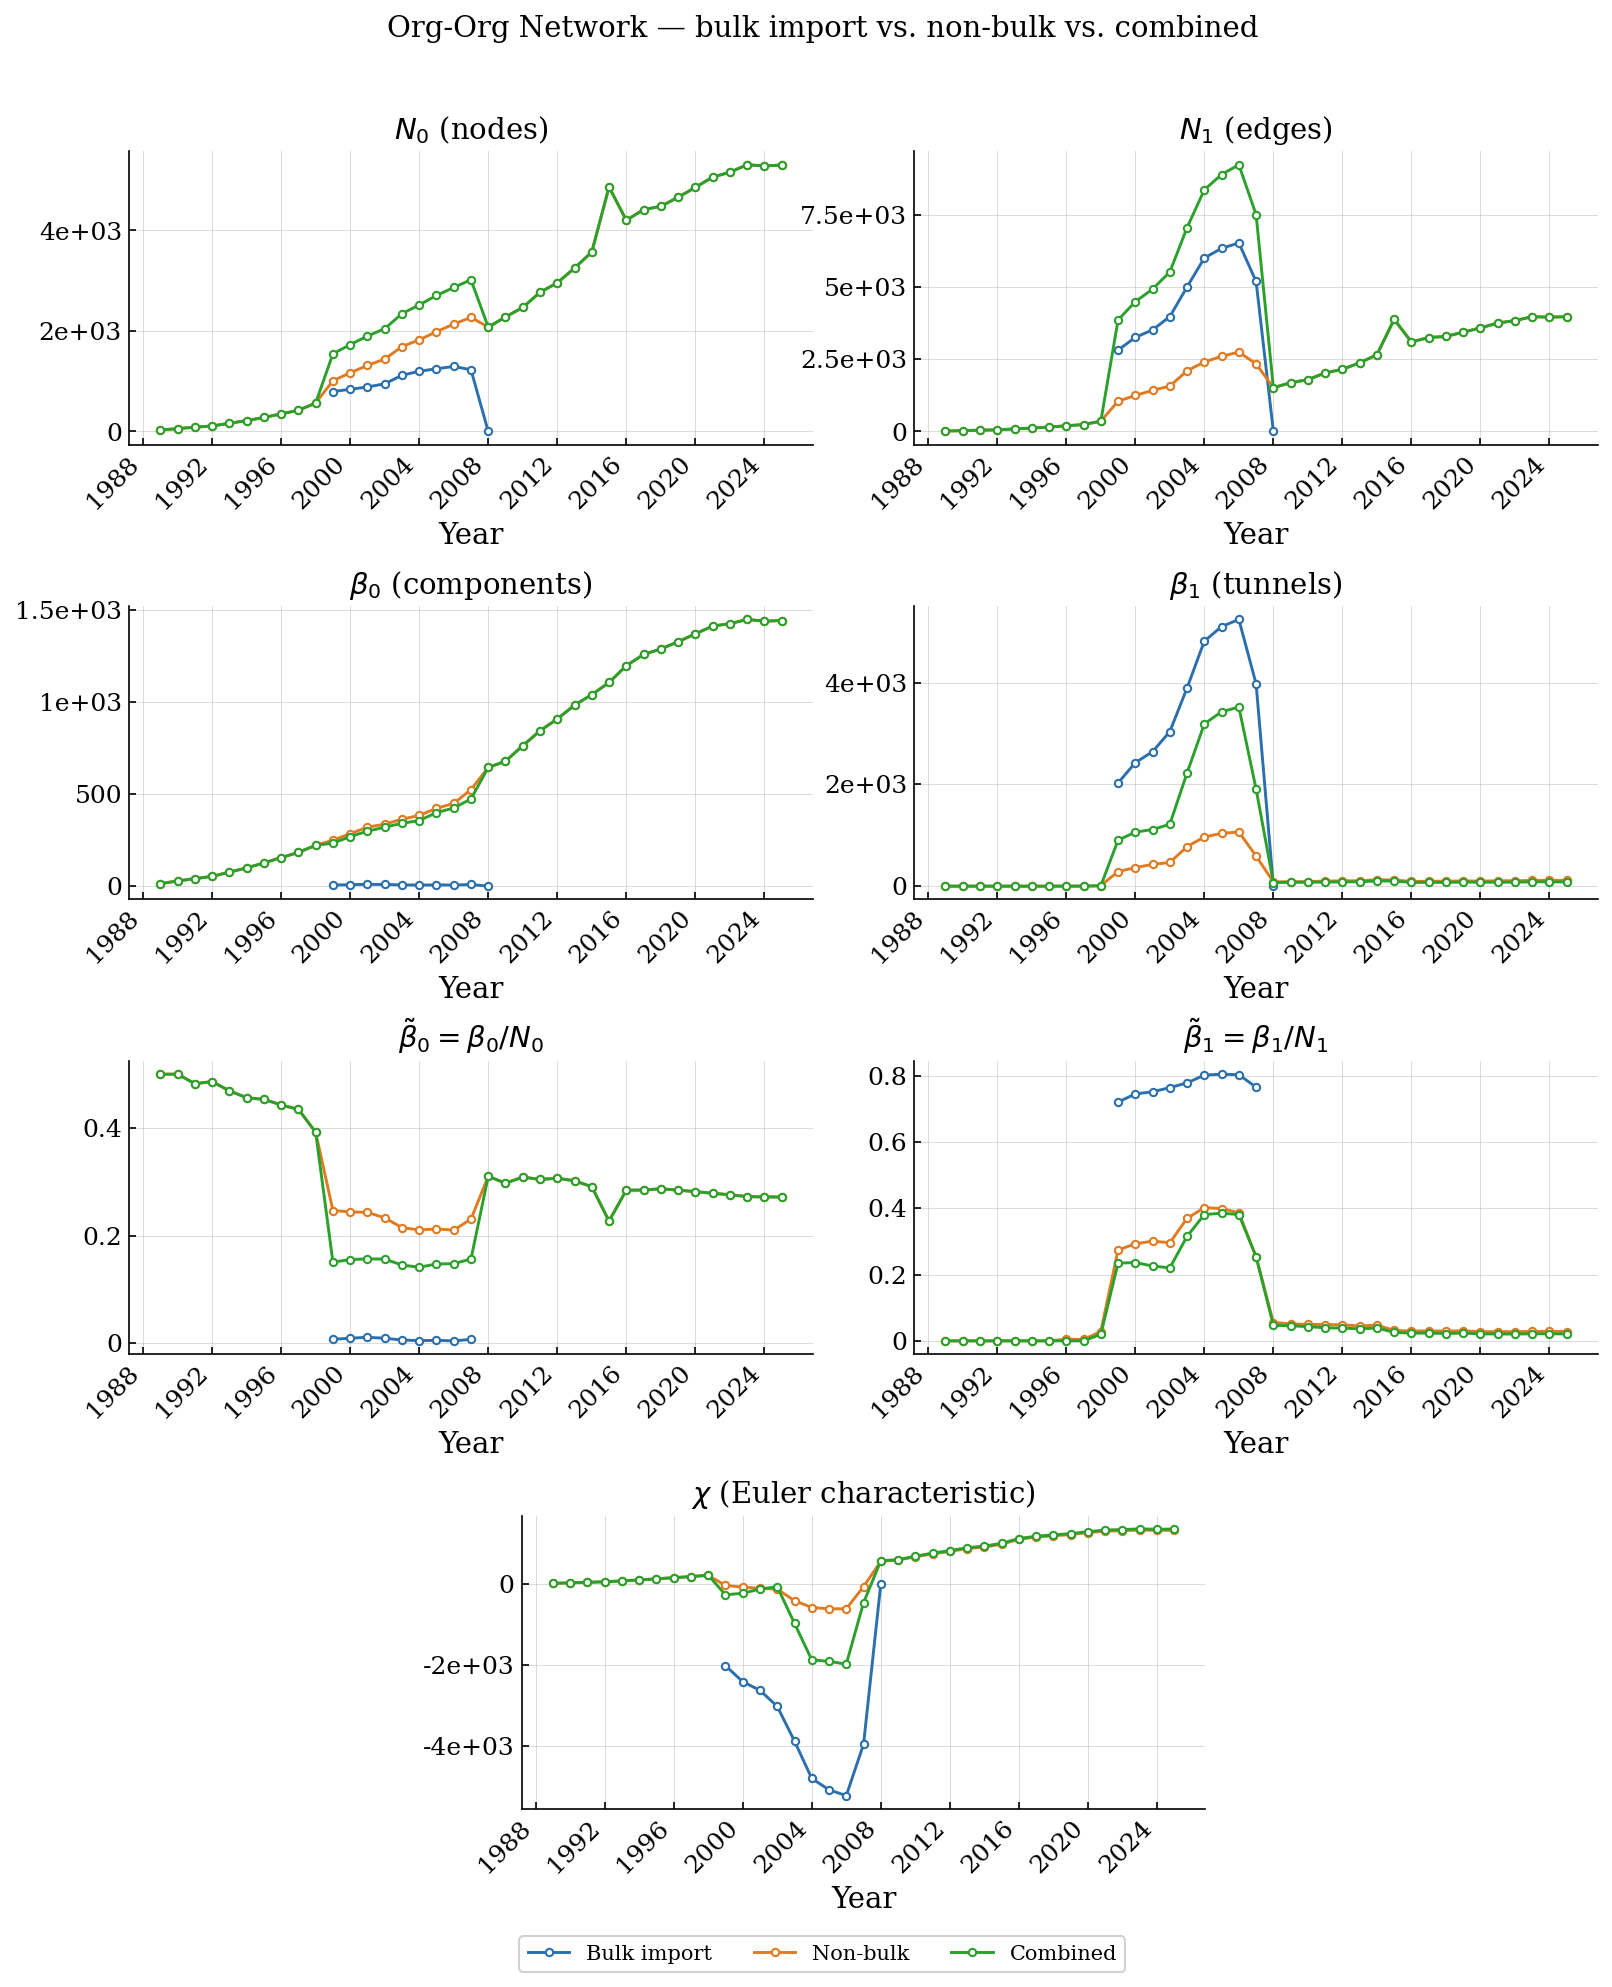

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

BULK_COLOR     = '#2c6fad'
NONBULK_COLOR  = '#e07b22'
COMBINED_COLOR = '#2ca02c'
BULK_LABEL     = 'Bulk import'
NONBULK_LABEL  = 'Non-bulk'
COMBINED_LABEL = 'Combined'

save_base = '/content/drive/My Drive/Colab Notebooks/LittleSIS/'

# ── helpers ───────────────────────────────────────────────────────────────────

def _sc(SC, dim, n):
    return np.array([
        SC[t][dim] if len(SC[t]) > dim else 0
        for t in range(n)
    ], dtype=float)

def _yearly(arr, dates):
    years    = np.array([int(d[:4]) for d in dates])
    yr_range = np.arange(years.min(), years.max() + 1)
    out      = np.full(len(yr_range), np.nan)
    for i, yr in enumerate(yr_range):
        mask = years == yr
        if np.any(mask):
            out[i] = arr[mask][-1]
    return yr_range, out

def _prepare(Betti, SC, Euler, cycleR, dates):
    n   = len(SC)
    b0  = Betti[0].astype(float)
    b1  = Betti[1].astype(float)
    s0  = _sc(SC, 0, n)
    s1  = _sc(SC, 1, n)
    chi = np.array(Euler, dtype=float)

    with np.errstate(invalid='ignore', divide='ignore'):
        tb0 = np.where(s0 > 0, b0 / s0, np.nan)
        tb1 = np.where(s1 > 0, b1 / s1, np.nan)

    raw = dict(s0=s0, s1=s1, b0=b0, b1=b1, tb0=tb0, tb1=tb1, chi=chi)
    return {k: _yearly(v, dates) for k, v in raw.items()}

def _line_kw(color):
    return dict(color=color, lw=1.4, marker='o', markersize=3.5,
                markerfacecolor='white', markeredgecolor=color,
                markeredgewidth=1.0)

def _style_ax(ax, B, N, C, label):
    yrs_b, vals_b = B
    yrs_n, vals_n = N
    yrs_c, vals_c = C
    ax.plot(yrs_b, vals_b, label=BULK_LABEL,     **_line_kw(BULK_COLOR))
    ax.plot(yrs_n, vals_n, label=NONBULK_LABEL,  **_line_kw(NONBULK_COLOR))
    ax.plot(yrs_c, vals_c, label=COMBINED_LABEL, **_line_kw(COMBINED_COLOR))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda v, _: f'{v:,.3g}'))
    ax.set_title(label, pad=6)


def plot_cohort_graph(Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk,
                      Betti_non,  SC_non,  Euler_non,  cycleR_non,  dates_non,
                      Betti_comb, SC_comb, Euler_comb, cycleR_comb, dates_comb,
                      title='', save_path=None):
    """
    4-row layout:
      Row 1 (2 cols): N0,      N1
      Row 2 (2 cols): β0,      β1
      Row 3 (2 cols): β̃0,     β̃1
      Row 4 (1 col, centred): Euler characteristic
    Single shared legend beneath the suptitle.
    """
    B = _prepare(Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk)
    N = _prepare(Betti_non,  SC_non,  Euler_non,  cycleR_non,  dates_non)
    C = _prepare(Betti_comb, SC_comb, Euler_comb, cycleR_comb, dates_comb)

    fig = plt.figure(figsize=(11, 13))
    fig.suptitle(title, fontsize=14, y=0.98)
    gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.35,
                            left=0.08, right=0.97, top=0.91, bottom=0.06)

    ax_s0  = fig.add_subplot(gs[0, :2])
    ax_s1  = fig.add_subplot(gs[0, 2:])
    ax_b0  = fig.add_subplot(gs[1, :2])
    ax_b1  = fig.add_subplot(gs[1, 2:])
    ax_tb0 = fig.add_subplot(gs[2, :2])
    ax_tb1 = fig.add_subplot(gs[2, 2:])
    ax_chi = fig.add_subplot(gs[3, 1:3])

    panels = [
        (ax_s0,  's0',  r'$N_0$ (nodes)'),
        (ax_s1,  's1',  r'$N_1$ (edges)'),
        (ax_b0,  'b0',  r'$\beta_0$ (components)'),
        (ax_b1,  'b1',  r'$\beta_1$ (tunnels)'),
        (ax_tb0, 'tb0', r'$\tilde{\beta}_0 = \beta_0 / N_0$'),
        (ax_tb1, 'tb1', r'$\tilde{\beta}_1 = \beta_1 / N_1$'),
        (ax_chi, 'chi', r'$\chi$ (Euler characteristic)'),
    ]

    for ax, key, label in panels:
        _style_ax(ax, B[key], N[key], C[key], label)

    # Single shared legend placed between suptitle and top row of panels
    handles, labels = ax_s0.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', ncol=3,
               bbox_to_anchor=(0.5, 0.0),
               fontsize=10, framealpha=0.9, edgecolor='#cccccc')

    if save_path:
        fig.savefig(save_path + '.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(save_path + '.png', dpi=300, bbox_inches='tight')
    plt.show()
    return fig


# ── call ──────────────────────────────────────────────────────────────────────

plot_cohort_graph(
    Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk,
    Betti_non,  SC_non,  Euler_non,  cycleR_non,  dates_non,
    Betti_o2o_start_end, SimplexCounts_o2o_start_end,
    Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end,
    title     = 'Org-Org Network — bulk import vs. non-bulk vs. combined',
    save_path = save_base + 'fig_cohort_graph',
)